<h2 style="color:#0B5394;">Data Mining Project - Group 42 </h2>

<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 1. Customers Dataset
    

    
</div>

<a class="anchor" id="1st-bullet">

## Importing, Exploring and Pre-processing   
</a>

<a class="anchor" id="2nd-bullet">

### 1.1. Import the needed libraries    
</a>

In [146]:
# Importing the needed libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil
from sklearn.preprocessing import MinMaxScaler

<a class="anchor" id="3rd-bullet">

### 1.2. Import the dataset
    
</a>

In [147]:
customers = pd.read_csv('DM_AIAI_CustomerDB.csv')

<a class="anchor" id="3rd-bullet">

### 1.3. Exploratory Data Analysis 
    
</a>

In this section, we will explore the structure, quality, and distribution of the data in the ***customers dataset***.

We will use descriptive statistics and visualizations to better understand patterns and potential relationships between variables.

In [148]:
customers.head() 

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [149]:
customers.shape

(16921, 21)

The costumers dataset consists of 16921 observations and 21 variables.

In [150]:
customers.columns

Index(['Unnamed: 0', 'Loyalty#', 'First Name', 'Last Name', 'Customer Name',
       'Country', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType'],
      dtype='object')

In [151]:
# Checking the type and non-null values (not missing values) of each variable
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16921 non-null  int64  
 1   Loyalty#                 16921 non-null  int64  
 2   First Name               16921 non-null  object 
 3   Last Name                16921 non-null  object 
 4   Customer Name            16921 non-null  object 
 5   Country                  16921 non-null  object 
 6   Province or State        16921 non-null  object 
 7   City                     16921 non-null  object 
 8   Latitude                 16921 non-null  float64
 9   Longitude                16921 non-null  float64
 10  Postal code              16921 non-null  object 
 11  Gender                   16921 non-null  object 
 12  Education                16921 non-null  object 
 13  Location Code            16921 non-null  object 
 14  Income                

- Here, besides checking the type of each variable, we can already check how many missing values each variable has.
- The only variables who seem to have ***missing values*** are "Income" (20 NaN's), "Customer Lifetime Value" (20 NaN's) and "CancellationDate" (14611 NaN's) - We will treat this missing values later

In [152]:
# Checking only the type of each variable
customers.dtypes

Unnamed: 0                   int64
Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object


- We can already conclude that the variables "EnrollmentDateOpening" and "CancellationDate" should be ***datetime***, so we are going to need to convert them later.

In [153]:
customers.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,16921.0,NaN,NaN,NaN,8440.023639,4884.775439,0.0,4210.0,8440.0,12670.0,16900.0
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,259251.503597,100011.0,326823.0,550896.0,772438.0,999999.0
First Name,16921,4941,Stacey,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Ypina,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Emma Martin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578


- After this we will check these statistics for specific variables, so it's easier to see, but, from this we can conclude that the variable ***"Unnamed:0" will be dropped*** - This variable has no analytical meaning, it simply represents the row number (index) and doesn’t provide any useful information about customers or their behavior.

In [154]:
# Filtering numeric variables so we can easier see their statistics
# We are only doing this for the variables that are more relevant 
# (it doesn't make sense to do this for the variables "Unnamed" and "Loyalty", for example, and cordinates aren't meaningful for this analysis )

customers[['Income', 'Customer Lifetime Value']].describe()

,Income,Customer Lifetime Value
count,16901.000000,16901.000000
mean,37758.038400,7990.460188
std,30368.992499,6863.173093
min,0.000000,1898.010000
25%,0.000000,3979.720000
50%,34161.000000,5780.180000
75%,62396.000000,8945.690000
max,99981.000000,83325.380000


- These statistics are useful to check, for example, if the variables have outliers
- "Income": The presence of both 0 and very high values indicates ***potential outliers*** or an asymmetric (right-skewed) distribution.
- Also, the mean income is around 37758, but the standard deviation is very high (around 30368), which shows large variability among customers.
- "Customer Lifetime Value": The minimum value (around 1898) and maximum (around 83325) are also kind of far apart, which shows potential outliers and right-skewness.

In [155]:
# Basic statistics for categorical variabels

customers.describe(include="object")

,First Name,Last Name,Customer Name,Country,Province or State,City,Postal code,Gender,Education,Location Code,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,EnrollmentType
count,16921,16921,16921,16921,16921,16921,16921,16921,16921,16921,16921,16921,16921,2310,16921
unique,4941,15404,16921,1,11,29,75,2,5,3,3,3,2449,1260,2
top,Stacey,Ypina,Emma Martin,Canada,Ontario,Toronto,V6E 3D9,female,Bachelor,Suburban,Married,Star,4/3/2015,7/7/2020,Standard
freq,13,4,1,16921,5468,3390,917,8497,10586,5716,9842,7761,34,8,15773


- We can already conclude that the variable ***"Country" will be dropped*** (since the customers seem to be all from Canada: unique=1)
- The variables ***"First Name", "Last Name" and "Customer Name" might also be dropped*** (they aren't really relevant since we have the variable "Loyalty#" to identify each customer)

<a class="anchor" id="3rd-bullet">

### 1.3.1. Checking for Missing Values
    
</a>

Here we are only going to check if there are any missing values in the Customers Dataset, we are not going to treat them yet.

In [156]:
customers.isna().sum()

Unnamed: 0                     0
Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

- As we have checked before (in .info), we only have missing values in the variables "Income" (20 NaN's), "Customer Lifetime Value" (20 NaN's) and "CancellationDate" (14611 NaN's).

- "CancellationDate": We know that the total number of rows is 16921. Since the number of missing values in this variable is 14611, we can conclude that ***2310 people left the program.***

In [157]:
# Check if the rows with missing values in "Income" are the same rows with missing values in "Customer Lifetime Value"
missing_values_income = customers['Income'].isna()
missing_values_clv = customers['Customer Lifetime Value'].isna()

# Compare the two boolean masks
(missing_values_income == missing_values_clv).all()


np.True_

Since the output is "True", we can assume that "Income" and "Customer Lifetime Value" have the same missing values.

This might mean that ?????

In [158]:
# Checking the rows where both Income and Customer Lifetime Value are NaN
customers[customers['Income'].isna() & customers['Customer Lifetime Value'].isna()]


,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,0,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,1,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,2,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,3,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,4,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard
16906,5,999992,Ella,Roy,Ella Roy,Canada,Ontario,Toronto,43.706878,-79.437412,P6D 6N2,male,College,Suburban,NaN,Single,Star,3/27/2021,3/27/2021,NaN,Standard
16907,6,999993,Elijah,Cook,Elijah Cook,Canada,British Columbia,Dawson Creek,55.701475,-120.181716,W6H 0Z7,female,College,Suburban,NaN,Married,Star,1/27/2015,1/27/2015,NaN,Standard
16908,7,999994,Ethan,Chan,Ethan Chan,Canada,Ontario,Ottawa,45.365906,-75.723181,B2F 3E1,female,College,Rural,NaN,Married,Star,5/5/2016,5/5/2016,NaN,Standard
16909,8,999995,Liam,Wong,Liam Wong,Canada,Ontario,Ottawa,45.471557,-75.704868,B3A 2R0,female,College,Suburban,NaN,Married,Star,3/2/2020,3/2/2020,NaN,Standard
16910,9,999996,Isabella,Ross,Isabella Ross,Canada,Ontario,Toronto,43.690489,-79.436758,B4W 4M6,female,Bachelor,Suburban,NaN,Single,Star,9/14/2018,9/14/2018,NaN,Standard


<a class="anchor" id="3rd-bullet">

### 1.3.2. Checking for Duplicated Values
    
</a>

In [159]:
customers.duplicated().sum()

np.int64(0)

- We can conclude that in the Customers Dataset there aren't any rows that are duplicated.

- But, even though we don't have rows that are completly equal to other rows, we might still have some duplication errors.

- Since Loyalty# should be a unique customer identifier it is important to check if the ***same Loyalty# appears with different customer names.***


In [160]:
# Checking for duplicated Loyalty# with different names
duplicates = customers.groupby('Loyalty#')['Customer Name'].nunique()
duplicates[duplicates > 1]


Loyalty#
101902    2
106001    2
106509    2
112142    2
114414    2
         ..
981508    2
988392    2
989528    2
990512    2
992168    2
Name: Customer Name, Length: 163, dtype: int64

- Apparently there are 163 duplicated "Loyalty#", this is, ***163 customers with the same ID but different names***.

- We need to verify those duplicates in the dataset. If we check that for each one of the duplicates' rows, the values in every variable are the same (and only the ID differs) then we can assume this was just an inconsistency and we can keep the first duplicated row and delete the second one (since they refer to the same customer). 
- But, if we check that only the ID is the same, and all the other variables have different values, then we can conclude that they are different customers. In that case, we probably shouldn't delete one of the customers, cause that way we would be losing important information.


??? But for now I am going to keep the first row and delete the others, and after talking to the teacher we decide what to do

In [161]:
# Checking if the duplicated #Loyalty refer different customers or not
# If for example rows with same ID have live in different countries, or have different income, etc,
# then we can assume that these are different customers

duplicates_ids = customers[customers.duplicated(subset='Loyalty#', keep=False)]
duplicates_ids.sort_values(['Loyalty#', 'Customer Name']).head(20)


,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
1646,1646,101902,Hans,Schlottmann,Hans Schlottmann,Canada,Ontario,London,42.984924,-81.245277,M5B 3E4,female,College,Rural,0.0,Married,Aurora,1/7/2020,NaN,6265.34,Standard
2668,2668,101902,Yi,Nesti,Yi Nesti,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,female,Bachelor,Urban,79090.0,Married,Aurora,3/19/2020,NaN,8609.16,Standard
700,700,106001,Ivette,Peifer,Ivette Peifer,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,female,High School or Below,Suburban,10037.0,Single,Star,1/11/2016,NaN,4914.04,Standard
15988,15988,106001,Maudie,Hyland,Maudie Hyland,Canada,New Brunswick,Fredericton,45.963589,-66.643112,E3B 2H2,female,Master,Suburban,14973.0,Divorced,Star,7/16/2015,NaN,12168.74,Standard
9413,9413,106509,Ardelia,Whitehorse,Ardelia Whitehorse,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Rural,30915.0,Married,Nova,4/25/2020,10/7/2021,16727.77,Standard
13053,13053,106509,Stacy,Schwebke,Stacy Schwebke,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,female,College,Suburban,0.0,Single,Star,6/12/2021,NaN,4661.98,Standard
3678,3678,112142,Arnold,Cantoran,Arnold Cantoran,Canada,Ontario,Thunder Bay,48.380894,-89.247681,K8T 5M5,male,Bachelor,Urban,83589.0,Single,Aurora,7/26/2018,NaN,16272.74,Standard
9604,9604,112142,Marty,Kijak,Marty Kijak,Canada,Nova Scotia,Halifax,44.648766,-63.575237,B3J 9S2,female,College,Suburban,0.0,Married,Nova,2/21/2020,4/22/2021,21578.86,Standard
5253,5253,114414,Kala,Bachor,Kala Bachor,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,male,College,Rural,0.0,Married,Nova,11/6/2015,NaN,3591.07,Standard
11411,11411,114414,Temple,Resper,Temple Resper,Canada,Ontario,Ottawa,45.421532,-75.697189,K1F 2R2,female,High School or Below,Urban,14151.0,Single,Star,12/18/2015,NaN,2617.70,Standard


This shows that the name, gender, income, etc is different for the customers with the same Loyalty#, which means that the error happening error isn't just a copy of the same customer, but it is an error in only the ID (the system gave the same ID to different customers).

In [162]:
# Removing duplicated Loyalty# entries (keeping only the first occurrence) 
print("Initial dataset shape:", customers.shape)

customers = customers.drop_duplicates(subset='Loyalty#', keep='first')

print("Dataset shape after removing duplicated Loyalty#:", customers.shape)


Initial dataset shape: (16921, 21)
Dataset shape after removing duplicated Loyalty#: (16757, 21)


<a class="anchor" id="3rd-bullet">

### 1.4. Initial Data Preparation
    
</a>

Here, we are only going to ***deal with some of the initial inconsistencies***, like deleting variables that aren't relevant for our analysis (and for the models) and also converting variables to their correct data type.

<a class="anchor" id="3rd-bullet">

### 1.4.1. Deleting variables that aren't relevant
    
</a>

- We decided to drop the variable "Unnamed:0", as we wrote before, because it has no analytical meaning. It only represents the row number and doesn’t provide any useful information about customers or their behavior. Keeping it would only add noise and take up unnecessary space in the dataset.
- We also decided to drop the variables 'First Name', 'Last Name' and 'Customer Name', since we already have a variable that identifies each customer ('#Loyalty').
- Finally, we decided to drop the variable 'Country', because we checked that all the rows in this column are equal, all the customers are from Canada.

In [163]:
customers = customers.drop(['Unnamed: 0', 'First Name', 'Last Name', 'Customer Name', 'Country'], axis=1)


In [164]:
# Shows the dataset after deleting the unrelevant variables
display(customers)

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16917,100013,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
16918,100014,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
16919,100015,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


<a class="anchor" id="3rd-bullet">

### 1.4.2. Converting variables to datetime
    
</a>

In the beginning of the exploratory data analysis we noticed that the variables "EnrollmentDateOpening" and "CancellationDate" were of the type object, and they should be datetime. So we are going to convert them now.

In [165]:
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'])
customers['CancellationDate'] = pd.to_datetime(customers['CancellationDate'], errors='coerce')

In [166]:
# Checking if the type is now correct
customers[['EnrollmentDateOpening', 'CancellationDate']].info()


<class 'pandas.core.frame.DataFrame'>
Index: 16757 entries, 0 to 16920
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   EnrollmentDateOpening  16757 non-null  datetime64[ns]
 1   CancellationDate       2286 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 392.7 KB


<a class="anchor" id="3rd-bullet">

### 1.5. Visual Exploration
    
</a>

<a class="anchor" id="3rd-bullet">

### 1.5.1. Visualization of Numeric Variables
    
</a>

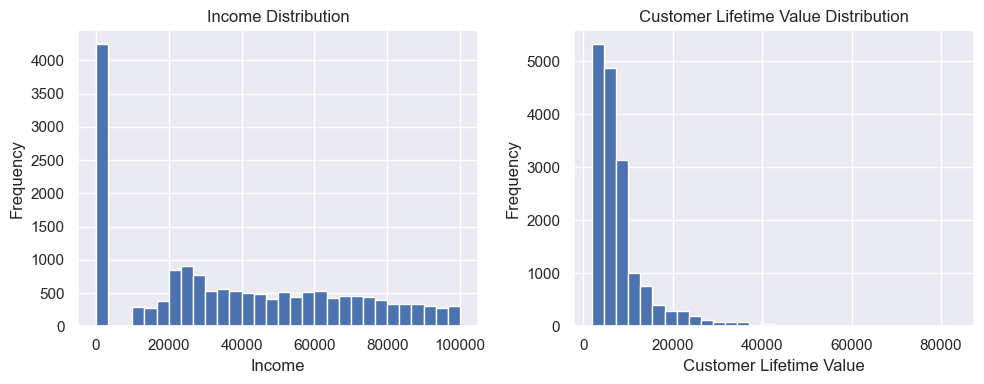

In [167]:
sns.set()

subplot_figsize = (10, 4)

fig, axes = plt.subplots(1, 2, figsize=subplot_figsize)

axes[0].hist(customers['Income'], bins=30)
axes[0].set_title('Income Distribution')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')

axes[1].hist(customers['Customer Lifetime Value'], bins=30)
axes[1].set_title('Customer Lifetime Value Distribution')
axes[1].set_xlabel('Customer Lifetime Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


The histograms show that most customers have low income and a low customer lifetime value, while only a few have very high values. This means the data is not evenly distributed — a small number of customers generate much more value than the rest. This kind of pattern is common in real customer data and shows why it’s important to identify and focus on the most valuable clients.

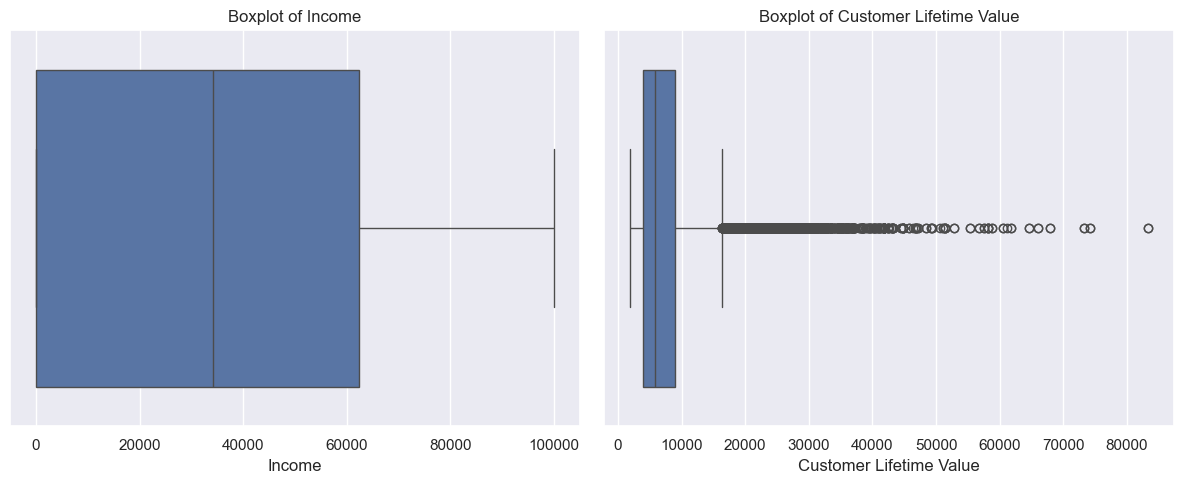

In [168]:
# Comparative boxplots (Income vs Customer Lifetime Value)
sns.set() 

fig, axes = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)

# Boxplot 1 - Income
sns.boxplot(x=customers["Income"], ax=axes[0])
axes[0].set_title("Boxplot of Income")

# Boxplot 2 - Customer Lifetime Value
sns.boxplot(x=customers["Customer Lifetime Value"], ax=axes[1])
axes[1].set_title("Boxplot of Customer Lifetime Value")

plt.show()


The boxplots show that both Income and Customer Lifetime Value are highly variable and contain several outliers. Most customers have values concentrated in the lower part of the distribution, while a few customers show much higher values. The boxplot of Customer Lifetime Value has a long right tail with many extreme points, confirming the presence of high-value customers identified in the histograms. This indicates that the data is not evenly distributed and that a small group of customers generates disproportionately higher value compared to the majority.

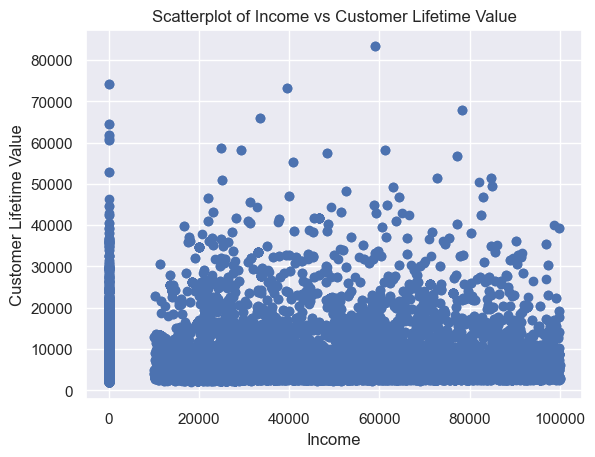

In [169]:
# Scatterplot entre Income e Customer Lifetime Value
plt.scatter(customers["Income"], customers["Customer Lifetime Value"])
plt.xlabel("Income")
plt.ylabel("Customer Lifetime Value")
plt.title("Scatterplot of Income vs Customer Lifetime Value")
plt.show()


The scatterplot shows the relationship between Income and Customer Lifetime Value. Each point represents a customer. The plot reveals no strong linear relationship between the two variables — customers with higher income do not necessarily have a higher lifetime value. Most points are concentrated in the lower ranges of both variables, confirming that the majority of customers have modest income and generate relatively low value for the company. This suggests that other factors beyond income may explain customer value differences.

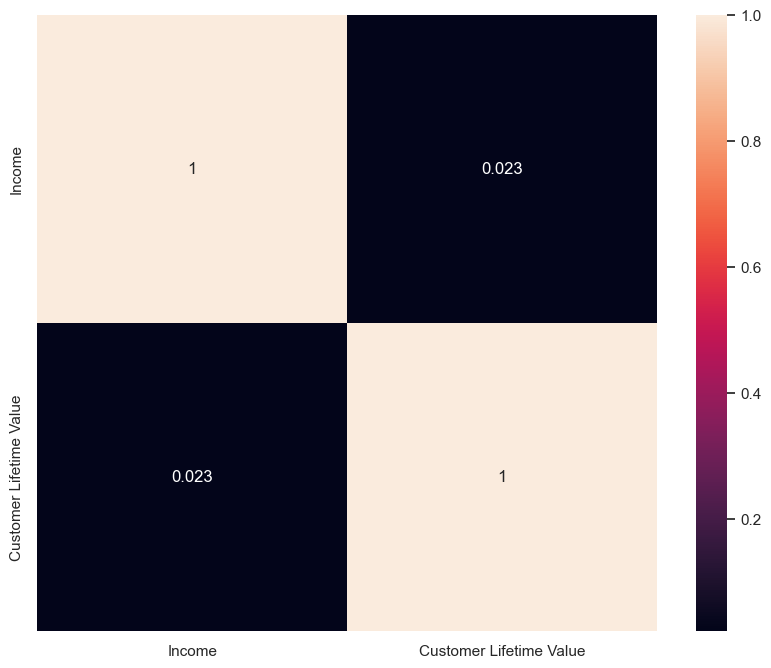

In [170]:
corr = customers[['Income', 'Customer Lifetime Value']].corr(method='pearson')
fig = plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=True, )
plt.show()

The correlation heatmap shows a very weak positive relationship (0.024) between Income and Customer Lifetime Value. This means that customers with higher income do not necessarily generate a higher lifetime value for the company. The almost zero correlation confirms what was seen in the scatterplot — the two variables are largely independent, suggesting that other factors, such as customer behavior or engagement with the program, play a more important role in determining the overall value of each customer.

<a class="anchor" id="3rd-bullet">

### 1.5.2. Visualization of Categorical Variables
    
</a>

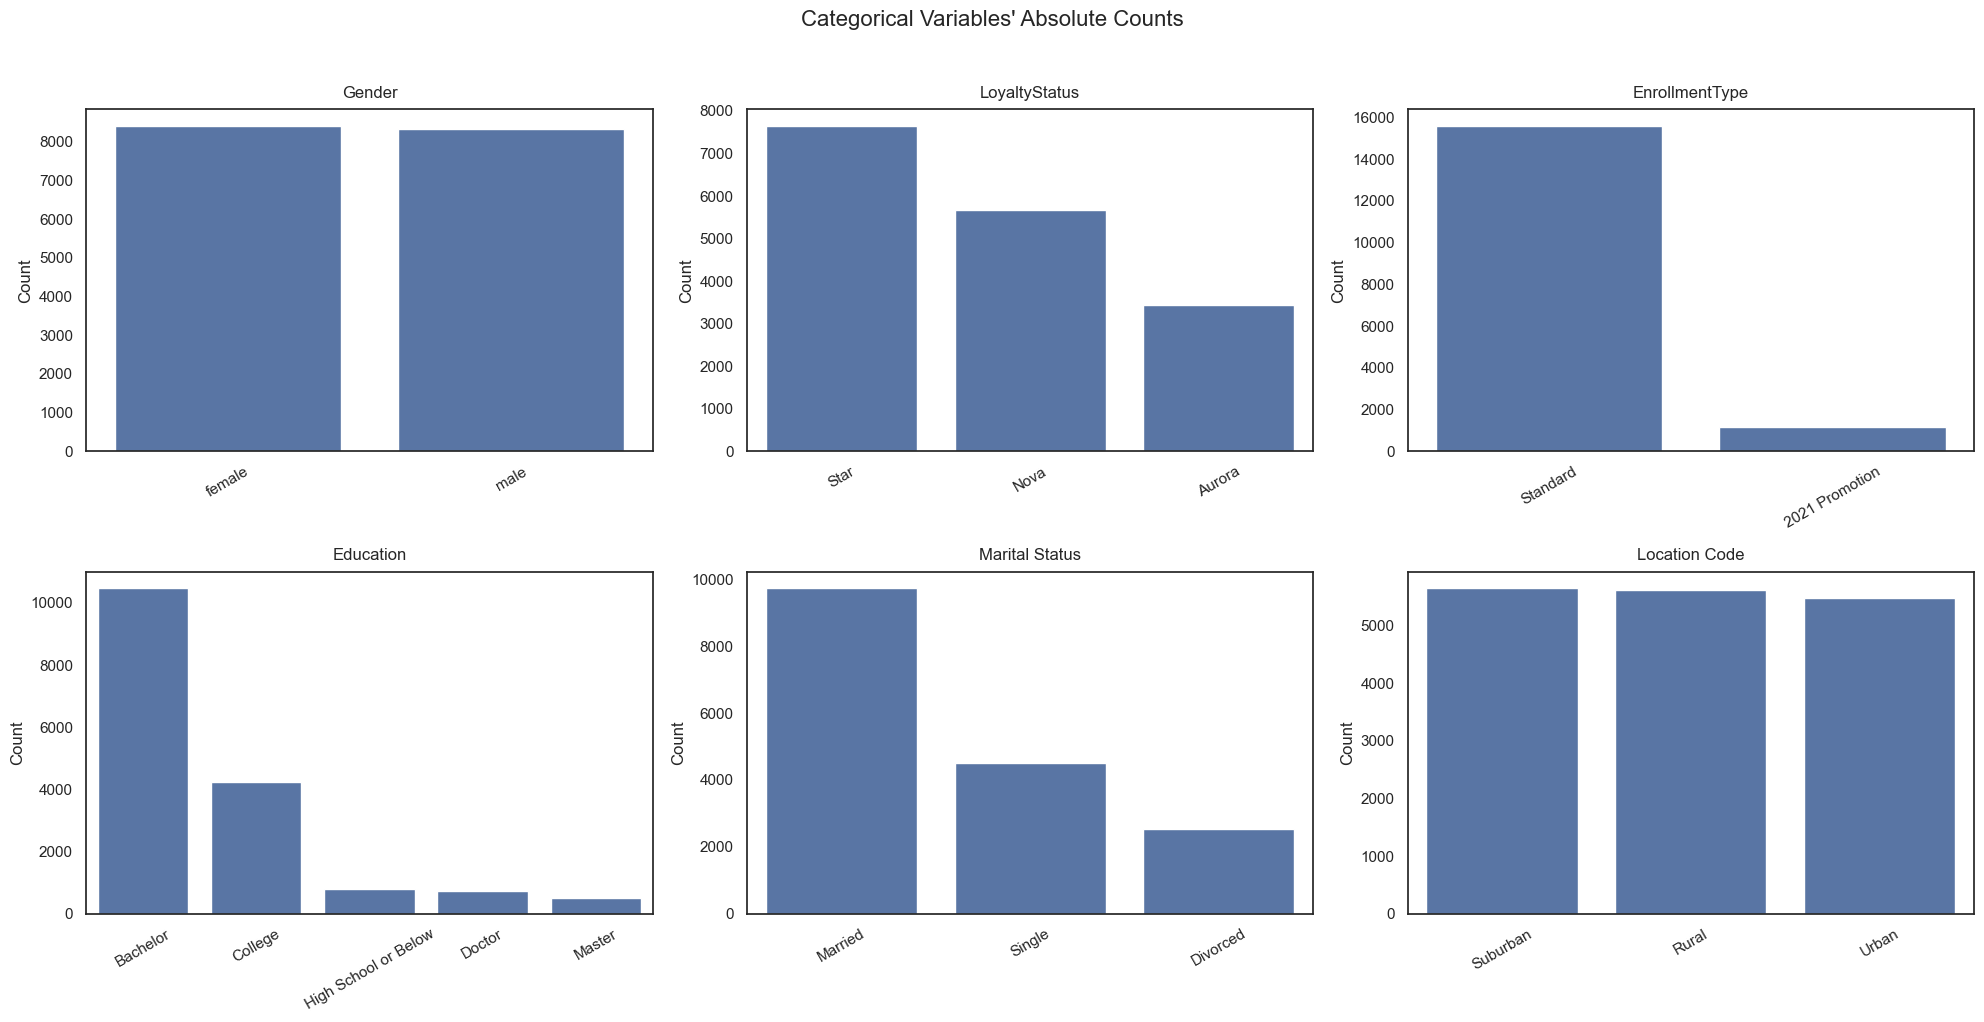

In [171]:
sns.set(style="white")

categorical_features = [
    'Gender',
    'LoyaltyStatus',
    'EnrollmentType',
    'Education',
    'Marital Status',
    'Location Code'
]

fig, axes = plt.subplots(
    2,
    ceil(len(categorical_features) / 2),
    figsize=(20, 10)
)


for ax, feat in zip(axes.flatten(), categorical_features):
    sns.countplot(
        x=customers[feat],
        ax=ax,
        order=customers[feat].value_counts().index,
    )
    ax.set_title(feat, fontsize=12, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)


plt.suptitle("Categorical Variables' Absolute Counts", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()


The bar charts show the distribution of the categorical variables in the dataset. The Gender variable is balanced, with a similar number of male and female customers. Most customers have a loyalty status of “Star” or “Nova”, while fewer belong to the “Aurora” group. In terms of Enrollment Type, the vast majority are part of the “Standard” program, with only a small share enrolled through the “2021 Promotion”.

Regarding Education, most customers hold a bachelor’s degree, followed by college-level education, and very few have a masters degree, only high school or lower or a doctors degree. The Marital Status variable shows that married customers represent the largest group, followed by singles and divorced individuals. Finally, the Location Code distribution is fairly balanced across suburban, rural, and urban areas, suggesting that the customer base is geographically diverse.

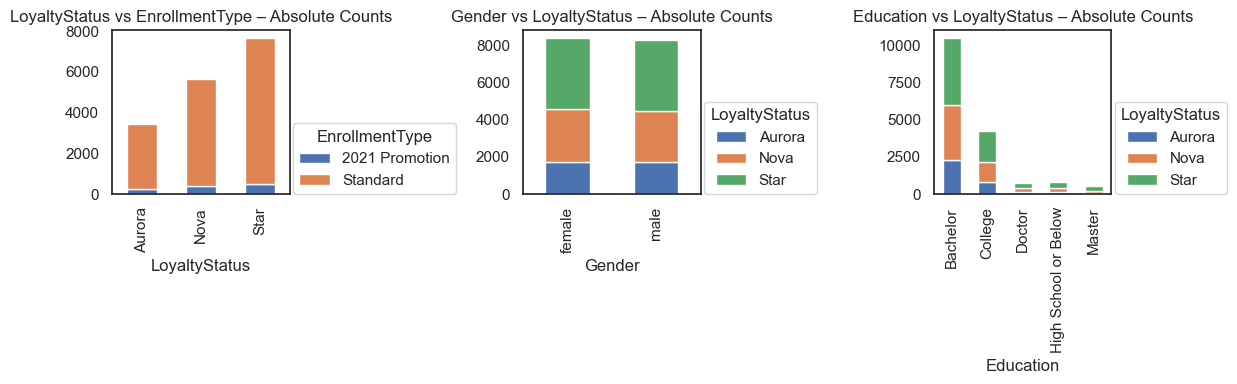

In [172]:
fig, axes = plt.subplots(1,3, figsize=(12,4))

pd.crosstab(customers['LoyaltyStatus'], customers['EnrollmentType']).plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('LoyaltyStatus vs EnrollmentType – Absolute Counts')
axes[0].legend(title='EnrollmentType', loc=(1.02,0))

pd.crosstab(customers['Gender'], customers['LoyaltyStatus']).plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Gender vs LoyaltyStatus – Absolute Counts')
axes[1].legend(title='LoyaltyStatus', loc=(1.02,0))

pd.crosstab(customers['Education'], customers['LoyaltyStatus']).plot(kind='bar', stacked=True, ax=axes[2])
axes[2].set_title('Education vs LoyaltyStatus – Absolute Counts')
axes[2].legend(title='LoyaltyStatus', loc=(1.02,0))

plt.tight_layout()
plt.show()

The first chart (Loyalty Status vs Enrollment Type) shows that most customers in each loyalty category belong to the Standard enrollment type, while the 2021 Promotion group represents only a small share. The “Star” segment is the largest and most dominant across enrollment types, followed by “Nova” and then “Aurora.”

The second chart (Gender vs Loyalty Status) indicates that the distribution of loyalty status is very similar for male and female customers. Both genders show comparable proportions of “Star,” “Nova,” and “Aurora” members, suggesting that gender does not play a significant role in determining loyalty level within this dataset.

In the third chart within each education group, the distribution across loyalty statuses (Star, Nova, and Aurora) remains relatively similar, with Star members consistently forming the largest segment. This suggests that education level does not strongly influence customer loyalty status, although customers with higher education tend to be more represented overall in the program.

<a class="anchor" id="3rd-bullet">

### 1.5.3. Visualization of Relationships Between Variables
    
</a>

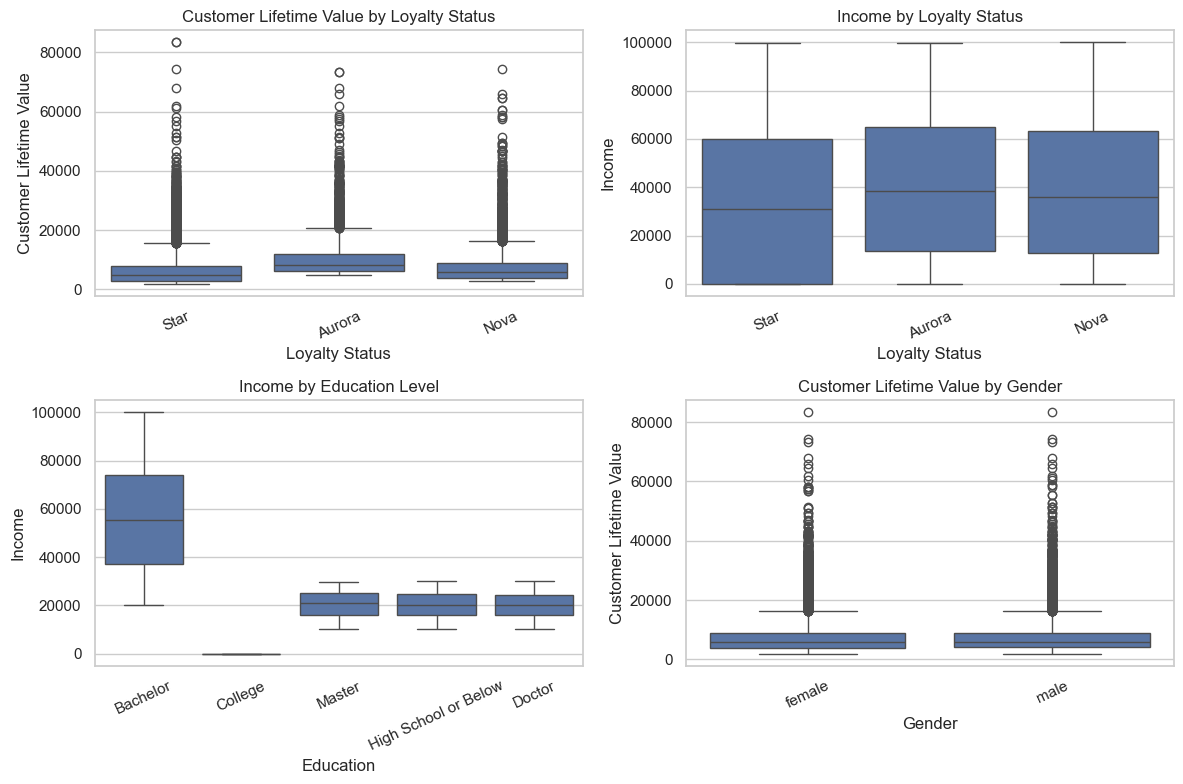

In [173]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#LoyaltyStatus × Customer Lifetime Value
sns.boxplot(
    data=customers,
    x='LoyaltyStatus',
    y='Customer Lifetime Value',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Customer Lifetime Value by Loyalty Status')
axes[0, 0].set_xlabel('Loyalty Status')
axes[0, 0].set_ylabel('Customer Lifetime Value')

#LoyaltyStatus x Income
sns.boxplot(
    data=customers,
    x='LoyaltyStatus',
    y='Income',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Income by Loyalty Status')
axes[0, 1].set_xlabel('Loyalty Status')
axes[0, 1].set_ylabel('Income')

#Education × Income
sns.boxplot(
    data=customers,
    x='Education',
    y='Income',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Income by Education Level')
axes[1, 0].set_xlabel('Education')
axes[1, 0].set_ylabel('Income')

#Gender × Customer Lifetime Value
sns.boxplot(
    data=customers,
    x='Gender',
    y='Customer Lifetime Value',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Customer Lifetime Value by Gender')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Customer Lifetime Value')

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


The boxplots reveal how Income and Customer Lifetime Value (CLV) vary across different categorical variables.

In the first chart, Customer Lifetime Value by Loyalty Status, customers with a “Star” status tend to have slightly higher lifetime value than “Aurora” or “Nova” members, although there is significant variability and many outliers across all groups.

In Income by Loyalty Status, income levels appear similar among loyalty groups, suggesting that loyalty is not strongly related to customers’ income.

The Income by Education Level plot shows a clearer pattern: customers with a bachelor’s degree have higher and more variable income, while those with lower education levels (such as “High School or Below”) tend to earn less.

Finally, Customer Lifetime Value by Gender indicates no substantial difference between male and female customers — both groups show similar distributions and ranges of lifetime value.

Overall, these plots suggest that while education influences income, gender and loyalty status do not have a strong impact on customer lifetime value.

<a class="anchor" id="3rd-bullet">

### 1.6. Pre-Processing
    
</a>

<a class="anchor" id="3rd-bullet">

### 1.6.1. Filling Missing Values
    
</a>

- As we saw before, there are missing values in the variables "Income" (20 NaN's), "Customer Lifetime Value" (20 NaN's) and "CancellationDate" (14611 NaN's).

- We will start by treating the ***missing values in "Income" and "Customer Lifetime Value"***

In [174]:
# Check the number of missing values again
customers[['Income', 'Customer Lifetime Value']].isna().sum()

Income                     20
Customer Lifetime Value    20
dtype: int64

- We decided to use the ***median*** to fill the missing values of these two variables.

- Given the right-skewed distribution of both variables, median imputation was selected as the most appropriate method.

- The median is less sensitive to extreme values compared to the mean, ensuring that the imputed data reflects the central tendency of the distributions without introducing artificial bias.

- Also, we thought that using ***KNN*** could be unnecessary and possibly excessive, because we only have 20 missing values (≈0.12%), all in the same rows. Using KNN here might add noise rather than improve data quality, since it depends on distance calculations between variables that may not be properly scaled.

- This approach preserves all records, maintains dataset consistency, and minimizes potential distortion in subsequent clustering analysis.

In [175]:
# Compute median values
median_income = customers['Income'].median()
median_clv = customers['Customer Lifetime Value'].median()

# Fill missing values with the median
customers['Income'].fillna(median_income, inplace=True)
customers['Customer Lifetime Value'].fillna(median_clv, inplace=True)

# Confirm there are no missing values left
customers[['Income', 'Customer Lifetime Value']].isna().sum()


C:\Users\User\AppData\Local\Temp\ipykernel_17372\2050996778.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['Income'].fillna(median_income, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_17372\2050996778.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

Income                     0
Customer Lifetime Value    0
dtype: int64

- Now, we will treat the ***missing values in "CancellationDate".***

- This variables shows when a client left the program. If the value is NaN, it means that the client never left the program, so the client is still active.

- We decided to create a new variable, "Churn", that has this logic:

     - 1 if the client is still active (NaN in "CancellationDate")
     - 0 if client left the program (there is a date in "CancellationDate")

In [176]:
# Creation of variable Churn
customers['Churn'] = customers['CancellationDate'].notna().astype(int)

customers['Churn'].value_counts()


Churn
0    14471
1     2286
Name: count, dtype: int64

This means that 14471 customers left the program, and 2286 didn't.

- The variable "CancellationDate" contained 14611 missing values, corresponding to customers who remain active in the loyalty program.
Instead of treating these missing values as data quality issues, they were reinterpreted as meaningful information.

- A new binary variable, "Churn", was created to indicate whether a customer is currently active (1) or has canceled their membership (0).
This feature will be useful in subsequent analyses to identify behavioral differences between active and inactive customers and to support segmentation based on retention patterns.

<a class="anchor" id="3rd-bullet">

### 1.6.2. Feature Engineering
    
</a>

After creating the variable "Churn", there are a few more variables that we decided to create to enhance the analytical depth of the dataset.

These new variables were created to represent temporal, demographic, and behavioral dimensions that are not directly available in the raw data but are highly relevant for customer segmentation.

### "AccountDuration"

-  The first variable we decided to create, "AccountDuration" shows the total ***number of days that a customer was or has been active in the program***.

- It was calculated as the difference between "CancellationDate" and "EnrollmentDateOpening".
For customers still active in the program, missing cancellation dates were replaced with the current date, allowing the feature to represent ongoing membership duration.

- This variable provides valuable temporal context for segmentation, as it reflects customer's duration in the program and potential loyalty behaviors.

In [177]:
# Calculate account duration (in days)
customers['AccountDuration'] = (
    (customers['CancellationDate'].fillna(pd.Timestamp.now()) - customers['EnrollmentDateOpening'])
    .dt.days
)


### "YearsInProgram"

- This variable is similiar to "AccountDuration" but instead of days it's years (more interpertable in graphs)

- It represents the total number of years a customer has been enrolled in the loyalty program. This feature helps analyze whether long-term members tend to have higher Customer Lifetime Value or exhibit greater loyalty.

In [178]:
customers['YearsInProgram'] = customers['AccountDuration'] / 365


### "HasHighIncome"

- This new binary feature categorizes customers as high-income (1) or low/medium-income (0), based on the median income value.

- This feature supports analyses on whether income level correlates with customer profitability or loyalty.

- To create the variable, we computed the median value of the "Income" variable, because the median splits the dataset into two equal parts — 50% of customers earn less and 50% earn more.

- This way, the values above the median are assigned 1 (high income) and the values below the median are assigned 0 (low/medium income).

In [179]:
median_income = customers['Income'].median()
customers['HasHighIncome'] = (customers['Income'] > median_income).astype(int)


### "MaritalGroup"

- Simplifies the Marital Status variable (which originally had the categories "Married", Divorced" and "Single") into two broader categories: Married and Not Married. So, joining "Single" and "Divorced".

- This reduces noise and helps ensure more stable cluster formation, avoiding underrepresented categories.

In [180]:
customers['MaritalGroup'] = customers['Marital Status'].replace({
    'Married': 'Married',
    'Single': 'Not Married',
    'Divorced': 'Not Married'
})


### "EnrollmentYear"

- This variable extracts the year of enrollment from "EnrollmentDateOpening".

- For example, maybe many customers joined the program in 2020 because there was a specific campaign.

- It allows tracking customer acquisition trends over time and understanding whether older members differ from recent ones.

In [181]:
customers['EnrollmentYear'] = customers['EnrollmentDateOpening'].dt.year


### "EducationLevelCode"

- Encodes education levels as ordinal values (from lowest to highest).

- This transformation supports correlation analysis and machine learning models requiring numeric inputs.

In [182]:
education_order = {'High School or Below': 1, 'College': 2, 'Bachelor': 3, 'Master': 4, 'Doctor': 5}
customers['EducationLevelCode'] = customers['Education'].map(education_order)


### "ProvinceActivity"

- Represents the density of customers per province (counts the number of customers in the same province as the customer)

- It can reveal regional concentration patterns and help identify geographic differences in loyalty behavior. So, it can pretty much show if a certain customer belongs to a province that is more or less active.

In [183]:
province_counts = customers['Province or State'].value_counts()
customers['ProvinceActivity'] = customers['Province or State'].map(province_counts)


In [184]:
# Showing the dataset with the new variables
customers.head()

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Churn,AccountDuration,YearsInProgram,HasHighIncome,MaritalGroup,EnrollmentYear,EducationLevelCode,ProvinceActivity
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,0,2440,6.684932,1,Married,2019,3,5410
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,0,2418,6.624658,0,Not Married,2019,2,995
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,1,1274,3.490411,0,Not Married,2017,2,4379
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,0,3534,9.682192,0,Not Married,2016,2,5410
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,0,2918,7.994521,1,Married,2017,3,3280


In [185]:
customers.dtypes

Loyalty#                            int64
Province or State                  object
City                               object
Latitude                          float64
Longitude                         float64
Postal code                        object
Gender                             object
Education                          object
Location Code                      object
Income                            float64
Marital Status                     object
LoyaltyStatus                      object
EnrollmentDateOpening      datetime64[ns]
CancellationDate           datetime64[ns]
Customer Lifetime Value           float64
EnrollmentType                     object
Churn                               int64
AccountDuration                     int64
YearsInProgram                    float64
HasHighIncome                       int64
MaritalGroup                       object
EnrollmentYear                      int32
EducationLevelCode                  int64
ProvinceActivity                  

<a class="anchor" id="3rd-bullet">

### 1.7. Visual Exploration Including The New Variables
    
</a>

<a class="anchor" id="3rd-bullet">

### 1.7.1. Visualing Numeric Variables
    
</a>

In [186]:
# List of the new numeric variables
numeric_features = ['AccountDuration', 'YearsInProgram', 'ProvinceActivity', 'EducationLevelCode']

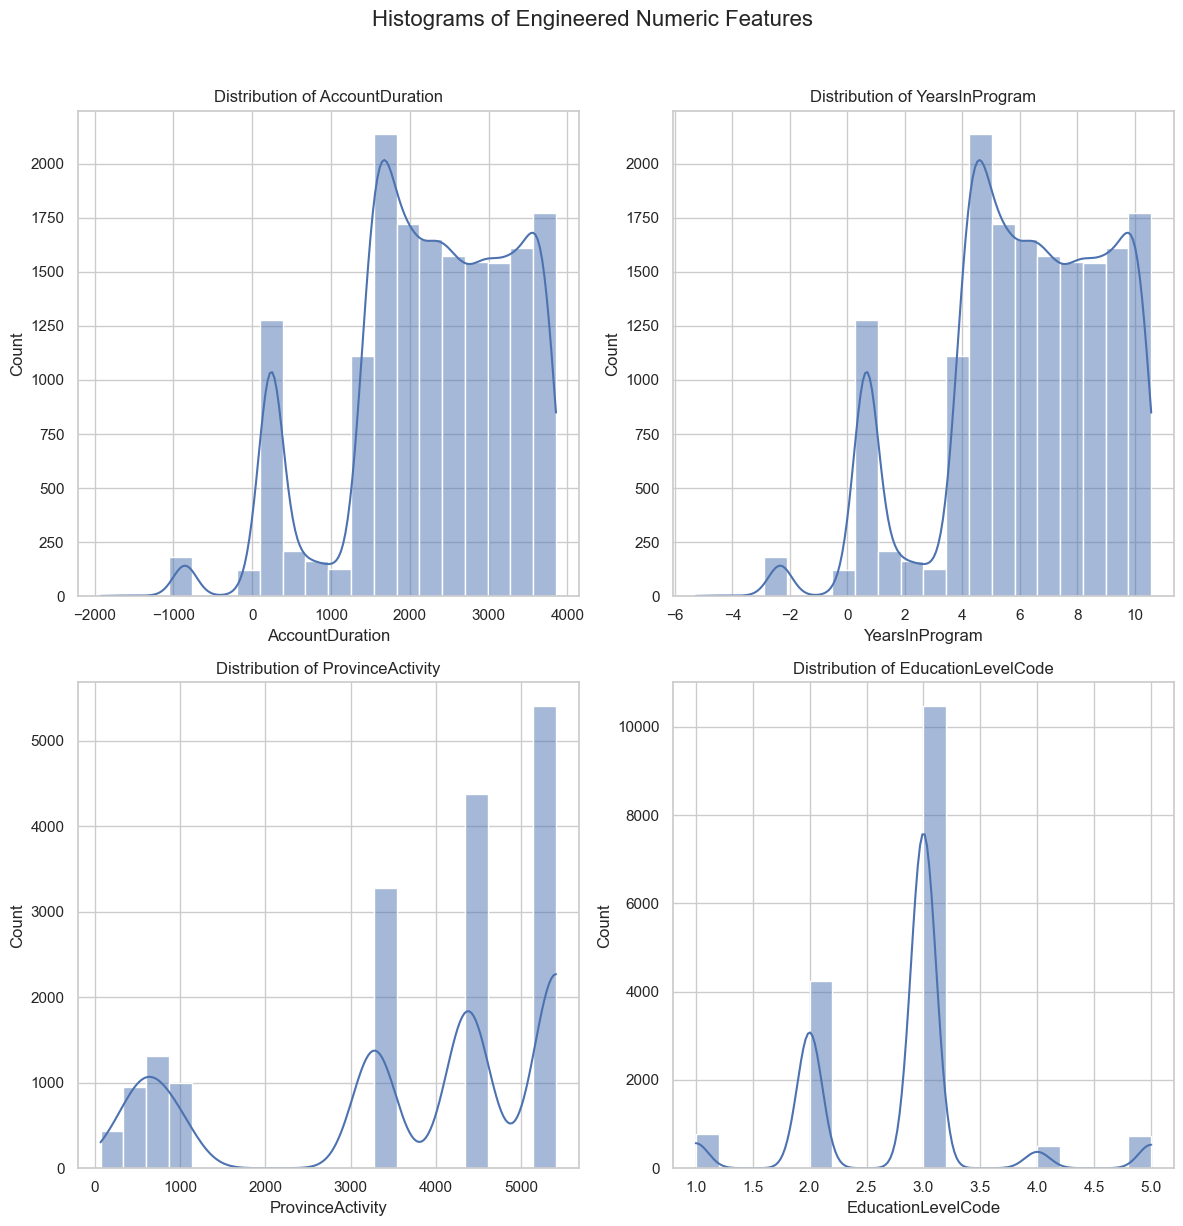

In [187]:
sp_rows = ceil(len(numeric_features) / 2)
sp_cols = 2
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(12, 6 * sp_rows))

for ax, feat in zip(axes.flatten(), numeric_features):
    sns.histplot(customers[feat], bins=20, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feat}', fontsize=12)
plt.suptitle("Histograms of Engineered Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

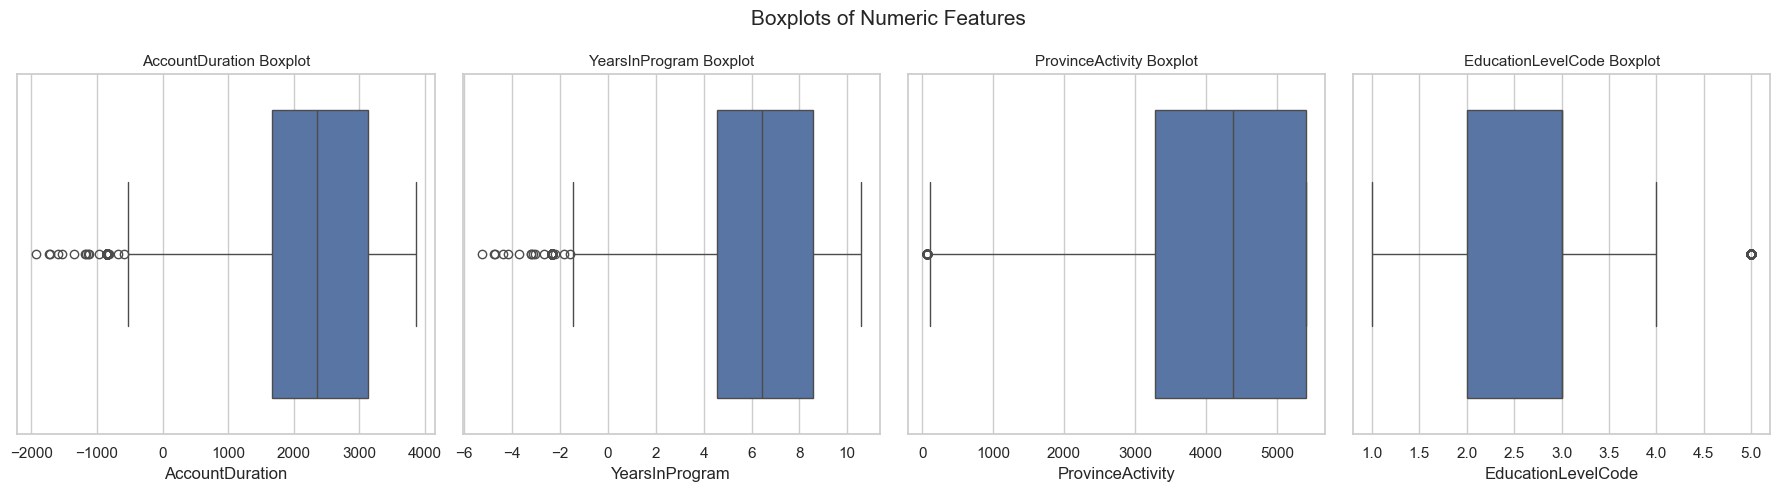

In [188]:
# Boxplots
fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 5), tight_layout=True)
for ax, feat in zip(axes.flatten(), numeric_features):
    sns.boxplot(x=customers[feat], ax=ax)
    ax.set_title(f'{feat} Boxplot', fontsize=11)
plt.suptitle("Boxplots of Numeric Features", fontsize=15)
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_17372\3048727431.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=customers[feat], order=customers[feat].value_counts().index, ax=ax, palette="crest")
C:\Users\User\AppData\Local\Temp\ipykernel_17372\3048727431.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=customers[feat], order=customers[feat].value_counts().index, ax=ax, palette="crest")
C:\Users\User\AppData\Local\Temp\ipykernel_17372\3048727431.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=customers[feat], order=custom

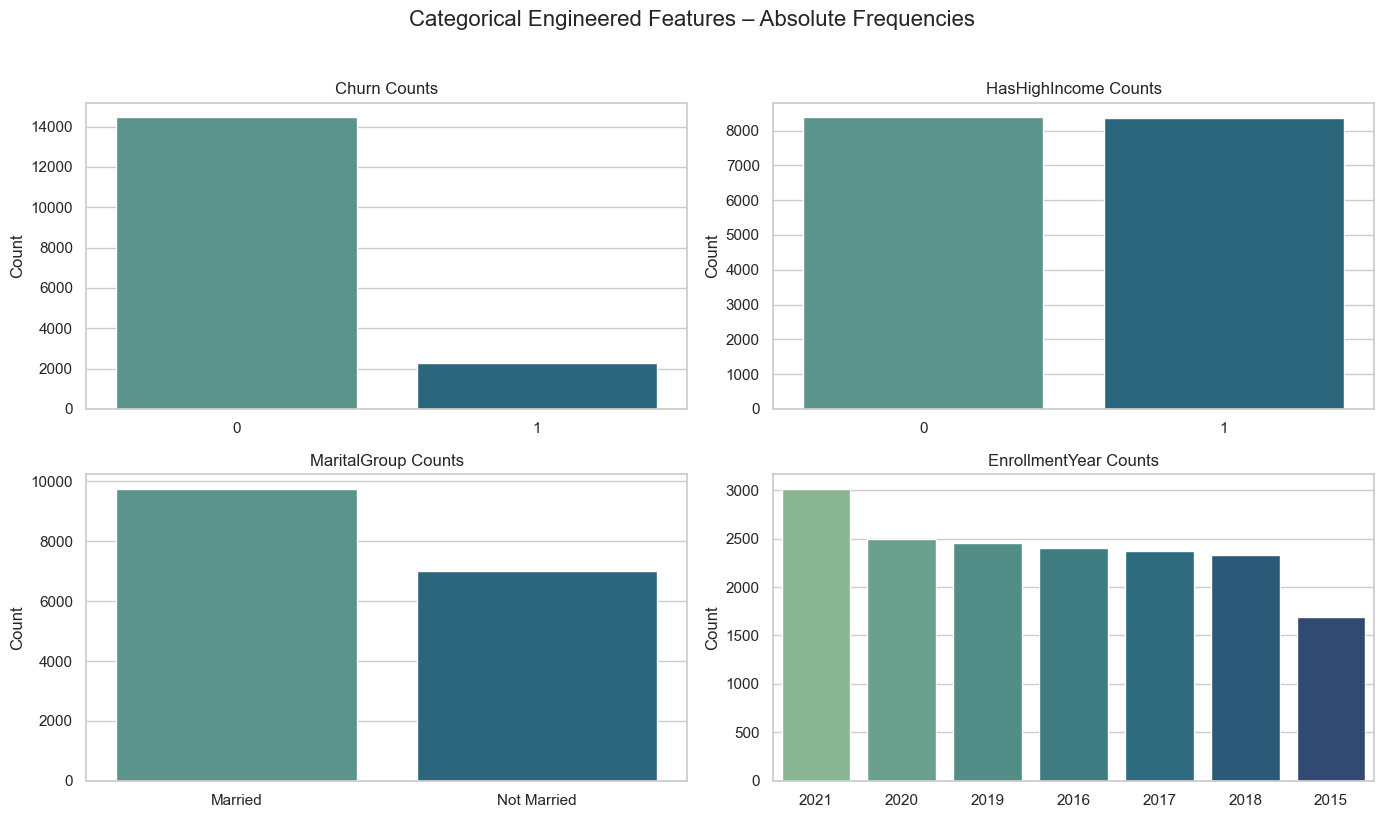

In [189]:
cat_features = ['Churn', 'HasHighIncome', 'MaritalGroup', 'EnrollmentYear']

sp_rows = 2
sp_cols = ceil(len(cat_features) / 2)
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(14, 8))

for ax, feat in zip(axes.flatten(), cat_features):
    sns.countplot(x=customers[feat], order=customers[feat].value_counts().index, ax=ax, palette="crest")
    ax.set_title(f'{feat} Counts', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
plt.suptitle("Categorical Engineered Features – Absolute Frequencies", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


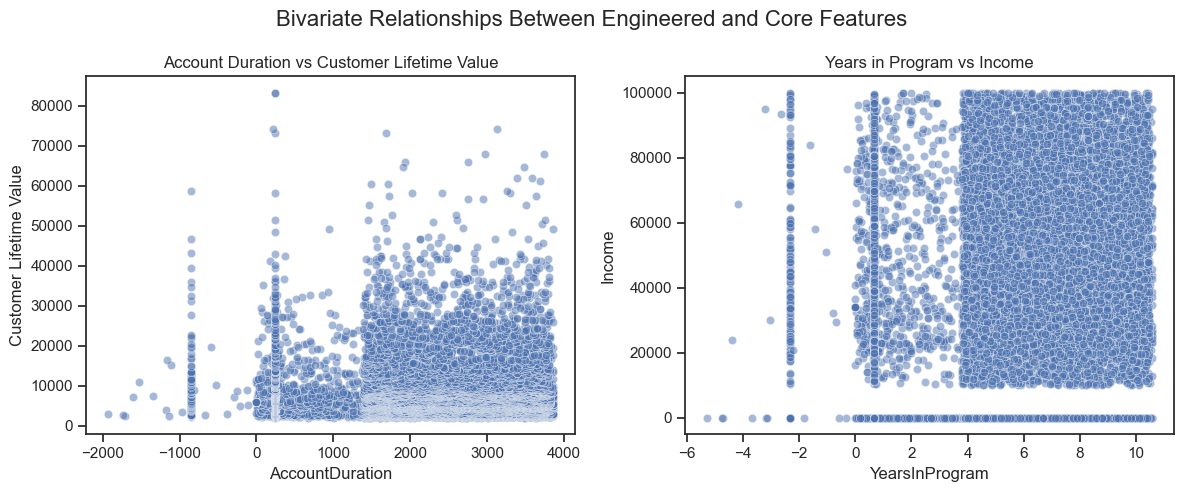

In [190]:
sns.set_style("ticks")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)

sns.scatterplot(data=customers, x='AccountDuration', y='Customer Lifetime Value', alpha=0.5, ax=axes[0])
axes[0].set_title('Account Duration vs Customer Lifetime Value')

sns.scatterplot(data=customers, x='YearsInProgram', y='Income', alpha=0.5, ax=axes[1])
axes[1].set_title('Years in Program vs Income')

plt.suptitle("Bivariate Relationships Between Engineered and Core Features", fontsize=16)
plt.show()


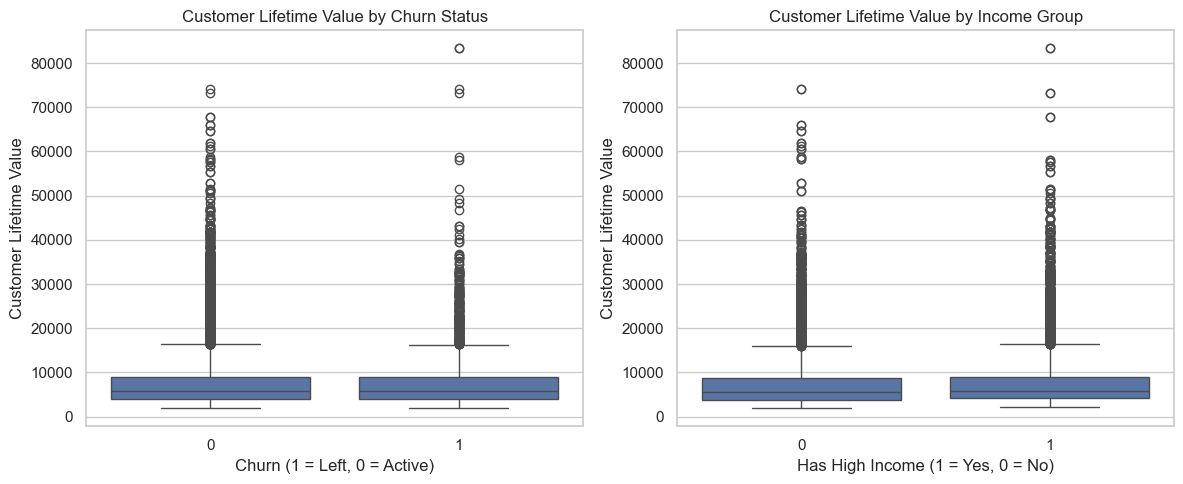

In [191]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=customers, x='Churn', y='Customer Lifetime Value', ax=axes[0])
axes[0].set_title('Customer Lifetime Value by Churn Status')
axes[0].set_xlabel('Churn (1 = Left, 0 = Active)')

sns.boxplot(data=customers, x='HasHighIncome', y='Customer Lifetime Value', ax=axes[1])
axes[1].set_title('Customer Lifetime Value by Income Group')
axes[1].set_xlabel('Has High Income (1 = Yes, 0 = No)')

plt.tight_layout()
plt.show()


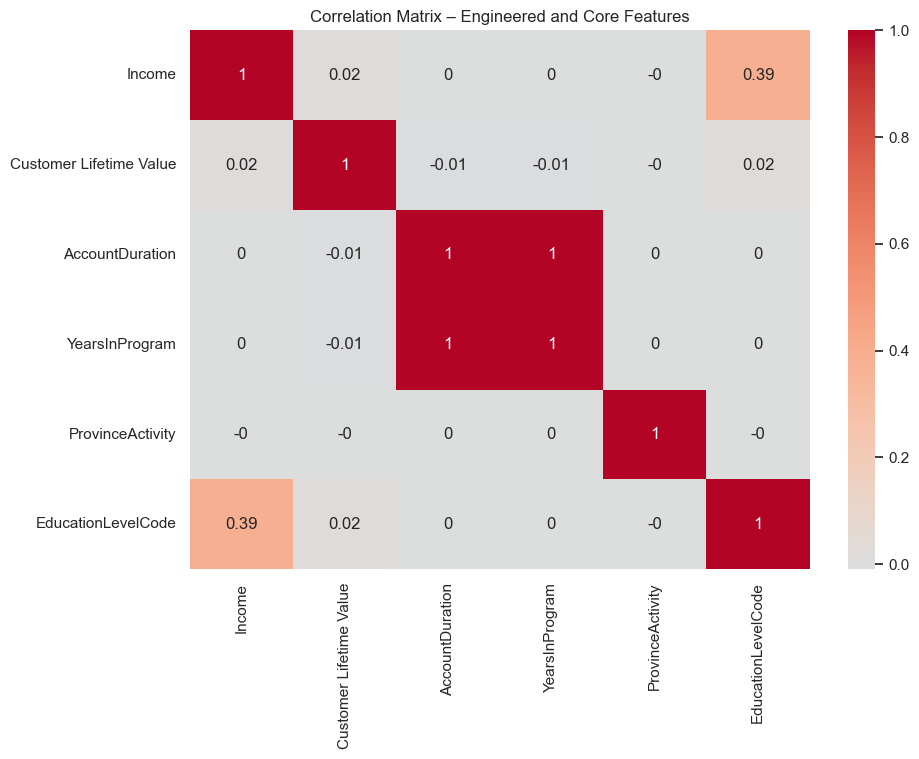

In [192]:
corr_features = ['Income', 'Customer Lifetime Value', 'AccountDuration', 'YearsInProgram', 'ProvinceActivity', 'EducationLevelCode']
corr = customers[corr_features].corr(method='pearson').round(2)

fig = plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix – Engineered and Core Features")
plt.show()


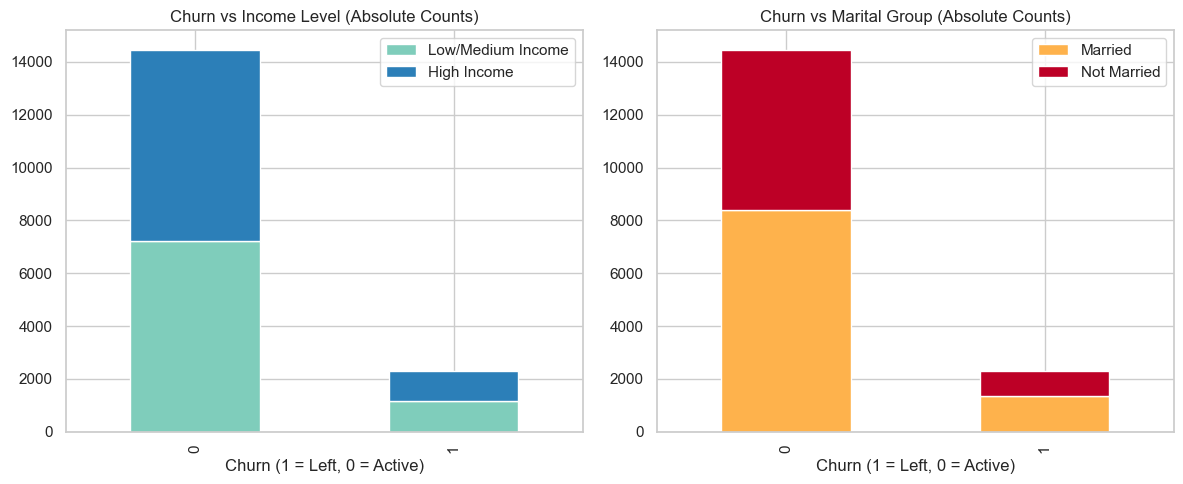

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn vs HasHighIncome
pd.crosstab(customers['Churn'], customers['HasHighIncome']).plot.bar(stacked=True, ax=axes[0], color=['#7fcdbb','#2c7fb8'])
axes[0].set_title('Churn vs Income Level (Absolute Counts)')
axes[0].set_xlabel('Churn (1 = Left, 0 = Active)')
axes[0].legend(['Low/Medium Income', 'High Income'])

# Churn vs MaritalGroup
pd.crosstab(customers['Churn'], customers['MaritalGroup']).plot.bar(stacked=True, ax=axes[1], color=['#feb24c','#bd0026'])
axes[1].set_title('Churn vs Marital Group (Absolute Counts)')
axes[1].set_xlabel('Churn (1 = Left, 0 = Active)')
axes[1].legend(['Married', 'Not Married'])

plt.tight_layout()
plt.show()


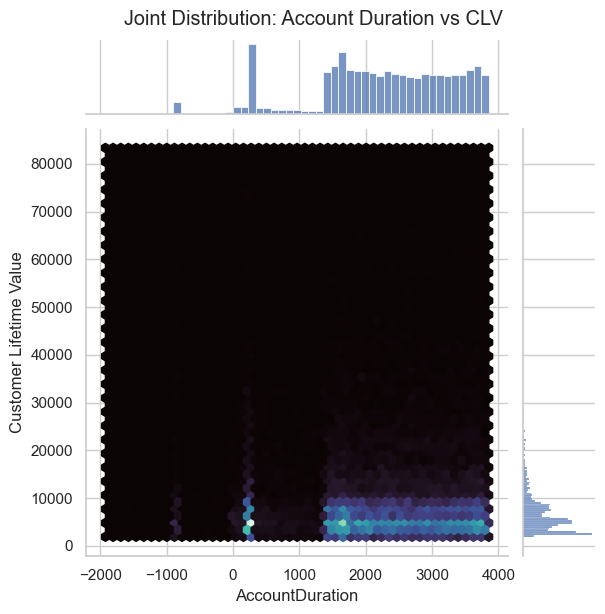

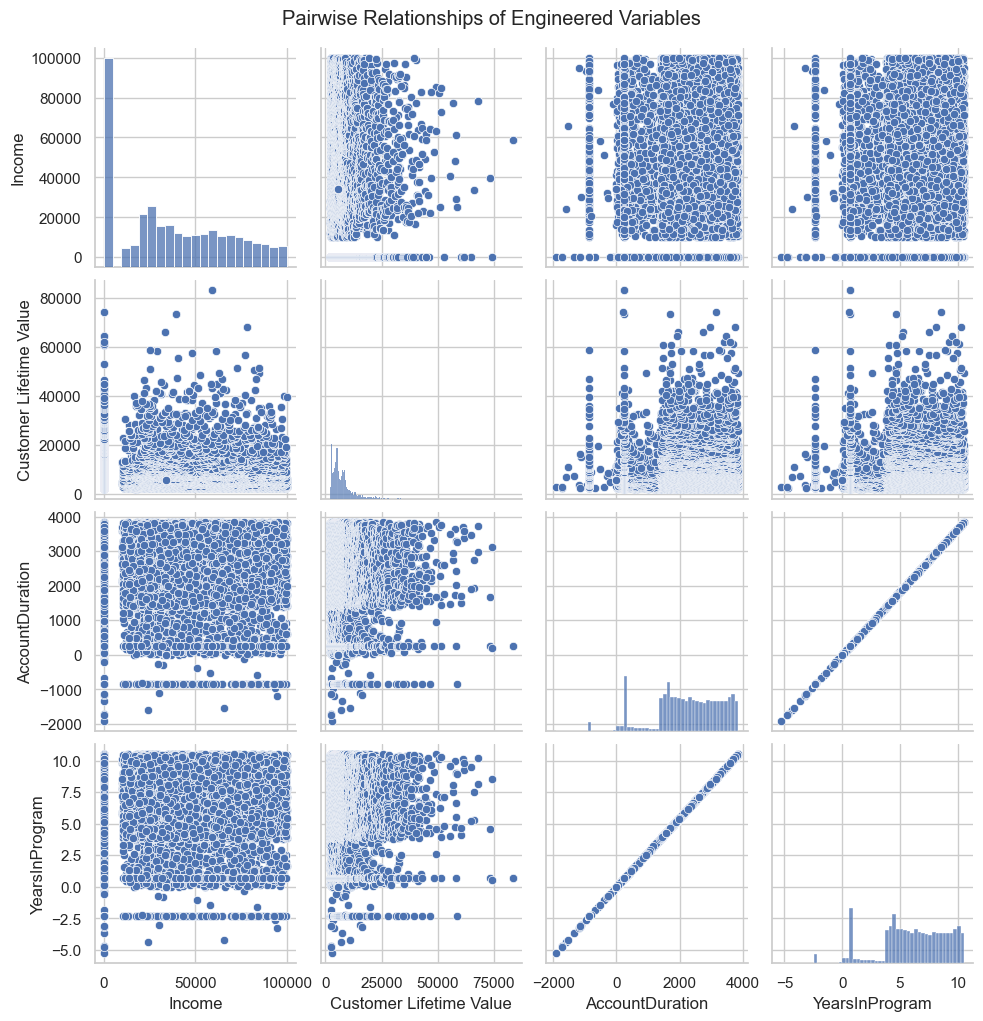

In [194]:
sns.jointplot(data=customers, x='AccountDuration', y='Customer Lifetime Value', kind='hex', cmap='mako')
plt.suptitle('Joint Distribution: Account Duration vs CLV', y=1.02)
plt.show()

sns.pairplot(customers[['Income', 'Customer Lifetime Value', 'AccountDuration', 'YearsInProgram']], diag_kind='hist')
plt.suptitle("Pairwise Relationships of Engineered Variables", y=1.02)
plt.show()


<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 2. Flights Dataset
    

    
</div>

<a class="anchor" id="1st-bullet">

## Importing, Exploring and Pre-processing   
</a>

<a class="anchor" id="3rd-bullet">

### 2.1. Import the dataset
    
</a>

In [195]:
flights = pd.read_csv('DM_AIAI_FlightsDB.csv')

<a class="anchor" id="3rd-bullet">

### 2.2. Exploratory Data Analysis 
    
</a>

In [196]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [197]:
flights.shape

(608436, 10)

The flights dataset consists of 608436 observations and 10 variables.

In [198]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

In [199]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [200]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object


- The variable "YearMonthDate" should be datetime

In [201]:
flights[['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
         'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']].describe()


,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
count,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000
mean,3.908107,0.983944,7939.341419,793.777781,235.251678,2.324835
std,5.057889,2.003785,10260.421873,1025.918521,983.233374,9.725168
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,856.400000,85.275000,0.000000,0.000000
75%,7.200000,0.900000,15338.175000,1533.712500,0.000000,0.000000
max,21.000000,11.000000,42040.000000,4204.000000,7496.000000,74.000000


#### Summary:

- Most customers don’t fly every month, but there is a small group of highly active travellers.

- Flight frequency and distance are heavily skewed, showing a mix of occasional and heavy users.

- Point accumulation exceeds redemption, suggesting latent loyalty value that the airline could leverage (e.g., campaigns to encourage point spending).

- Some customers travel long distances or frequently with companions, likely representing premium or family-oriented segments.

<a class="anchor" id="3rd-bullet">

### 2.2.3. Checking for Missing Values
    
</a>

In [202]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [203]:
# Making sure that there are really no missing values in this dataset
# Because sometimes instead of NAn, the rows have ""

# replace "" by nans
flights.replace("", np.nan, inplace=True)

# count of missing values
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

<a class="anchor" id="3rd-bullet">

### 2.2.4. Checking for Duplicated Values
    
</a>

In [204]:
# Checking for duplicated observations
flights.duplicated().sum()

np.int64(2903)

In [205]:
# Removing all duplicates (2903)
flights = flights.drop_duplicates()


In [206]:
flights.duplicated().sum()


np.int64(0)

In [207]:
# Checking for rows with the same client (loyalty#), year and month
# But the other columns don't need to be the same

flights[flights.duplicated(subset=['Loyalty#', 'Year', 'Month'], keep=False)]


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
27,279419,2021,12,12/1/2021,12.0,0.0,11849.0,1184.00,0.0,0.0
171,990512,2021,12,12/1/2021,5.0,2.0,31991.0,3199.00,0.0,0.0
248,322169,2021,12,12/1/2021,2.0,0.0,17125.0,1712.00,0.0,0.0
297,106001,2021,12,12/1/2021,7.0,0.0,26469.0,2646.00,0.0,0.0
678,402697,2021,12,12/1/2021,12.0,3.0,10721.0,1072.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
608222,988392,2019,12,12/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
608248,989528,2019,12,12/1/2019,11.7,0.9,28453.5,2845.35,0.0,0.0
608249,989528,2019,12,12/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
608298,992168,2019,12,12/1/2019,11.7,4.5,2987.1,298.71,0.0,0.0


In [208]:
# Checking how many cases of clients with multiple rows in the same year and month exist

flights.duplicated(subset=['Loyalty#', 'Year', 'Month']).sum()


np.int64(3001)

In [209]:
# Remove duplicated rows keeping only the first occurrence
flights = flights.drop_duplicates(subset=['Loyalty#', 'Year', 'Month'], keep='first')

# Confirm there are no more duplicates
flights.duplicated(subset=['Loyalty#', 'Year', 'Month']).sum()


np.int64(0)

In [210]:
flights.shape

(602532, 10)

After reviewing the duplicated entries, we confirmed that they represent multiple
records of the same customer within the same year and month. 

We decided to keep only the first occurrence and remove the remaining duplicates. 

This ensures that each customer has a single record per month while maintaining
data integrity.


<a class="anchor" id="3rd-bullet">

### 2.3. Initial Data Preparation
    
</a>

<a class="anchor" id="3rd-bullet">

### 2.3.1. Converting variables to datetime
    
</a>

In [211]:
flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'])

In [212]:
flights[['YearMonthDate']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 602532 entries, 0 to 608435
Data columns (total 1 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   YearMonthDate  602532 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 9.2 MB


<a class="anchor" id="3rd-bullet">

### 2.3.2. Converting variables to integer
    
</a>

In [213]:
#turn into int
flights['NumFlightsWithCompanions'] = flights['NumFlightsWithCompanions'].round().astype(int)

In [214]:
#turn into int
flights['NumFlights'] = flights['NumFlights'].round().astype(int)

In [215]:
flights[['NumFlights']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 602532 entries, 0 to 608435
Data columns (total 1 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   NumFlights  602532 non-null  int64
dtypes: int64(1)
memory usage: 9.2 MB


In [216]:
flights[['NumFlightsWithCompanions']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 602532 entries, 0 to 608435
Data columns (total 1 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   NumFlightsWithCompanions  602532 non-null  int64
dtypes: int64(1)
memory usage: 9.2 MB


<a class="anchor" id="3rd-bullet">

### 2.3.3. Checking for inconsistencies
    
</a>

In [217]:
invalid_rows = flights[(flights['NumFlights'] == 0) & 
        ((flights['DistanceKM'] > 0) | 
         (flights['PointsAccumulated'] > 0) |
         (flights['PointsRedeemed'] > 0) |
         (flights['DollarCostPointsRedeemed'] > 0) |
         (flights['NumFlightsWithCompanions'] > 0))]
print("Inconsistent rows:", len(invalid_rows))
print("Percentage of dataset:", round(len(invalid_rows) / len(flights) * 100, 2), "%")

Inconsistent rows: 5856
Percentage of dataset: 0.97 %


- Since it is less than 1% of the rows I think that we sould delete the rows

In [218]:
flights = flights.drop(invalid_rows.index).reset_index(drop=True)
print("Removed inconsistent rows:", len(invalid_rows))
print("Remaining rows:", len(flights))

Removed inconsistent rows: 5856
Remaining rows: 596676


<a class="anchor" id="3rd-bullet">

### 2.4. Data Visualization
    
</a>

<a class="anchor" id="3rd-bullet">

### 2.4.1. Visualization of Numeric Variables (Univariate Analysis)
    
</a>

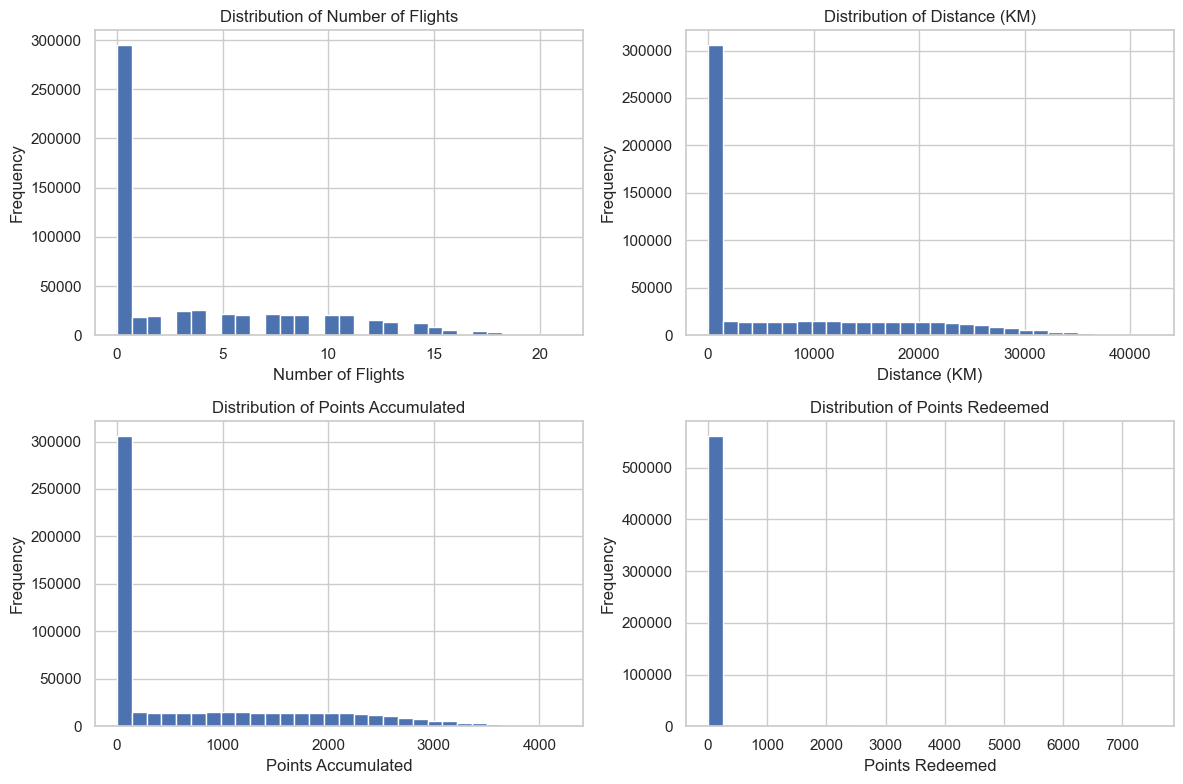

In [219]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(flights['NumFlights'], bins=30)
axes[0, 0].set_title('Distribution of Number of Flights')
axes[0, 0].set_xlabel('Number of Flights')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(flights['DistanceKM'], bins=30)
axes[0, 1].set_title('Distribution of Distance (KM)')
axes[0, 1].set_xlabel('Distance (KM)')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(flights['PointsAccumulated'], bins=30)
axes[1, 0].set_title('Distribution of Points Accumulated')
axes[1, 0].set_xlabel('Points Accumulated')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(flights['PointsRedeemed'], bins=30)
axes[1, 1].set_title('Distribution of Points Redeemed')
axes[1, 1].set_xlabel('Points Redeemed')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


The distributions of flight-related variables are highly right-skewed, showing that most customers have very limited flight activity. The majority of observations correspond to customers with few or no flights, short total travel distances, and low numbers of points accumulated or redeemed. Only a small group of frequent flyers shows much higher values, forming the long right tails visible in each plot. This pattern suggests that the program has a large base of low-activity members and a smaller segment of highly active travelers who contribute disproportionately to the total points and distance metrics.

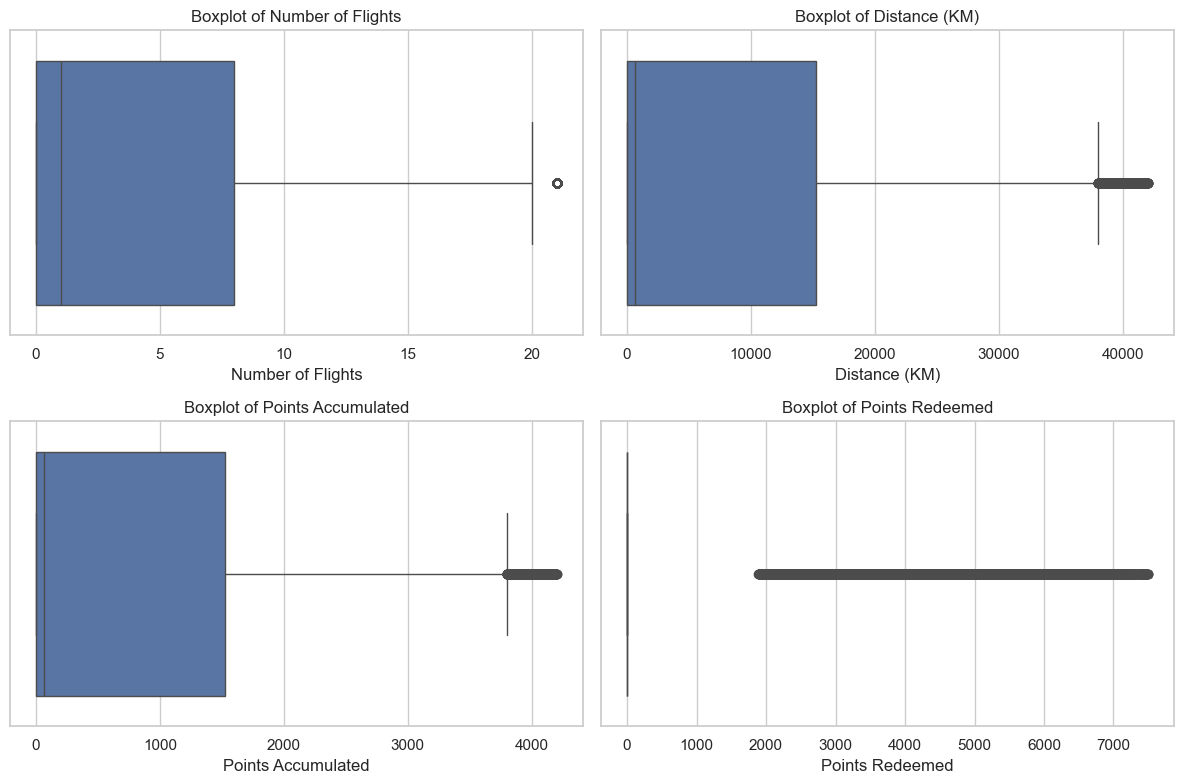

In [220]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x=flights['NumFlights'], ax=axes[0, 0])
axes[0, 0].set_title('Boxplot of Number of Flights')
axes[0, 0].set_xlabel('Number of Flights')

sns.boxplot(x=flights['DistanceKM'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Distance (KM)')
axes[0, 1].set_xlabel('Distance (KM)')

sns.boxplot(x=flights['PointsAccumulated'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of Points Accumulated')
axes[1, 0].set_xlabel('Points Accumulated')

sns.boxplot(x=flights['PointsRedeemed'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Points Redeemed')
axes[1, 1].set_xlabel('Points Redeemed')


plt.tight_layout()
plt.show()


These boxplots illustrate the presence of significant variability and multiple outliers across all flight-related variables. For each metric — Number of Flights, Distance (KM), Points Accumulated, and Points Redeemed — most observations are concentrated near the lower end of the scale, while a small group of customers shows extremely high values. This confirms that the dataset is highly skewed, with a large majority of low-activity members and a few very active flyers who travel more frequently, cover longer distances, and accumulate or redeem substantially more points.

<a class="anchor" id="3rd-bullet">

### 2.4.2 Correlation Analysis (Bivariate Relationships)
    
</a>

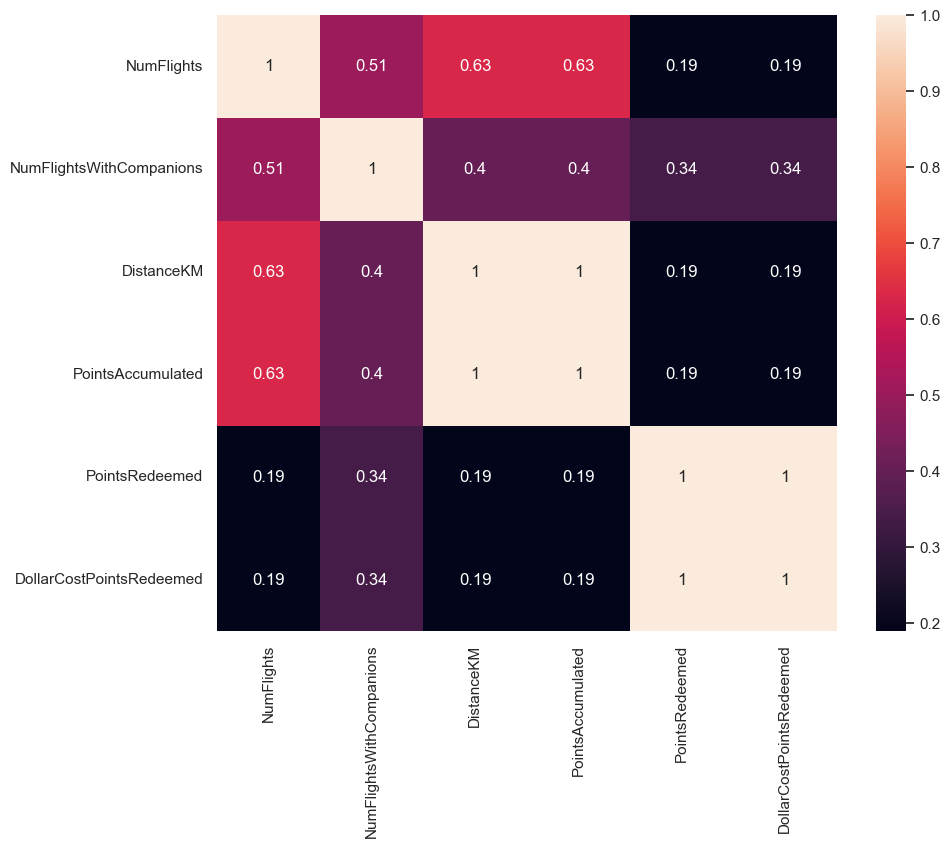

In [221]:
sns.set(style="white")

numeric_features = [
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'DollarCostPointsRedeemed'
]

corr = flights[numeric_features].corr(method='pearson')

fig = plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=True, )
plt.show()

The correlation heatmap reveals moderate to strong positive relationships among the flight activity variables. Specifically, Number of Flights, Distance (KM), and Points Accumulated are strongly correlated (around 0.6), indicating that customers who fly more frequently also travel longer distances and earn more points — an expected pattern in a mileage-based loyalty program. The Number of Flights with Companions shows weaker correlations with these variables, suggesting that traveling with others is less tied to overall flight activity. In contrast, Points Redeemed and Dollar Cost of Points Redeemed exhibit only weak correlations with the other metrics, implying that redemption behavior is more independent from flight frequency and distance traveled.

Text(0.5, 1.0, 'Relationship between Number of Flights and Distance')

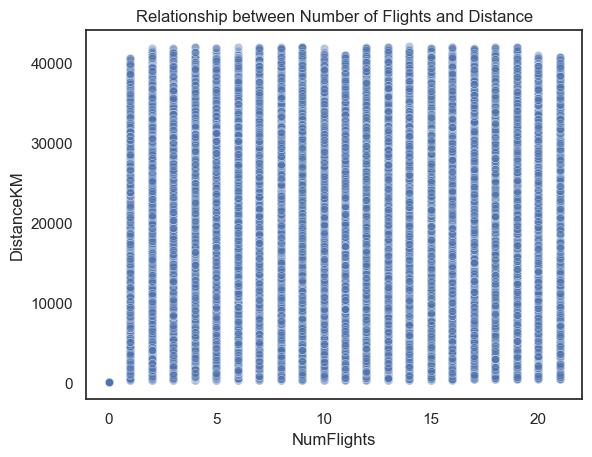

In [222]:
sns.scatterplot(data=flights, x='NumFlights', y='DistanceKM', alpha=0.4)
plt.title('Relationship between Number of Flights and Distance')

This scatterplot shows how the total flight distance varies with the number of flights per customer.
The points are vertically aligned because the number of flights is an integer, while distances are continuous.
Most customers fly few times, but those who travel more tend to cover larger total distances — as expected in a frequent-flyer context.

Text(0.5, 1.0, 'Points Accumulated vs Points Redeemed')

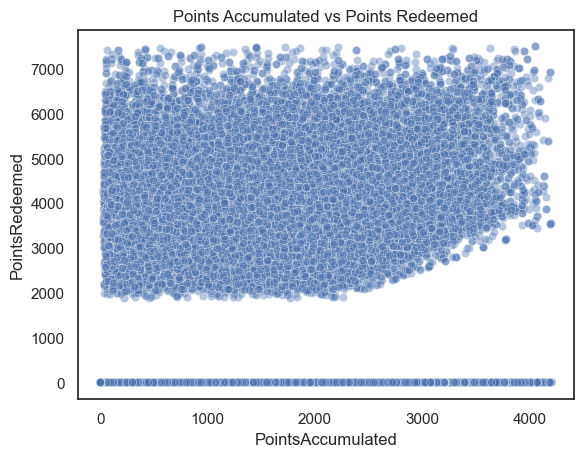

In [223]:
sns.scatterplot(data=flights, x='PointsAccumulated', y='PointsRedeemed', alpha=0.4)
plt.title('Points Accumulated vs Points Redeemed')

This chart explores the relationship between loyalty points earned and points redeemed.
There is a visible positive relationship — customers who accumulate more points generally redeem more.
However, many observations lie along the bottom axis (zero redemptions), suggesting that a large portion of customers never use their accumulated points.

<a class="anchor" id="3rd-bullet">

### 2.4.3 Temporal Patterns
</a>

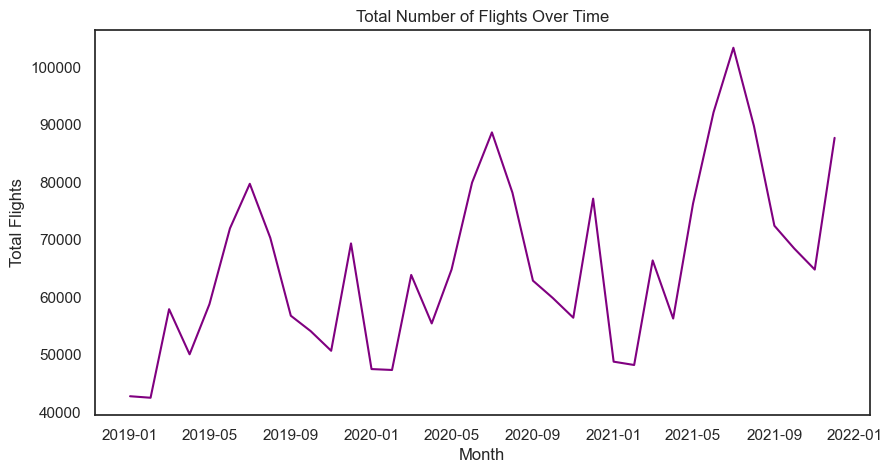

In [224]:
# Line chart - Total flights over time
flights_per_month = flights.groupby('YearMonthDate')['NumFlights'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(flights_per_month['YearMonthDate'], flights_per_month['NumFlights'], color='purple')
plt.title('Total Number of Flights Over Time')
plt.xlabel('Month')
plt.ylabel('Total Flights')
plt.show()


The line chart shows fluctuations in the total number of flights over time.
Despite month-to-month variability, there is a general upward trend with periodic peaks that may reflect seasonality or promotional periods.
The data also reveals temporary declines, possibly associated with external events or lower travel seasons.

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2424916187.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flights.groupby('Month')['NumFlights'].sum().reset_index(),


Text(0.5, 1.0, 'Total of flights per month')

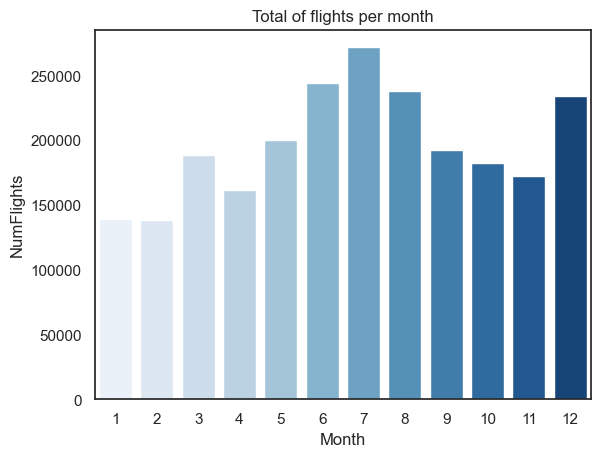

In [225]:
sns.barplot(data=flights.groupby('Month')['NumFlights'].sum().reset_index(),
            x='Month', y='NumFlights', palette='Blues')
plt.title('Total of flights per month')


This bar chart shows the total number of flights per month.
The number of flights increases steadily from the beginning of the year, peaking around July, and then slightly drops afterward.
This pattern suggests strong seasonality, likely related to summer holidays and end-of-year travel.

<a class="anchor" id="3rd-bullet">

### 2.4.4 Behavioral Insights
</a>

Text(0.5, 1.0, 'Distance vs Number of flights with companions')

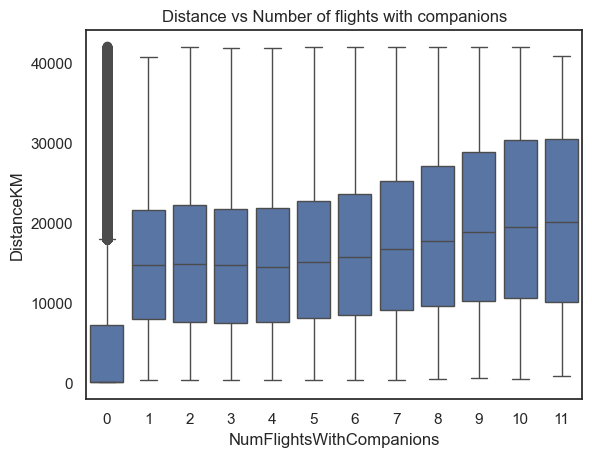

In [226]:
sns.boxplot(data=flights, x='NumFlightsWithCompanions', y='DistanceKM')
plt.title('Distance vs Number of flights with companions')

This boxplot examines how flight distance varies with the number of flights taken with companions.
As the number of companion flights increases, the median distance also tends to rise.
This could indicate that travelers who fly more frequently with others often take longer trips, such as vacations or group travel.

Text(0.5, 1.0, 'Monthly Evolution of Key Metrics')

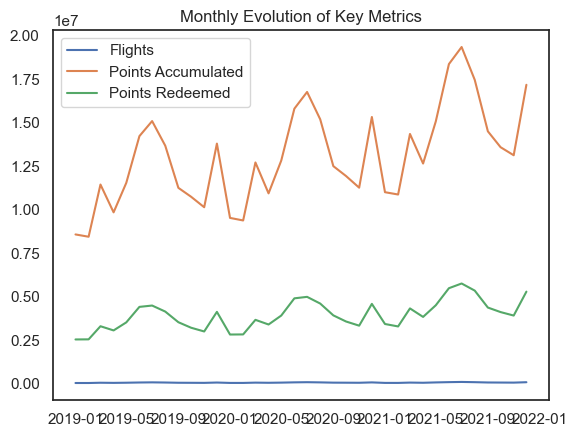

In [227]:
metrics_per_month = flights.groupby('YearMonthDate')[['NumFlights', 'PointsAccumulated', 'PointsRedeemed']].sum().reset_index()

plt.plot(metrics_per_month['YearMonthDate'], metrics_per_month['NumFlights'], label='Flights')
plt.plot(metrics_per_month['YearMonthDate'], metrics_per_month['PointsAccumulated'], label='Points Accumulated')
plt.plot(metrics_per_month['YearMonthDate'], metrics_per_month['PointsRedeemed'], label='Points Redeemed')
plt.legend()
plt.title('Monthly Evolution of Key Metrics')

This line chart compares the monthly evolution of the three main metrics — total flights, points accumulated, and points redeemed.
Points accumulated and redeemed show clear cyclical patterns over time, while flights remain relatively stable.
The similar peaks in all lines suggest that flying activity and loyalty program engagement move together.

<a class="anchor" id="3rd-bullet">

### 2.5. Feature Engineering
</a>

In [228]:
# create new variables

**ActiveMonth**  
- Many customers have months with zero flights and zero points.

- This binary flag indicates whether a customer was active during that month, making it easier to analyze loyalty frequency and churn.

In [229]:
#If the customer flew in a determined month
flights['ActiveMonth'] = (flights['NumFlights'] > 0).astype(int)

**RedeemRate**  
- The histogram showed that most customers never redeem points (PointsRedeemed = 0).
- This variable quantifies how much of the accumulated points are actually used, helping to distinguish engaged from inactive customers.

In [230]:
flights['RedeemRate'] = flights['PointsRedeemed'] / flights['PointsAccumulated'].replace(0, np.nan)

**AvgDistancePerFlight**  
- The scatterplot between NumFlights and DistanceKM showed some customers take many short flights, while others take few long flights.
- Calculating the average distance per flight helps identify travel patterns.
- It also reduces redundancy between two strongly correlated variables (correlation ≈ 0.62).

In [231]:
flights['AvgDistancePerFlight'] = flights['DistanceKM'] / flights['NumFlights'].replace(0, np.nan)

**CompanionshipRatio**  
- The boxplot showed that customers who travel more frequently with companions tend to take longer trips.
- This ratio measures the percentage of flights taken with others, which may indicate family or leisure travel.
- It can help segment customers into social vs solo travelers.

In [232]:
flights['CompanionshipRatio'] = flights['NumFlightsWithCompanions'] / flights['NumFlights'].replace(0, np.nan)

**ActivityLevel**  
- The heatmap and time-series plots revealed strong correlations between flights, points accumulated, and points redeemed.

- These can be combined into one overall activity index, representing a customer’s engagement level in the loyalty program.

In [233]:
scaler = MinMaxScaler()
flights[['NumFlights_scaled','PointsAccumulated_scaled','PointsRedeemed_scaled']] = scaler.fit_transform(
    flights[['NumFlights','PointsAccumulated','PointsRedeemed']]
)
flights['ActivityLevel'] = (flights['NumFlights_scaled'] + flights['PointsAccumulated_scaled'] + flights['PointsRedeemed_scaled']) / 3


**MonthSeason**  
- The bar plot of flights per month showed strong seasonality, with peaks in July and December.

- Grouping months into seasons (Winter, Spring, Summer, Autumn) captures this cyclical pattern and can be useful in time-based models.

In [234]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

flights['MonthSeason'] = flights['Month'].apply(get_season)

In [235]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,ActiveMonth,RedeemRate,AvgDistancePerFlight,CompanionshipRatio,NumFlights_scaled,PointsAccumulated_scaled,PointsRedeemed_scaled,ActivityLevel,MonthSeason
0,413052,2021,12,2021-12-01,2,2,9384.0,938.0,0.0,0.0,1,0.000000,4692.000000,1.00,0.095238,0.223121,0.000000,0.106120,Winter
1,464105,2021,12,2021-12-01,0,0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Winter
2,681785,2021,12,2021-12-01,10,3,14745.0,1474.0,0.0,0.0,1,0.000000,1474.500000,0.30,0.476190,0.350618,0.000000,0.275603,Winter
3,185013,2021,12,2021-12-01,16,4,26311.0,2631.0,3213.0,32.0,1,1.221209,1644.437500,0.25,0.761905,0.625833,0.428629,0.605455,Winter
4,216596,2021,12,2021-12-01,9,0,19275.0,1927.0,0.0,0.0,1,0.000000,2141.666667,0.00,0.428571,0.458373,0.000000,0.295648,Winter


In [236]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596676 entries, 0 to 596675
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Loyalty#                  596676 non-null  int64         
 1   Year                      596676 non-null  int64         
 2   Month                     596676 non-null  int64         
 3   YearMonthDate             596676 non-null  datetime64[ns]
 4   NumFlights                596676 non-null  int64         
 5   NumFlightsWithCompanions  596676 non-null  int64         
 6   DistanceKM                596676 non-null  float64       
 7   PointsAccumulated         596676 non-null  float64       
 8   PointsRedeemed            596676 non-null  float64       
 9   DollarCostPointsRedeemed  596676 non-null  float64       
 10  ActiveMonth               596676 non-null  int64         
 11  RedeemRate                301621 non-null  float64       
 12  Av

In [237]:
flights.isna().sum()
flights.isna().mean() * 100

Loyalty#                     0.000000
Year                         0.000000
Month                        0.000000
YearMonthDate                0.000000
NumFlights                   0.000000
NumFlightsWithCompanions     0.000000
DistanceKM                   0.000000
PointsAccumulated            0.000000
PointsRedeemed               0.000000
DollarCostPointsRedeemed     0.000000
ActiveMonth                  0.000000
RedeemRate                  49.449785
AvgDistancePerFlight        49.449785
CompanionshipRatio          49.449785
NumFlights_scaled            0.000000
PointsAccumulated_scaled     0.000000
PointsRedeemed_scaled        0.000000
ActivityLevel                0.000000
MonthSeason                  0.000000
dtype: float64

<a class="anchor" id="3rd-bullet">

### 2.5.1. Distribution Analysis of Engineered Features
    
</a>

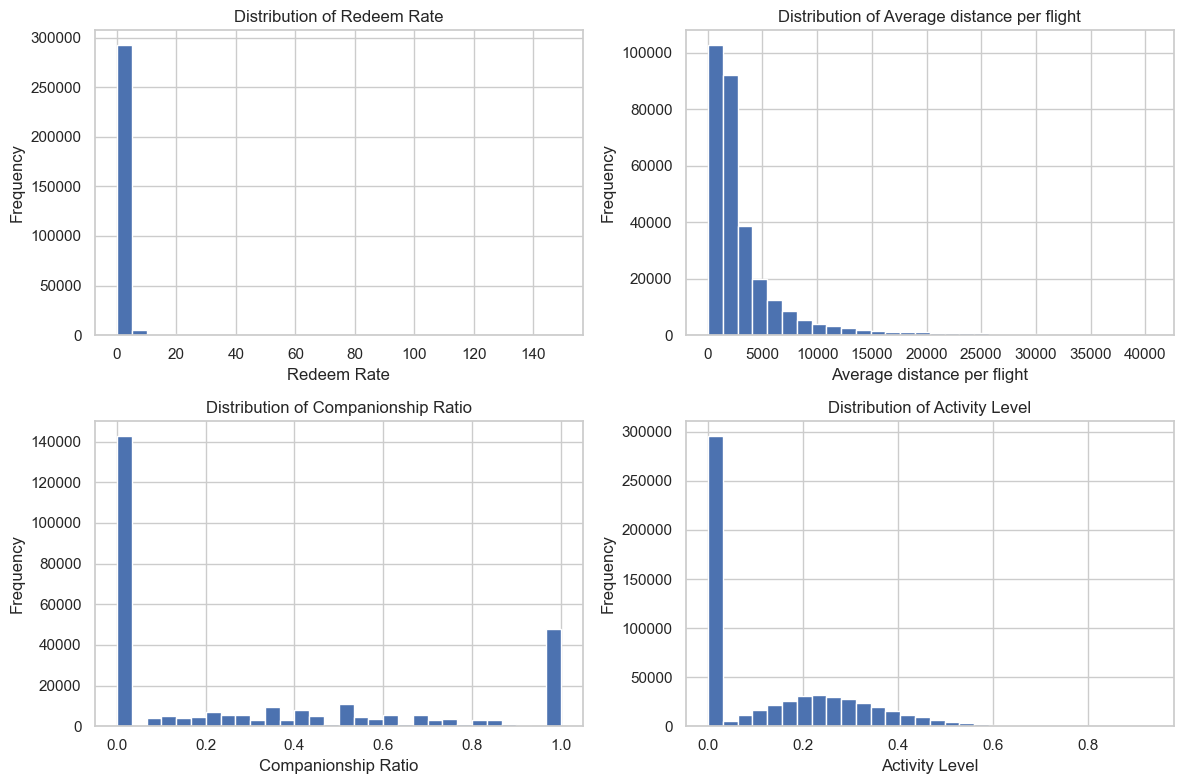

In [238]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(flights['RedeemRate'], bins=30)
axes[0, 0].set_title('Distribution of Redeem Rate')
axes[0, 0].set_xlabel('Redeem Rate')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(flights['AvgDistancePerFlight'], bins=30)
axes[0, 1].set_title('Distribution of Average distance per flight')
axes[0, 1].set_xlabel('Average distance per flight')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(flights['CompanionshipRatio'], bins=30)
axes[1, 0].set_title('Distribution of Companionship Ratio')
axes[1, 0].set_xlabel('Companionship Ratio')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(flights['ActivityLevel'], bins=30)
axes[1, 1].set_title('Distribution of Activity Level')
axes[1, 1].set_xlabel('Activity Level')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


The histograms show highly skewed distributions across all engineered variables. The Redeem Rate and Companionship Ratio are mostly concentrated near zero, meaning that most customers rarely redeem points or travel with companions. The Average Distance per Flight also has a strong right skew, indicating that most flights cover short distances, with few long-haul outliers. The Activity Level presents a similar pattern, suggesting that a small group of customers shows consistently higher engagement.

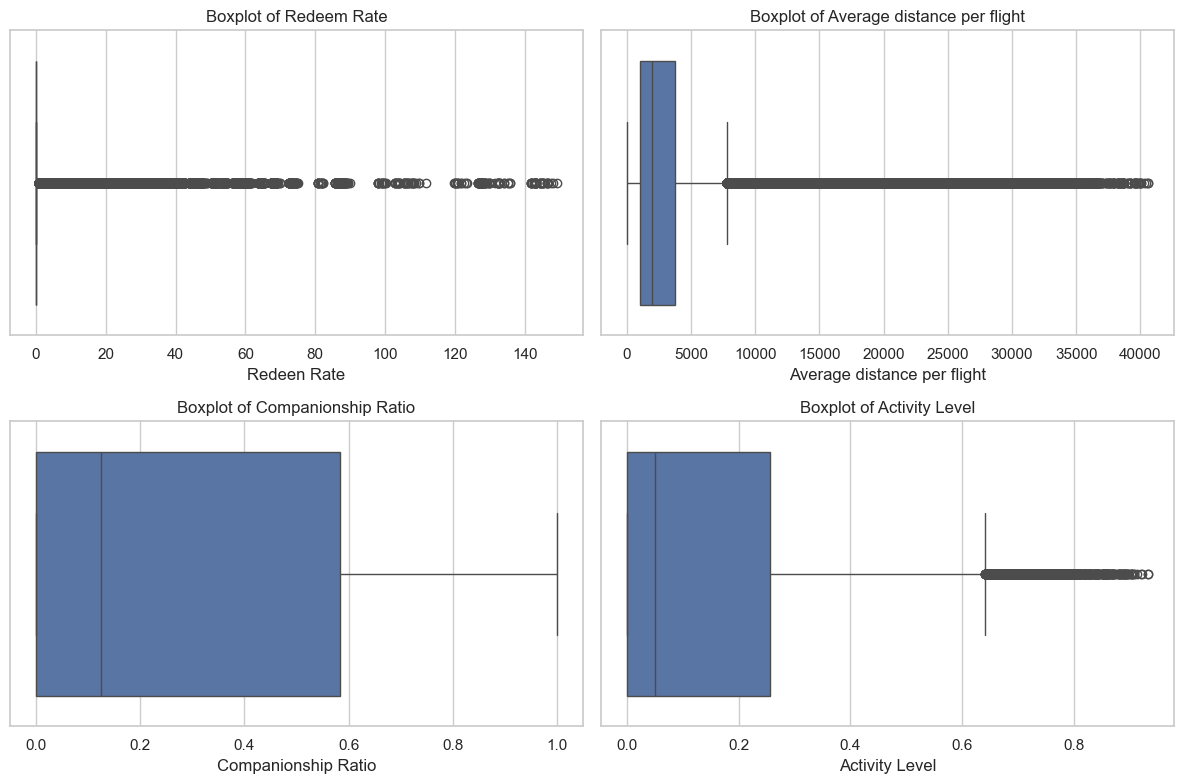

In [239]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x=flights['RedeemRate'], ax=axes[0, 0])
axes[0, 0].set_title('Boxplot of Redeem Rate')
axes[0, 0].set_xlabel('Redeen Rate')

sns.boxplot(x=flights['AvgDistancePerFlight'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Average distance per flight')
axes[0, 1].set_xlabel('Average distance per flight')

sns.boxplot(x=flights['CompanionshipRatio'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of Companionship Ratio')
axes[1, 0].set_xlabel('Companionship Ratio')

sns.boxplot(x=flights['ActivityLevel'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Activity Level')
axes[1, 1].set_xlabel('Activity Level')


plt.tight_layout()
plt.show()


The boxplots confirm the presence of significant outliers, particularly in Redeem Rate and Average Distance per Flight. The interquartile range is narrow, meaning that most customers fall within a limited behavioral pattern. The wide spread of outliers indicates the existence of a small subset of highly active or exceptional customers who accumulate or redeem many points or travel much farther than the average.

<a class="anchor" id="3rd-bullet">

### 2.5.2. Correlation between Original and Engineered Variables
    
</a>

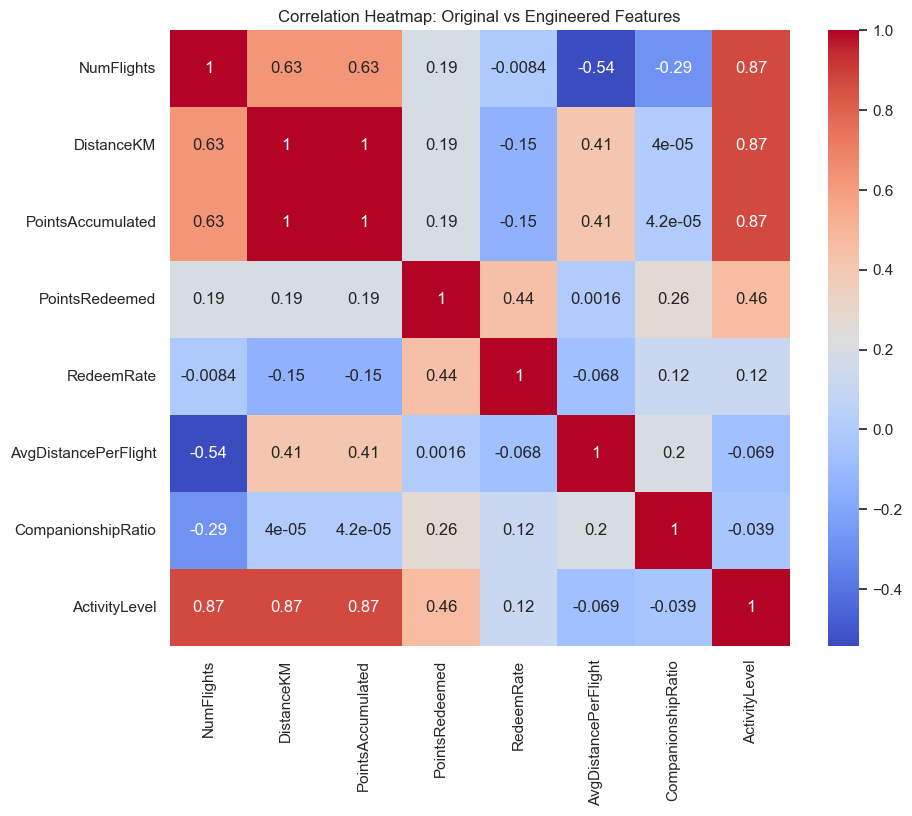

In [240]:
selected = ['NumFlights', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
            'RedeemRate', 'AvgDistancePerFlight', 'CompanionshipRatio', 'ActivityLevel']

plt.figure(figsize=(10, 8))
sns.heatmap(flights[selected].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Original vs Engineered Features')
plt.show()

The heatmap highlights strong correlations between NumFlights, DistanceKM, PointsAccumulated, and the new feature ActivityLevel, confirming that this derived variable effectively summarizes customer engagement. RedeemRate has weak correlations with most other features, which is expected since point redemption behavior is relatively independent of flight frequency or distance. AvgDistancePerFlight shows a negative relationship with NumFlights, suggesting that frequent travelers tend to take shorter trips.

<a class="anchor" id="3rd-bullet">

### 2.5.3. Relationships between Flights and Points Variables
    
</a>

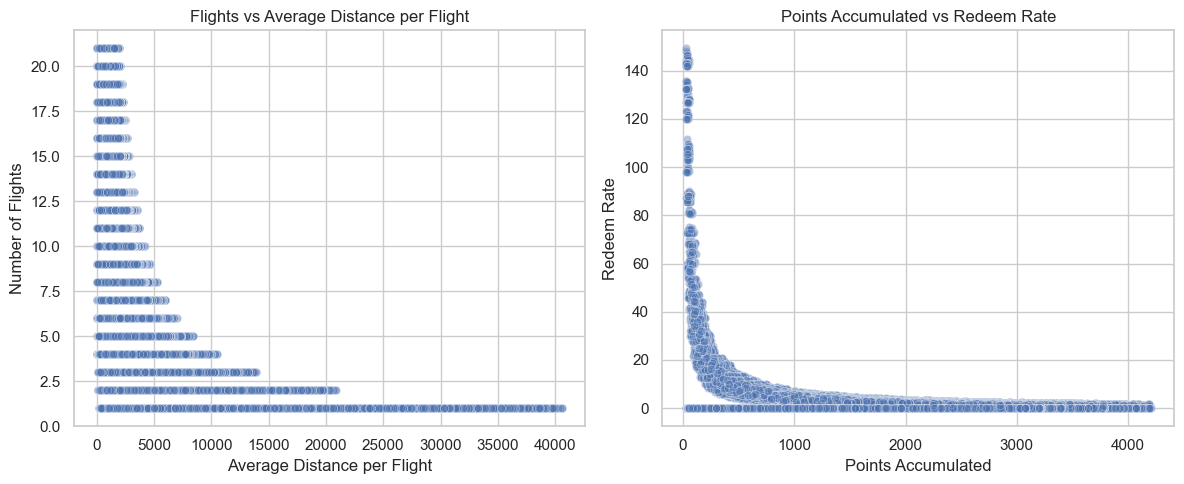

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter 1: AvgDistancePerFlight vs NumFlights
sns.scatterplot(data=flights, x='AvgDistancePerFlight', y='NumFlights',
                alpha=0.4, ax=axes[0])
axes[0].set_title('Flights vs Average Distance per Flight')
axes[0].set_xlabel('Average Distance per Flight')
axes[0].set_ylabel('Number of Flights')

# Scatter 2: PointsAccumulated vs RedeemRate
sns.scatterplot(data=flights, x='PointsAccumulated', y='RedeemRate',
                alpha=0.4, ax=axes[1])
axes[1].set_title('Points Accumulated vs Redeem Rate')
axes[1].set_xlabel('Points Accumulated')
axes[1].set_ylabel('Redeem Rate')

plt.tight_layout()
plt.show()

The first scatterplot shows an inverse relationship between AvgDistancePerFlight and NumFlights, supporting the idea that customers who fly frequently tend to take shorter routes. The second scatterplot reveals a decreasing trend between PointsAccumulated and RedeemRate — as customers accumulate more points, the proportion of those points being redeemed declines. This may indicate point-saving behavior or delayed redemption among loyal customers.

<a class="anchor" id="3rd-bullet">

### 2.5.4. Temporal and Seasonal Behavior
    
</a>



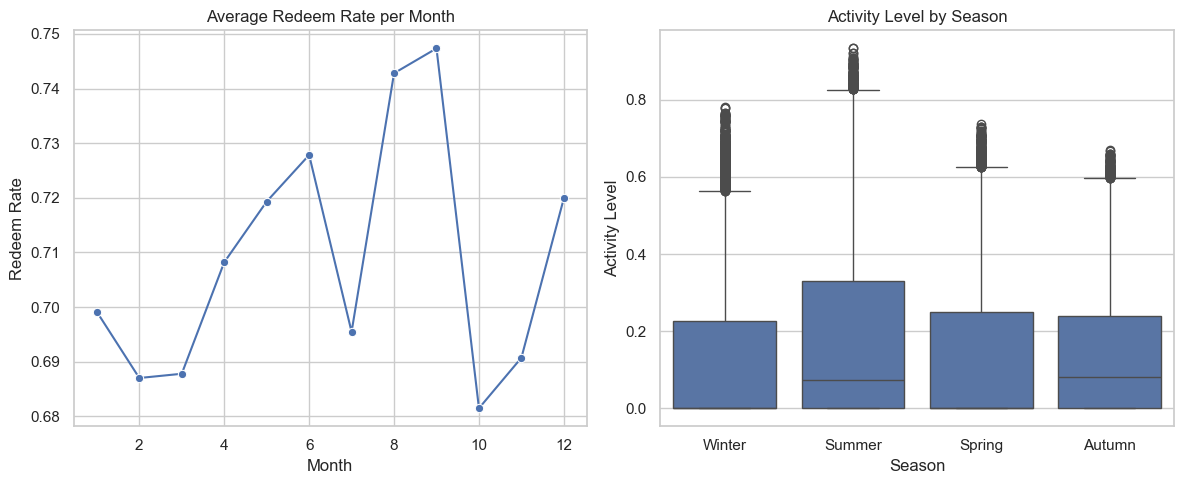

In [242]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Lineplot – Average Redeem Rate per Month
sns.lineplot(
    data=flights.groupby('Month')['RedeemRate'].mean().reset_index(),
    x='Month', y='RedeemRate', marker='o', ax=axes[0]
)
axes[0].set_title('Average Redeem Rate per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Redeem Rate')

# Boxplot – Activity Level by Season
sns.boxplot(
    data=flights, x='MonthSeason', y='ActivityLevel', ax=axes[1]
)
axes[1].set_title('Activity Level by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Activity Level')

plt.tight_layout()
plt.show()


The Average Redeem Rate per Month shows small monthly fluctuations, with slight peaks during mid-year months, possibly associated with holiday travel or promotional campaigns. The Activity Level by Season boxplot indicates higher activity levels in the summer, consistent with increased flight frequency and engagement during vacation periods.


<a class="anchor" id="3rd-bullet">

### 2.5.5. Interactions among Engineered Features
    
</a>


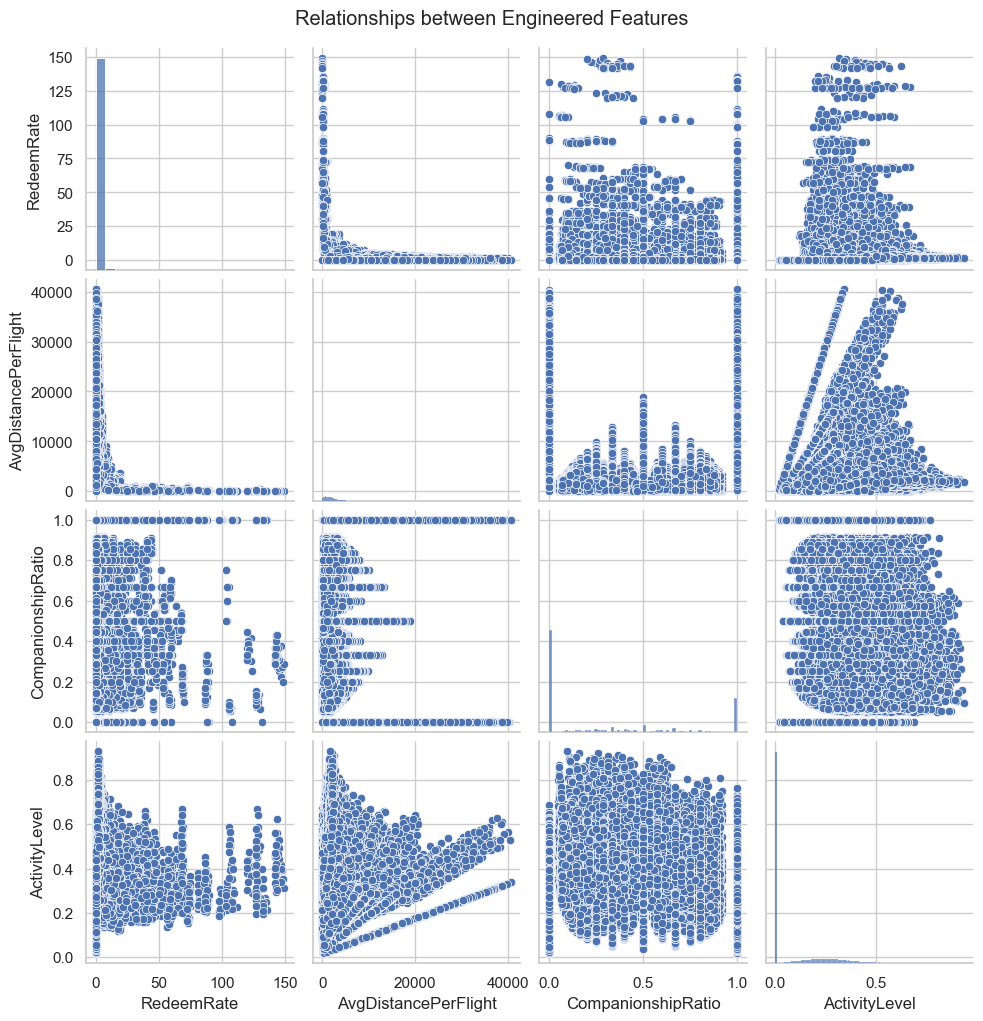

In [243]:
sns.pairplot(flights[['RedeemRate', 'AvgDistancePerFlight', 'CompanionshipRatio', 'ActivityLevel']])
plt.suptitle('Relationships between Engineered Features', y=1.02)
plt.show()

The pairplot allows a broader view of how the engineered features relate to each other. The plots confirm that most variables are weakly correlated, meaning they capture distinct aspects of customer behavior. A slight inverse trend appears between AvgDistancePerFlight and ActivityLevel, showing that customers who fly shorter distances tend to be more active overall. The concentration of data points near zero in multiple plots reflects the predominance of low-engagement users in the dataset.

<a class="anchor" id="3rd-bullet">

### 2.5.6. Treating Missing Values
</a>


Missing values in *RedeemRate*, *AvgDistancePerFlight*, and *CompanionshipRatio* occur logically for customers with no recorded flights or accumulated points in a given month.
Instead of treating these as errors, they were replaced with zeros, reflecting the absence of activity rather than missing information.
This approach ensures consistency with the variable ActiveMonth, which already identifies periods of inactivity.

In [244]:
flights[['RedeemRate', 'AvgDistancePerFlight', 'CompanionshipRatio']] = (
    flights[['RedeemRate', 'AvgDistancePerFlight', 'CompanionshipRatio']].fillna(0)
)


In [245]:
flights.isna().sum()
flights.isna().mean() * 100

Loyalty#                    0.0
Year                        0.0
Month                       0.0
YearMonthDate               0.0
NumFlights                  0.0
NumFlightsWithCompanions    0.0
DistanceKM                  0.0
PointsAccumulated           0.0
PointsRedeemed              0.0
DollarCostPointsRedeemed    0.0
ActiveMonth                 0.0
RedeemRate                  0.0
AvgDistancePerFlight        0.0
CompanionshipRatio          0.0
NumFlights_scaled           0.0
PointsAccumulated_scaled    0.0
PointsRedeemed_scaled       0.0
ActivityLevel               0.0
MonthSeason                 0.0
dtype: float64

<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 3. Flights Dataset (After Aggregation)
    

    
</div>

<a class="anchor" id="3rd-bullet">

### 3.1. Creating The New Dataset
    
</a>

In [246]:
# create dataset equal to the flights dataset but instead of having multiple rows for each customer,
# we can only have one row for each customer

# i think we need to aggregate the rows in the flights dataset that refer to the same customer

# but we have to do this whitout removing the Month, Year, Date variables

In [247]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,ActiveMonth,RedeemRate,AvgDistancePerFlight,CompanionshipRatio,NumFlights_scaled,PointsAccumulated_scaled,PointsRedeemed_scaled,ActivityLevel,MonthSeason
0,413052,2021,12,2021-12-01,2,2,9384.0,938.0,0.0,0.0,1,0.000000,4692.000000,1.00,0.095238,0.223121,0.000000,0.106120,Winter
1,464105,2021,12,2021-12-01,0,0,0.0,0.0,0.0,0.0,0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,Winter
2,681785,2021,12,2021-12-01,10,3,14745.0,1474.0,0.0,0.0,1,0.000000,1474.500000,0.30,0.476190,0.350618,0.000000,0.275603,Winter
3,185013,2021,12,2021-12-01,16,4,26311.0,2631.0,3213.0,32.0,1,1.221209,1644.437500,0.25,0.761905,0.625833,0.428629,0.605455,Winter
4,216596,2021,12,2021-12-01,9,0,19275.0,1927.0,0.0,0.0,1,0.000000,2141.666667,0.00,0.428571,0.458373,0.000000,0.295648,Winter


In [248]:
# Before aggregating, we remove all '_scaled' columns from the flights dataset
# because scaling distorts the original numerical values.
# Aggregation should be performed on the raw data to ensure meaningful totals and averages.
flights = flights.drop(columns=[col for col in flights.columns if '_scaled' in col])

In [249]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,ActiveMonth,RedeemRate,AvgDistancePerFlight,CompanionshipRatio,ActivityLevel,MonthSeason
0,413052,2021,12,2021-12-01,2,2,9384.0,938.0,0.0,0.0,1,0.000000,4692.000000,1.00,0.106120,Winter
1,464105,2021,12,2021-12-01,0,0,0.0,0.0,0.0,0.0,0,0.000000,0.000000,0.00,0.000000,Winter
2,681785,2021,12,2021-12-01,10,3,14745.0,1474.0,0.0,0.0,1,0.000000,1474.500000,0.30,0.275603,Winter
3,185013,2021,12,2021-12-01,16,4,26311.0,2631.0,3213.0,32.0,1,1.221209,1644.437500,0.25,0.605455,Winter
4,216596,2021,12,2021-12-01,9,0,19275.0,1927.0,0.0,0.0,1,0.000000,2141.666667,0.00,0.295648,Winter


In [250]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596676 entries, 0 to 596675
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Loyalty#                  596676 non-null  int64         
 1   Year                      596676 non-null  int64         
 2   Month                     596676 non-null  int64         
 3   YearMonthDate             596676 non-null  datetime64[ns]
 4   NumFlights                596676 non-null  int64         
 5   NumFlightsWithCompanions  596676 non-null  int64         
 6   DistanceKM                596676 non-null  float64       
 7   PointsAccumulated         596676 non-null  float64       
 8   PointsRedeemed            596676 non-null  float64       
 9   DollarCostPointsRedeemed  596676 non-null  float64       
 10  ActiveMonth               596676 non-null  int64         
 11  RedeemRate                596676 non-null  float64       
 12  Av

**Variables Agregation**  
This aggregation step was performed to transform the dataset from a monthly flight-level structure into a customer-level summary, with one row per loyalty member. By grouping the data by customer and calculating totals (such as total flights, distance flown, and points accumulated) as well as averages (such as average distance per flight and average activity level), we obtain a compact and comprehensive view of each customer’s overall travel behavior. This allows for easier comparison between customers and supports further analysis of loyalty patterns, engagement, and flight activity intensity.

In [251]:
# Aggregate flights dataset to have one row per customer (Loyalty#)
# We calculate key totals, averages, and activity indicators

flights_agg = flights.groupby('Loyalty#').agg({
    'NumFlights': ['sum', 'mean'],
    'NumFlightsWithCompanions': ['sum', 'mean'],
    'DistanceKM': ['sum', 'mean'],
    'PointsAccumulated': ['sum', 'mean'],
    'PointsRedeemed': ['sum', 'mean'],
    'DollarCostPointsRedeemed': ['sum', 'mean'],
    'RedeemRate': 'mean',
    'AvgDistancePerFlight': 'mean',
    'CompanionshipRatio': 'mean',
    'ActivityLevel': 'mean',
    'ActiveMonth': 'sum',
}).reset_index()

# Simplify column names
flights_agg.columns = ['Loyalty#',
                       'TotalFlights', 'AvgFlightsPerMonth',
                       'TotalFlightsWithCompanions', 'AvgFlightsWithCompanions',
                       'TotalDistanceKM', 'AvgDistanceKM',
                       'TotalPointsAccumulated', 'AvgPointsAccumulated',
                       'TotalPointsRedeemed', 'AvgPointsRedeemed',
                       'TotalDollarCostRedeemed', 'AvgDollarCostRedeemed',
                       'AvgRedeemRate', 'AvgDistancePerFlight',
                       'AvgCompanionshipRatio', 'AvgActivityLevel',
                       'TotalActiveMonths']

# Quick check
flights_agg.head()


,Loyalty#,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,AvgActivityLevel,TotalActiveMonths
0,100018,231,6.416667,50,1.388889,530230.0,14728.611111,53014.30,1472.619444,20562.8,571.188889,201.9,5.608333,0.282897,2388.168953,0.192623,0.244015,31
1,100102,248,6.888889,59,1.638889,339114.6,9419.850000,33903.96,941.776667,18760.6,521.127778,186.2,5.172222,0.627745,1074.373827,0.198539,0.207194,25
2,100140,217,6.027778,54,1.500000,432030.8,12000.855556,43192.58,1199.793889,4896.0,136.000000,48.0,1.333333,0.080616,2480.593814,0.276175,0.196858,28
3,100214,112,3.111111,20,0.555556,364601.7,10127.825000,36453.77,1012.604722,12908.6,358.572222,127.3,3.536111,1.315612,4431.372537,0.210317,0.145617,21
4,100272,187,5.194444,53,1.472222,429630.5,11934.180556,42953.25,1193.145833,10891.4,302.538889,107.0,2.972222,0.155939,4527.014935,0.248248,0.190509,25


**MonthsActive_PerYear**  
This step was implemented to replace the overall activity variable (TotalActiveMonths) with a more detailed year-by-year breakdown. By grouping the data by customer and year, we calculated the number of months each customer was active in 2019, 2020, and 2021. This approach provides a clearer view of the customer’s flight consistency and engagement across different years, allowing for more accurate temporal analysis of flying behavior.

In [252]:
#split the column TotalActiveMonths per year
flights_agg = flights_agg.drop(columns=['TotalActiveMonths'])

#created new variables that return the nº of months a customer flies in a determined year
activity = flights.groupby(['Loyalty#','Year'])['ActiveMonth'].sum().unstack().fillna(0)
activity.columns = ['monthsActive_2019','monthsActive_2020','monthsActive_2021']
flights_agg = flights_agg.merge(activity, on='Loyalty#', how='left')

flights_agg[['Loyalty#', 'monthsActive_2019', 'monthsActive_2020', 'monthsActive_2021']].head()

,Loyalty#,monthsActive_2019,monthsActive_2020,monthsActive_2021
0,100018,11,11,9
1,100102,8,8,9
2,100140,10,10,8
3,100214,7,7,7
4,100272,8,8,9


**Flights_PerSeason**  
This step was carried out to analyze customer flight behavior by season. By grouping the dataset by customer and season, we calculated the total number of flights each customer took during autumn, spring, summer, and winter. The resulting seasonal flight variables (*Flights_Autumn*, *Flights_Spring*, *Flights_Summer*, and *Flights_Winter*) allow for a clearer understanding of seasonal travel patterns and preferences, enabling comparisons of activity intensity across different times of the year.

In [253]:
flights_season = flights.groupby(['Loyalty#', 'MonthSeason'])['NumFlights'].sum().unstack(fill_value=0).reset_index()

# Rename columns to the desired format
flights_season = flights_season.rename(columns={
    'Autumn': 'Flights_Autumn',
    'Spring': 'Flights_Spring',
    'Summer': 'Flights_Summer',
    'Winter': 'Flights_Winter'
})

flights_agg = flights_agg.merge(flights_season, on='Loyalty#', how='left')

#check
flights_agg[['Loyalty#', 'Flights_Autumn', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter']].head()

,Loyalty#,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter
0,100018,84,47,55,45
1,100102,77,62,49,60
2,100140,62,58,48,49
3,100214,48,3,18,43
4,100272,22,64,70,31


**Favorite Month and Season**  
This part of the analysis identifies each customer’s preferred period to fly. First, the total number of flights per season and per month was calculated, allowing us to determine for each customer their PeakSeason (the season with the highest flight activity) and PeakMonth (the month with the highest number of flights). These variables provide insight into individual travel preferences and seasonality patterns. Finally, the variable MonthMatchesSeason was created to verify whether the customer’s favorite month to fly belongs to their favorite season, enabling the identification of consistent or irregular travel behaviors across time.

In [254]:
season_totals = (
    flights.groupby(['Loyalty#', 'MonthSeason'], as_index=False)['NumFlights']
           .sum()
)

peak_season = (
    season_totals.loc[season_totals.groupby('Loyalty#')['NumFlights'].idxmax(),
                      ['Loyalty#', 'MonthSeason']]
    .rename(columns={'MonthSeason': 'PeakSeason'})
)

flights['Month'] = flights['Month'].astype(int)

month_totals = (
    flights.groupby(['Loyalty#', 'Month'], as_index=False)['NumFlights']
           .sum()
)

peak_month = (
    month_totals.loc[month_totals.groupby('Loyalty#')['NumFlights'].idxmax(),
                     ['Loyalty#', 'Month']]
    .rename(columns={'Month': 'PeakMonth'})
)


flights_agg = (
    flights_agg.merge(peak_season, on='Loyalty#', how='left')
               .merge(peak_month, on='Loyalty#', how='left')
)


#check if the favorite month to fly corresponds to the favorite season to fly
def match_season(row):
    if row['PeakSeason'] == 'Winter' and row['PeakMonth'] in [12, 1, 2]:
        return 1
    elif row['PeakSeason'] == 'Spring' and row['PeakMonth'] in [3, 4, 5]:
        return 1
    elif row['PeakSeason'] == 'Summer' and row['PeakMonth'] in [6, 7, 8]:
        return 1
    elif row['PeakSeason'] == 'Autumn' and row['PeakMonth'] in [9, 10, 11]:
        return 1
    else:
        return 0

flights_agg['MonthMatchesSeason'] = flights_agg.apply(match_season, axis=1)

flights_agg[['Loyalty#', 'PeakSeason', 'PeakMonth', 'MonthMatchesSeason']].head()

,Loyalty#,PeakSeason,PeakMonth,MonthMatchesSeason
0,100018,Autumn,11,1
1,100102,Autumn,12,0
2,100140,Autumn,9,1
3,100214,Autumn,12,0
4,100272,Summer,6,1


**Flight Activity per Year**  
This step was performed to measure each customer’s flight activity across different years. By aggregating the total number of flights per customer and per year, the code identifies whether the customer flew in 2019, 2020, or 2021. Binary variables were then created for each year, taking the value 1 if the customer flew and 0 otherwise. Additionally, the variable YearsActive was introduced to indicate the total number of years (from 0 to 3) in which the customer had flight activity. This provides a clear indicator of the customer’s temporal consistency and engagement with the airline over time.

In [255]:
#Determine if the customer flew in each year (2019, 2020, 2021)
#We check whether total flights in that year > 0

#Aggregate total flights per customer and year
year_flights = flights.groupby(['Loyalty#', 'Year'], as_index=False)['NumFlights'].sum()

#Pivot to create one column per year
year_flights_pivot = year_flights.pivot(index='Loyalty#', columns='Year', values='NumFlights').fillna(0).reset_index()

#Create binary columns for each year
year_flights_pivot['Flew_2019'] = (year_flights_pivot.get(2019, 0) > 0).astype(int)
year_flights_pivot['Flew_2020'] = (year_flights_pivot.get(2020, 0) > 0).astype(int)
year_flights_pivot['Flew_2021'] = (year_flights_pivot.get(2021, 0) > 0).astype(int)

#Count in how many years the customer flew
year_flights_pivot['YearsActive'] = (
    year_flights_pivot[['Flew_2019', 'Flew_2020', 'Flew_2021']].sum(axis=1)
)

#Keep only the relevant columns
year_flights_pivot = year_flights_pivot[['Loyalty#', 'Flew_2019', 'Flew_2020', 'Flew_2021', 'YearsActive']]

#Merge with the aggregated dataset
flights_agg = flights_agg.merge(year_flights_pivot, on='Loyalty#', how='left')

#Quick check
flights_agg[['Loyalty#', 'Flew_2019', 'Flew_2020', 'Flew_2021', 'YearsActive']].head()


,Loyalty#,Flew_2019,Flew_2020,Flew_2021,YearsActive
0,100018,1,1,1,3
1,100102,1,1,1,3
2,100140,1,1,1,3
3,100214,1,1,1,3
4,100272,1,1,1,3


<a class="anchor" id="3rd-bullet">

### 3.2. Exploratory Data Analysis
    
</a>

In [256]:
pd.set_option('display.max_columns', None)
flights_agg.head()

,Loyalty#,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,AvgActivityLevel,monthsActive_2019,monthsActive_2020,monthsActive_2021,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter,PeakSeason,PeakMonth,MonthMatchesSeason,Flew_2019,Flew_2020,Flew_2021,YearsActive
0,100018,231,6.416667,50,1.388889,530230.0,14728.611111,53014.30,1472.619444,20562.8,571.188889,201.9,5.608333,0.282897,2388.168953,0.192623,0.244015,11,11,9,84,47,55,45,Autumn,11,1,1,1,1,3
1,100102,248,6.888889,59,1.638889,339114.6,9419.850000,33903.96,941.776667,18760.6,521.127778,186.2,5.172222,0.627745,1074.373827,0.198539,0.207194,8,8,9,77,62,49,60,Autumn,12,0,1,1,1,3
2,100140,217,6.027778,54,1.500000,432030.8,12000.855556,43192.58,1199.793889,4896.0,136.000000,48.0,1.333333,0.080616,2480.593814,0.276175,0.196858,10,10,8,62,58,48,49,Autumn,9,1,1,1,1,3
3,100214,112,3.111111,20,0.555556,364601.7,10127.825000,36453.77,1012.604722,12908.6,358.572222,127.3,3.536111,1.315612,4431.372537,0.210317,0.145617,7,7,7,48,3,18,43,Autumn,12,0,1,1,1,3
4,100272,187,5.194444,53,1.472222,429630.5,11934.180556,42953.25,1193.145833,10891.4,302.538889,107.0,2.972222,0.155939,4527.014935,0.248248,0.190509,8,8,9,22,64,70,31,Summer,6,1,1,1,1,3


In [257]:
flights_agg.shape

(16737, 31)

In [258]:
flights_agg.columns

Index(['Loyalty#', 'TotalFlights', 'AvgFlightsPerMonth',
       'TotalFlightsWithCompanions', 'AvgFlightsWithCompanions',
       'TotalDistanceKM', 'AvgDistanceKM', 'TotalPointsAccumulated',
       'AvgPointsAccumulated', 'TotalPointsRedeemed', 'AvgPointsRedeemed',
       'TotalDollarCostRedeemed', 'AvgDollarCostRedeemed', 'AvgRedeemRate',
       'AvgDistancePerFlight', 'AvgCompanionshipRatio', 'AvgActivityLevel',
       'monthsActive_2019', 'monthsActive_2020', 'monthsActive_2021',
       'Flights_Autumn', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter',
       'PeakSeason', 'PeakMonth', 'MonthMatchesSeason', 'Flew_2019',
       'Flew_2020', 'Flew_2021', 'YearsActive'],
      dtype='object')

In [259]:
flights_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Loyalty#                    16737 non-null  int64  
 1   TotalFlights                16737 non-null  int64  
 2   AvgFlightsPerMonth          16737 non-null  float64
 3   TotalFlightsWithCompanions  16737 non-null  int64  
 4   AvgFlightsWithCompanions    16737 non-null  float64
 5   TotalDistanceKM             16737 non-null  float64
 6   AvgDistanceKM               16737 non-null  float64
 7   TotalPointsAccumulated      16737 non-null  float64
 8   AvgPointsAccumulated        16737 non-null  float64
 9   TotalPointsRedeemed         16737 non-null  float64
 10  AvgPointsRedeemed           16737 non-null  float64
 11  TotalDollarCostRedeemed     16737 non-null  float64
 12  AvgDollarCostRedeemed       16737 non-null  float64
 13  AvgRedeemRate               167

In [260]:
flights_agg.dtypes

Loyalty#                        int64
TotalFlights                    int64
AvgFlightsPerMonth            float64
TotalFlightsWithCompanions      int64
AvgFlightsWithCompanions      float64
TotalDistanceKM               float64
AvgDistanceKM                 float64
TotalPointsAccumulated        float64
AvgPointsAccumulated          float64
TotalPointsRedeemed           float64
AvgPointsRedeemed             float64
TotalDollarCostRedeemed       float64
AvgDollarCostRedeemed         float64
AvgRedeemRate                 float64
AvgDistancePerFlight          float64
AvgCompanionshipRatio         float64
AvgActivityLevel              float64
monthsActive_2019               int64
monthsActive_2020               int64
monthsActive_2021               int64
Flights_Autumn                  int64
Flights_Spring                  int64
Flights_Summer                  int64
Flights_Winter                  int64
PeakSeason                     object
PeakMonth                       int64
MonthMatches

- Variable*PeakSeason* must be categorical
- Transform Binary Variables into int8 ?? what does this means??

In [261]:
id_col = ['Loyalty#']
categorical_cols = ['PeakSeason']
binary_cols = ['MonthMatchesSeason', 'Flew_2019', 'Flew_2020', 'Flew_2021']
numeric_cols = [col for col in flights_agg.columns if col not in id_col + categorical_cols + binary_cols]

In [262]:
flights_agg[numeric_cols].describe()

,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,AvgActivityLevel,monthsActive_2019,monthsActive_2020,monthsActive_2021,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter,PeakMonth,YearsActive
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000
mean,141.118898,3.969215,35.574954,1.000629,280863.078640,7900.083830,28080.772708,789.852717,8488.983384,238.645700,83.891289,2.358377,0.359294,1719.579668,0.159829,0.136243,5.711418,5.711418,6.598375,32.653761,32.857083,45.049770,30.558284,6.882297,2.410289
std,80.750753,2.274265,23.409824,0.659197,160990.232119,4534.640064,16096.329783,453.388105,8689.653565,244.152224,85.934126,2.414447,0.718908,1153.818554,0.105108,0.076780,3.787592,3.787592,3.303540,21.951086,24.703764,31.782945,21.636966,3.243081,1.033195
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,70.000000,1.944444,16.000000,0.444444,140337.000000,3921.719444,14030.000000,392.080278,0.000000,0.000000,0.000000,0.000000,0.000000,775.927466,0.069553,0.066970,1.000000,1.000000,5.000000,15.000000,11.000000,18.000000,12.000000,5.000000,2.000000
50%,163.000000,4.583333,37.000000,1.028571,323086.900000,9114.611111,32303.690000,911.255000,6469.500000,181.608333,64.000000,1.794444,0.130398,1758.434220,0.165734,0.159853,7.000000,7.000000,8.000000,33.000000,33.000000,46.000000,31.000000,7.000000,3.000000
75%,203.000000,5.722222,53.000000,1.472222,405483.800000,11415.220588,40540.700000,1141.251471,13516.000000,380.072727,133.400000,3.755556,0.393917,2484.269493,0.237103,0.195366,9.000000,9.000000,9.000000,49.000000,52.000000,69.000000,46.000000,9.000000,3.000000
max,349.000000,9.694444,124.000000,3.444444,712729.600000,19798.044444,71264.460000,1979.568333,57527.800000,1597.994444,572.000000,15.888889,10.782201,6777.859697,0.554235,0.319886,12.000000,12.000000,12.000000,107.000000,115.000000,147.000000,104.000000,12.000000,3.000000


The descriptive statistics summarize the main characteristics of the aggregated flight dataset.
Overall, customers took an average of 141 flights, traveling about 286,000 km in total, which corresponds to roughly 7,950 km per flight.
The number of flights per customer varies substantially (from 0 to 349), indicating different engagement levels with the loyalty program.

On average, customers earned around 28,600 points and redeemed approximately 8,500 points, showing that redemption behavior is less frequent than accumulation.
The average redeem rate (0.35) also supports this pattern, suggesting that many customers accumulate points without using them regularly.

Seasonally, activity is relatively balanced, with a slightly higher concentration of flights during the summer months (≈45 flights).
Most customers were active for 2 to 3 years between 2019 and 2021, with an average of around 6 active months per year.

These results confirm a heterogeneous customer base, with a mix of highly frequent flyers and less active participants, and reveal distinct temporal and seasonal travel patterns that may later influence the clustering analysis.

In [263]:
flights_agg['PeakSeason'].value_counts(normalize=True)
flights_agg[binary_cols].mean()

MonthMatchesSeason    0.645396
Flew_2019             0.766744
Flew_2020             0.766744
Flew_2021             0.876800
dtype: float64

The categorical and binary variables provide additional insights into customers’ flying behavior.
Approximately 65% of customers have their favorite month of travel matching their favorite season, indicating consistent seasonal flying preferences.
Regarding yearly activity, around 77% of customers flew in both 2019 and 2020, and nearly 88% remained active in 2021, suggesting strong program engagement and customer retention over time.
These proportions confirm that most loyalty members are recurrent travelers with stable travel patterns across the analyzed years.

<a class="anchor" id="3rd-bullet">

### 3.2.1. Checking For Missing Values
    
</a>

In [264]:
flights_agg.isna().sum()

Loyalty#                      0
TotalFlights                  0
AvgFlightsPerMonth            0
TotalFlightsWithCompanions    0
AvgFlightsWithCompanions      0
TotalDistanceKM               0
AvgDistanceKM                 0
TotalPointsAccumulated        0
AvgPointsAccumulated          0
TotalPointsRedeemed           0
AvgPointsRedeemed             0
TotalDollarCostRedeemed       0
AvgDollarCostRedeemed         0
AvgRedeemRate                 0
AvgDistancePerFlight          0
AvgCompanionshipRatio         0
AvgActivityLevel              0
monthsActive_2019             0
monthsActive_2020             0
monthsActive_2021             0
Flights_Autumn                0
Flights_Spring                0
Flights_Summer                0
Flights_Winter                0
PeakSeason                    0
PeakMonth                     0
MonthMatchesSeason            0
Flew_2019                     0
Flew_2020                     0
Flew_2021                     0
YearsActive                   0
dtype: i

- There is no missing values

<a class="anchor" id="3rd-bullet">

### 3.2.2. Checking For Duplicated Values
    
</a>

In [265]:
flights_agg.duplicated().sum()

np.int64(0)

In [266]:
flights_agg['Loyalty#'].duplicated().sum()

np.int64(0)

<a class="anchor" id="3rd-bullet">

### 3.3. Initial Data Preparation
    
</a>

In [267]:
# Deleting variables that aren't relevant (probably won't be necessary), converting types that might  
# be wrong, etc

In [268]:
flights_agg['PeakSeason'] = flights_agg['PeakSeason'].astype('category')
flights_agg[binary_cols] = flights_agg[binary_cols].astype('int8')

flights_agg.dtypes

Loyalty#                         int64
TotalFlights                     int64
AvgFlightsPerMonth             float64
TotalFlightsWithCompanions       int64
AvgFlightsWithCompanions       float64
TotalDistanceKM                float64
AvgDistanceKM                  float64
TotalPointsAccumulated         float64
AvgPointsAccumulated           float64
TotalPointsRedeemed            float64
AvgPointsRedeemed              float64
TotalDollarCostRedeemed        float64
AvgDollarCostRedeemed          float64
AvgRedeemRate                  float64
AvgDistancePerFlight           float64
AvgCompanionshipRatio          float64
AvgActivityLevel               float64
monthsActive_2019                int64
monthsActive_2020                int64
monthsActive_2021                int64
Flights_Autumn                   int64
Flights_Spring                   int64
Flights_Summer                   int64
Flights_Winter                   int64
PeakSeason                    category
PeakMonth                

### Identify numeric / categorical / binary columns

In [269]:
# Identify variable types more accurately

num_cols = [c for c in flights_agg.columns 
            if flights_agg[c].dtype in ['float64', 'int64'] 
            and flights_agg[c].nunique() > 5]   # exclude binary-like columns

binary_cols = [c for c in flights_agg.columns 
               if flights_agg[c].nunique() == 2]  # only 0/1 type columns

cat_cols = [c for c in flights_agg.columns 
            if flights_agg[c].dtype == 'object' or str(flights_agg[c].dtype) == 'category']

print("Numeric columns:", num_cols)
print("Binary columns:", binary_cols)
print("Categorical columns:", cat_cols)



Numeric columns: ['Loyalty#', 'TotalFlights', 'AvgFlightsPerMonth', 'TotalFlightsWithCompanions', 'AvgFlightsWithCompanions', 'TotalDistanceKM', 'AvgDistanceKM', 'TotalPointsAccumulated', 'AvgPointsAccumulated', 'TotalPointsRedeemed', 'AvgPointsRedeemed', 'TotalDollarCostRedeemed', 'AvgDollarCostRedeemed', 'AvgRedeemRate', 'AvgDistancePerFlight', 'AvgCompanionshipRatio', 'AvgActivityLevel', 'monthsActive_2019', 'monthsActive_2020', 'monthsActive_2021', 'Flights_Autumn', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter', 'PeakMonth']
Binary columns: ['MonthMatchesSeason', 'Flew_2019', 'Flew_2020', 'Flew_2021']
Categorical columns: ['PeakSeason']


<a class="anchor" id="3rd-bullet">

### 3.4. Visual Exploration
    
</a>

## Distributions 

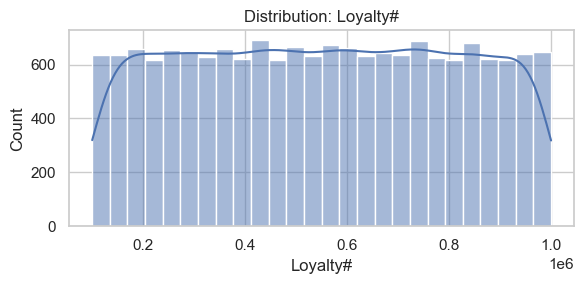

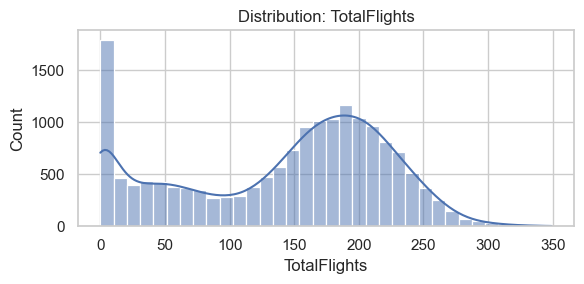

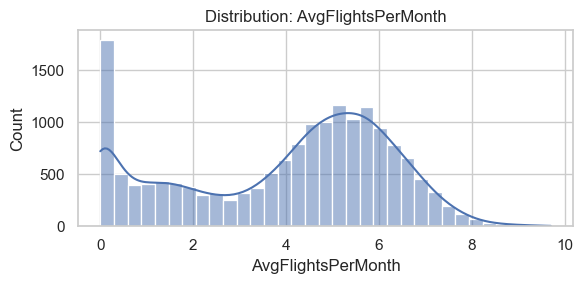

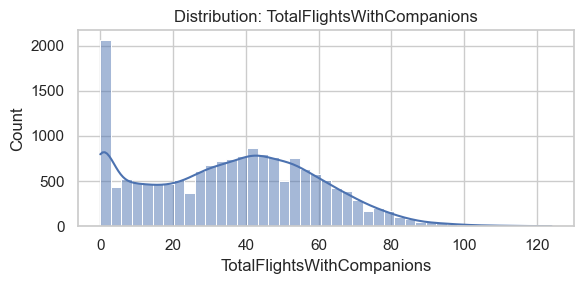

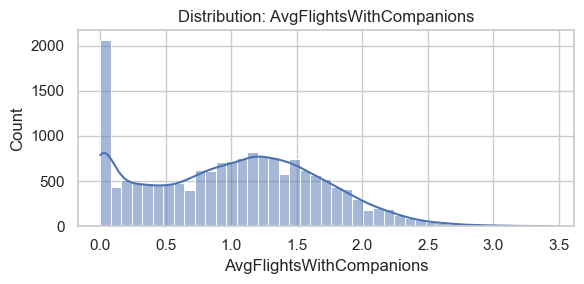

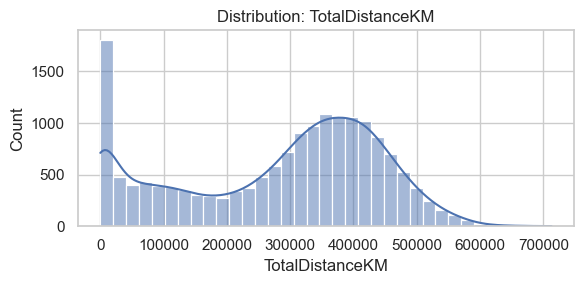

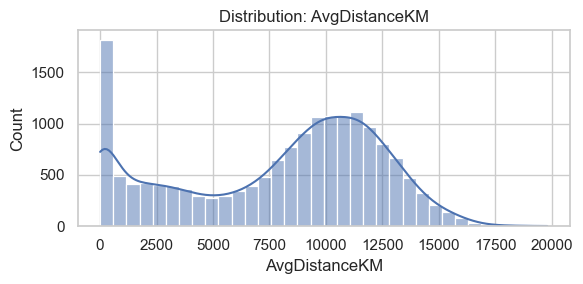

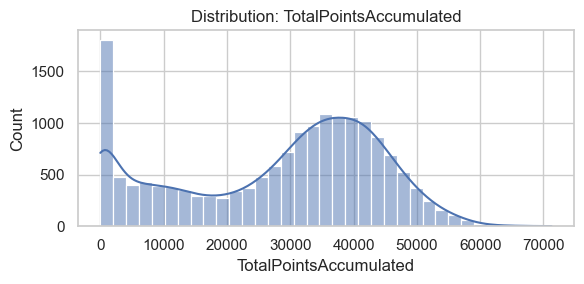

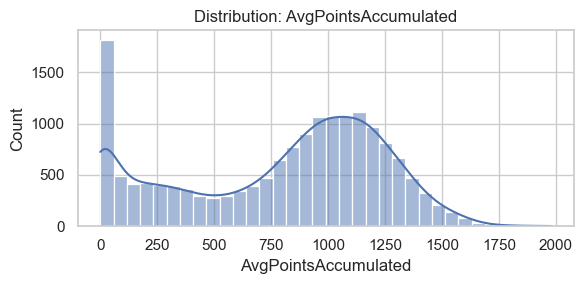

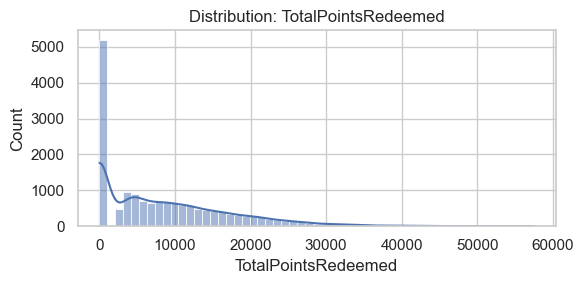

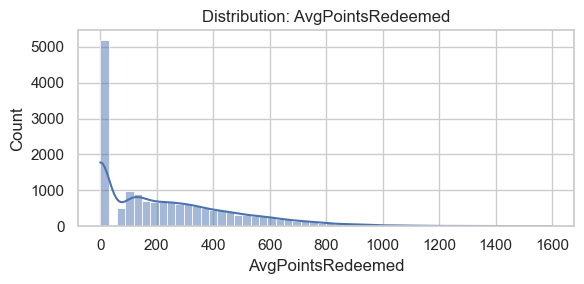

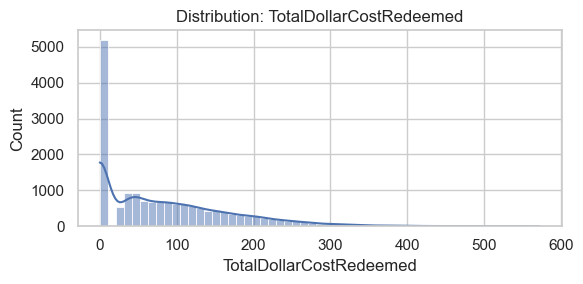

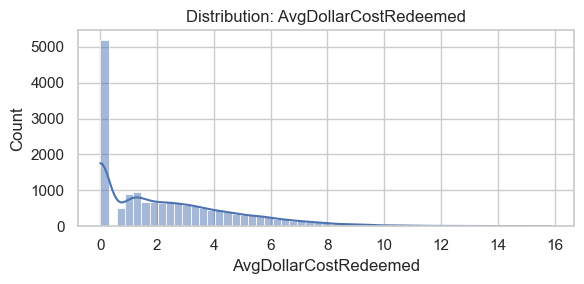

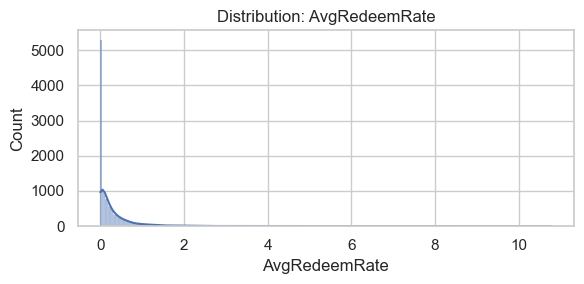

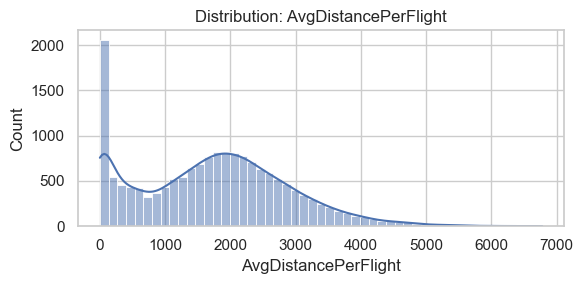

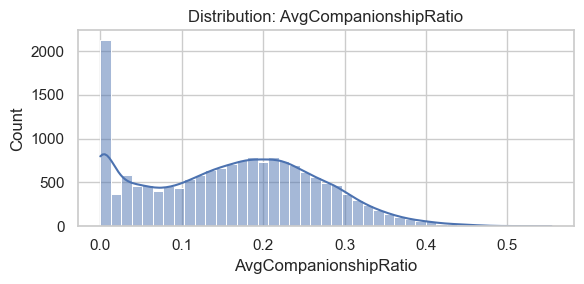

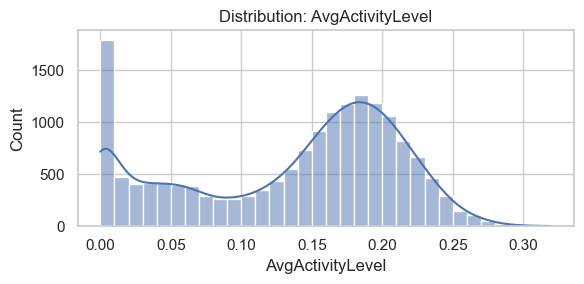

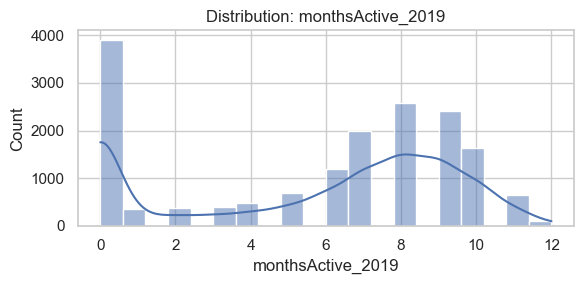

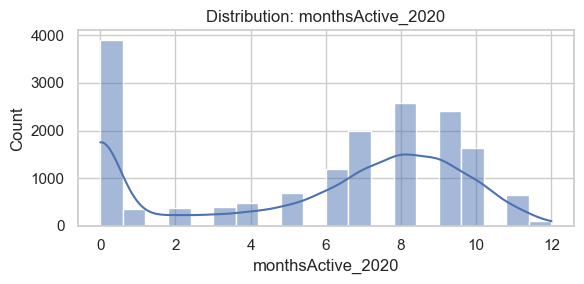

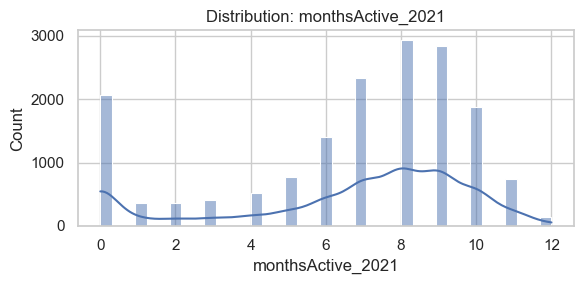

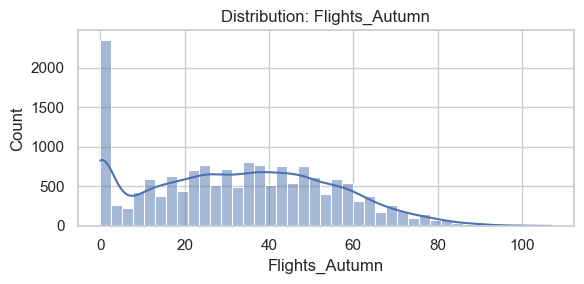

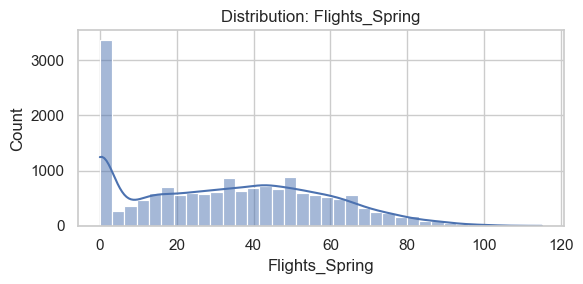

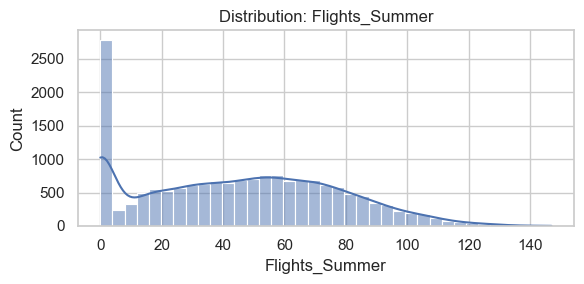

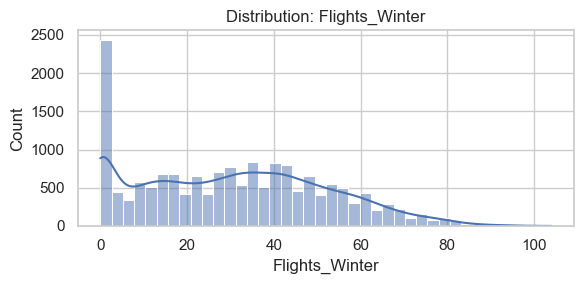

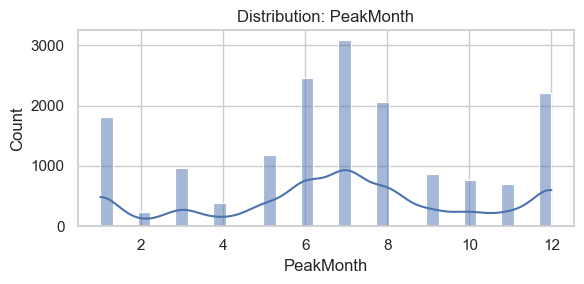

In [270]:
for c in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(flights_agg[c].dropna(), kde=True)
    plt.title(f"Distribution: {c}")
    plt.tight_layout()
    plt.show()

# Box Plots for numerical variables

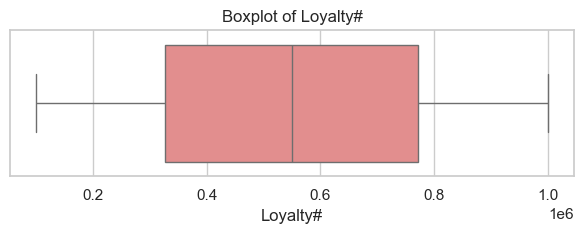

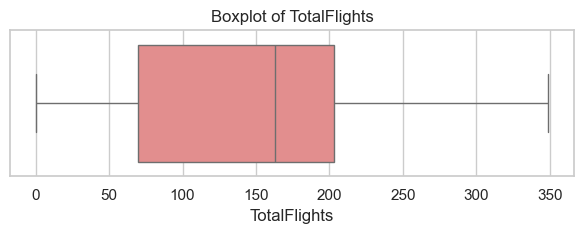

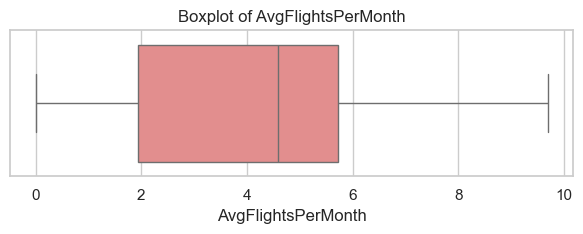

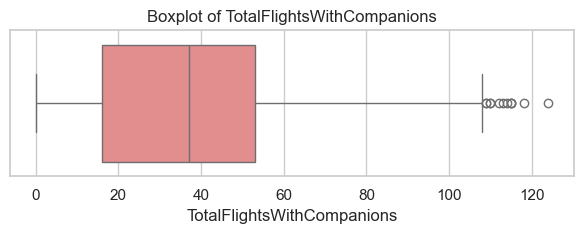

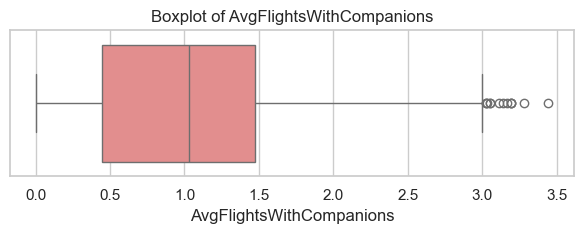

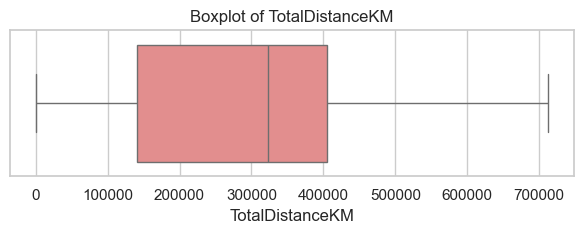

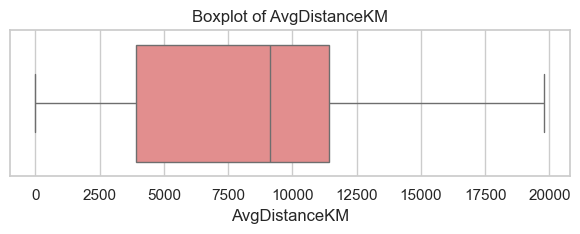

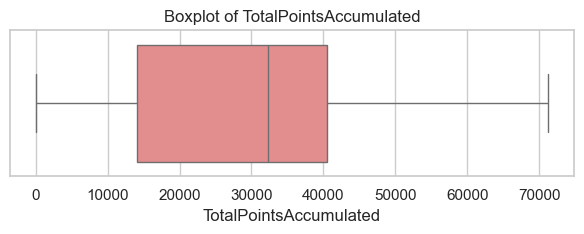

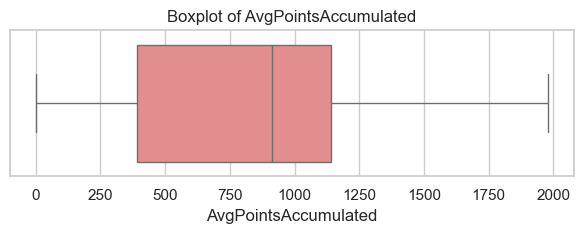

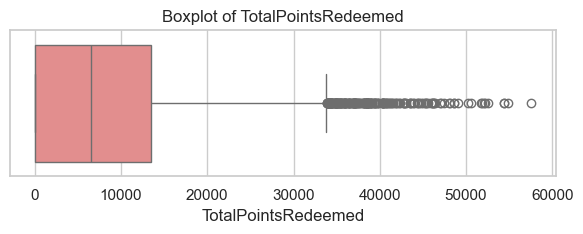

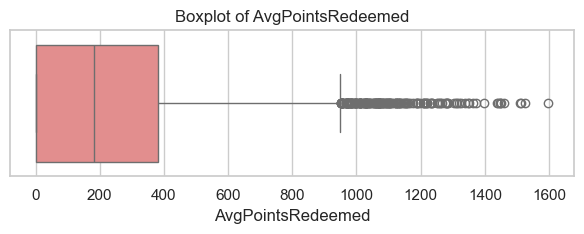

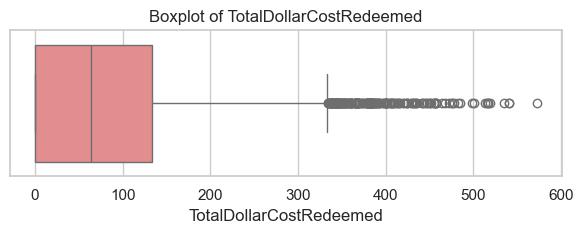

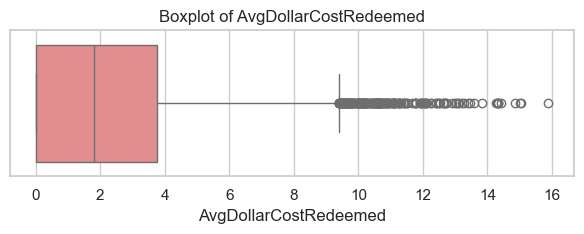

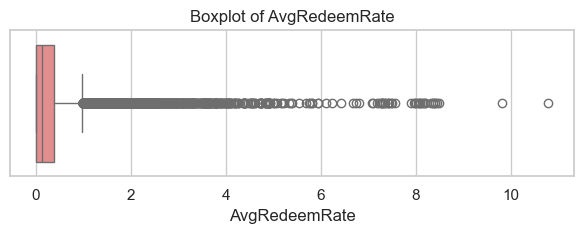

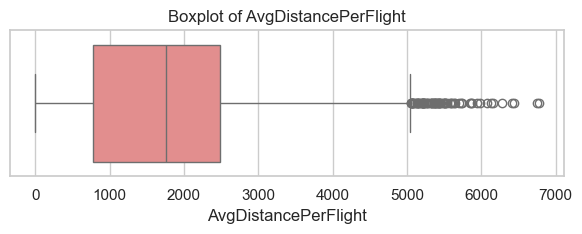

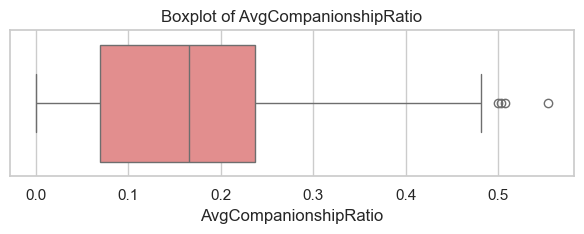

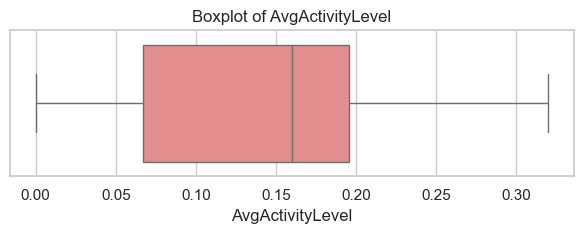

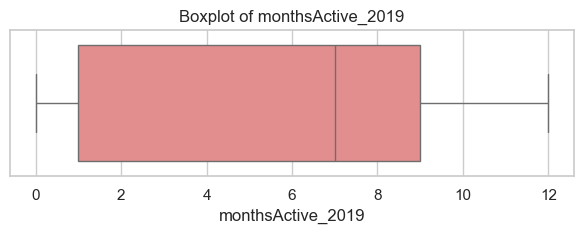

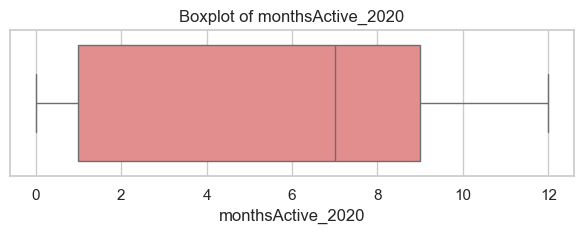

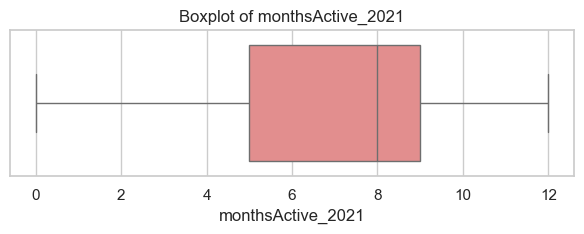

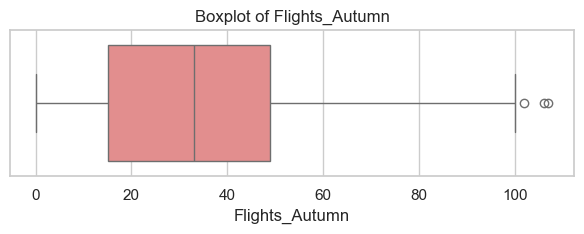

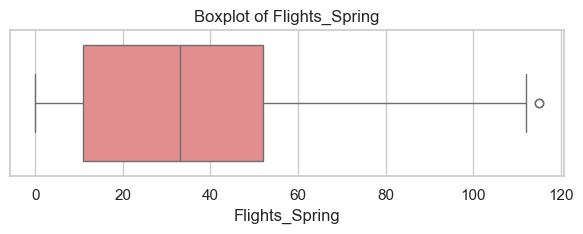

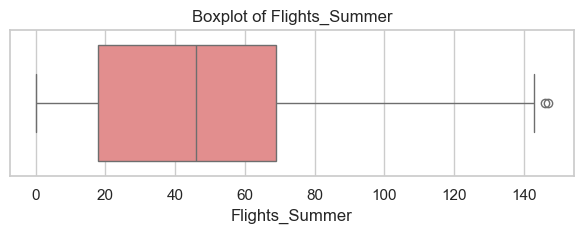

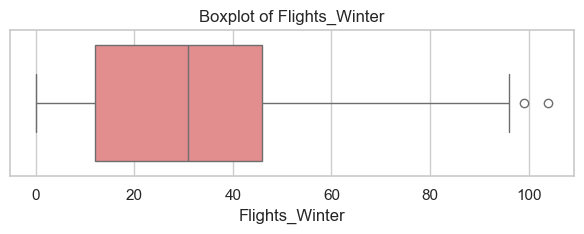

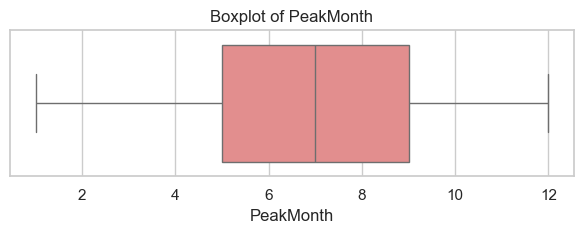

In [271]:
for c in num_cols:
    plt.figure(figsize=(6,2.5))
    sns.boxplot(x=flights_agg[c], color='lightcoral')
    plt.title(f"Boxplot of {c}")
    plt.xlabel(c)
    plt.tight_layout()
    plt.show()

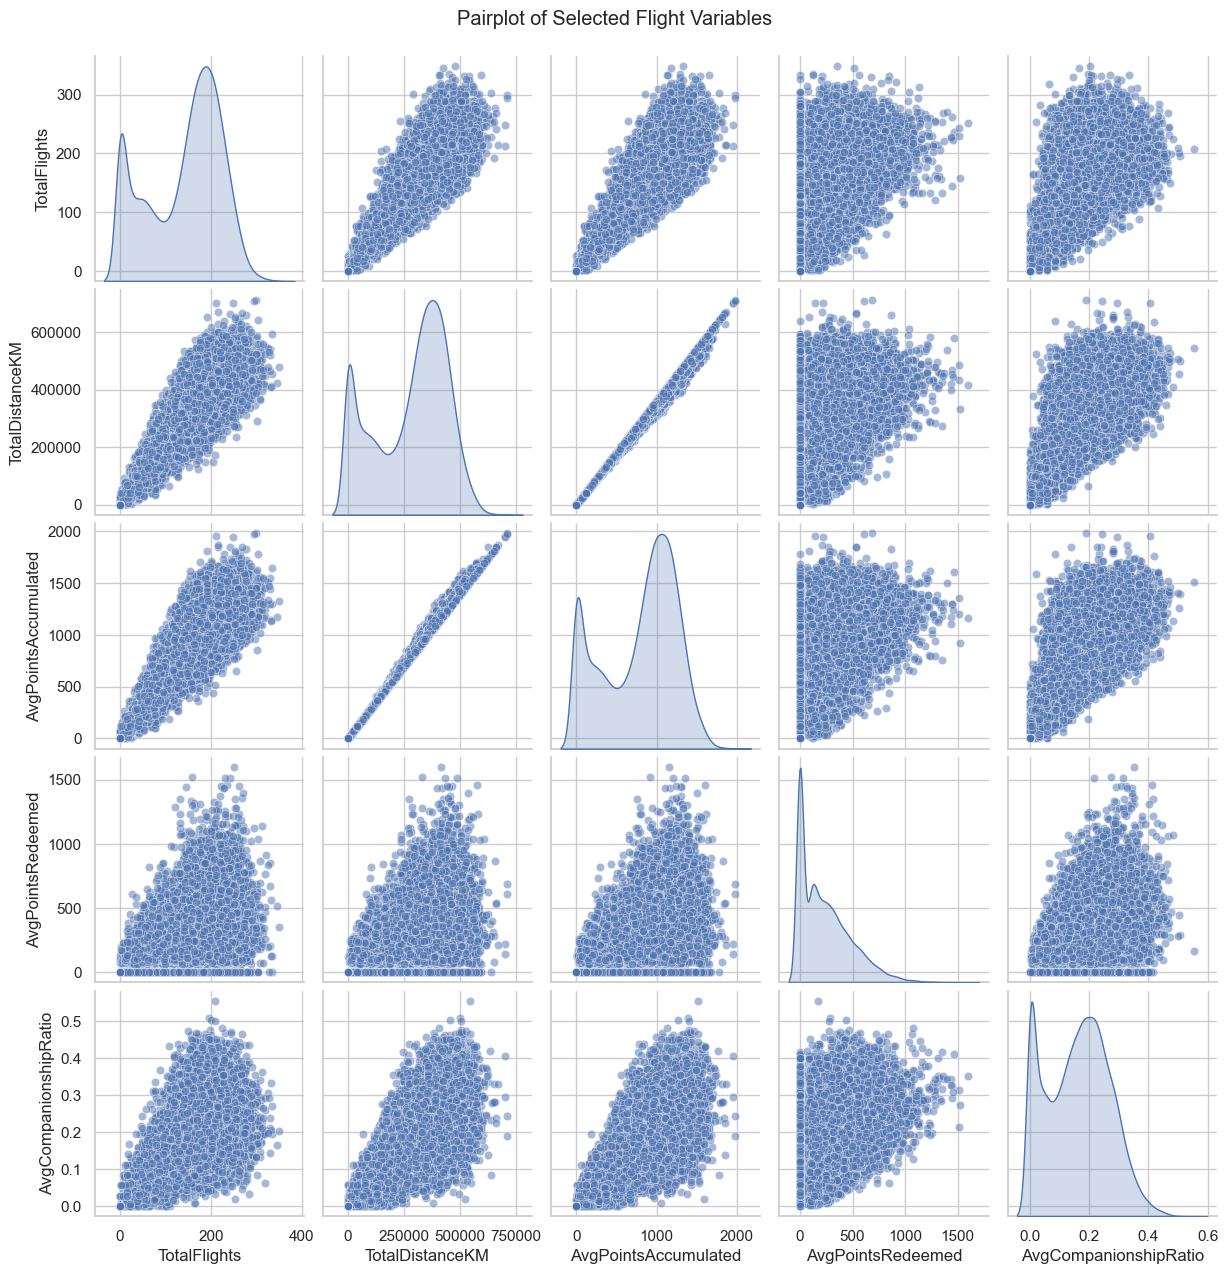

In [272]:
#Here we wanted to compare multiple numerical features at once 
sample_cols = ['TotalFlights', 'TotalDistanceKM', 'AvgPointsAccumulated', 'AvgPointsRedeemed', 'AvgCompanionshipRatio']
sns.pairplot(flights_agg[sample_cols], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Pairplot of Selected Flight Variables", y=1.02)
plt.show()


Distribution of categorical variables

C:\Users\User\AppData\Local\Temp\ipykernel_17372\3973746353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=flights_agg, x=c, order=order, palette='viridis')


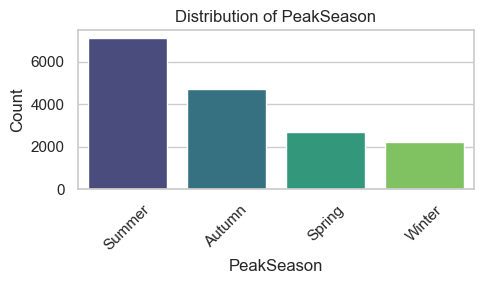

In [273]:
for c in cat_cols:
    plt.figure(figsize=(5,3))
    order = flights_agg[c].value_counts().index
    sns.countplot(data=flights_agg, x=c, order=order, palette='viridis')
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Relation with numeric variables

C:\Users\User\AppData\Local\Temp\ipykernel_17372\4227483962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights_agg, x='PeakSeason', y='AvgDistanceKM', palette='pastel')


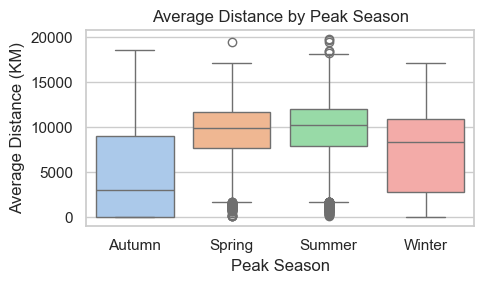

In [274]:
if 'PeakSeason' in flights_agg.columns and 'AvgDistanceKM' in flights_agg.columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(data=flights_agg, x='PeakSeason', y='AvgDistanceKM', palette='pastel')
    plt.title("Average Distance by Peak Season")
    plt.xlabel("Peak Season")
    plt.ylabel("Average Distance (KM)")
    plt.tight_layout()
    plt.show()


we can conclude that Summer and Spring have the highest average distances, indicating seasonal travel peaks.

Distribution for binary variables

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2580106493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette='Set2')


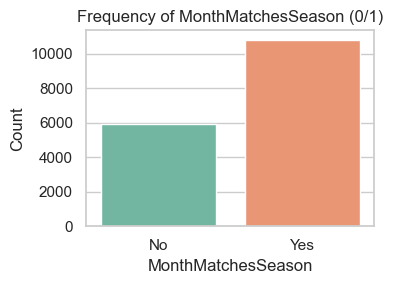

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2580106493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette='Set2')


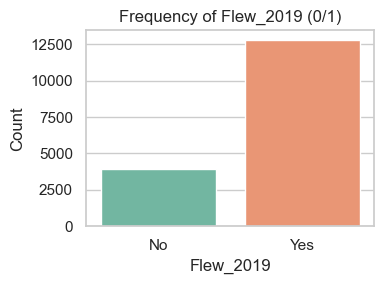

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2580106493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette='Set2')


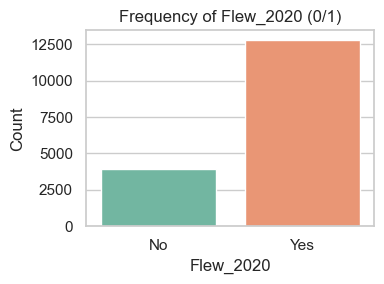

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2580106493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette='Set2')


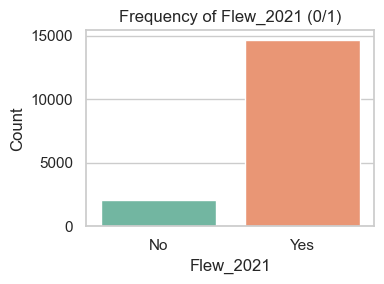

In [275]:
for c in binary_cols:
    plt.figure(figsize=(4,3))
    sns.countplot(x=flights_agg[c], palette='Set2')
    plt.title(f"Frequency of {c} (0/1)")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.xticks([0,1], ['No','Yes'])
    plt.tight_layout()
    plt.show()


Compare binary with a key numeric variable

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2991761129.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=flights_agg[c], y=flights_agg[target_num], palette='coolwarm')


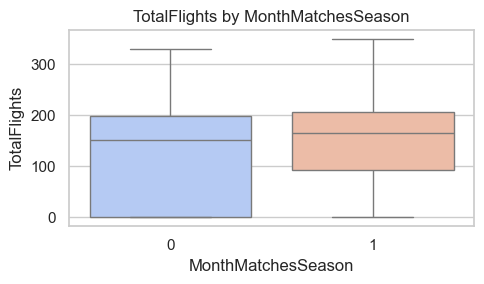

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2991761129.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=flights_agg[c], y=flights_agg[target_num], palette='coolwarm')


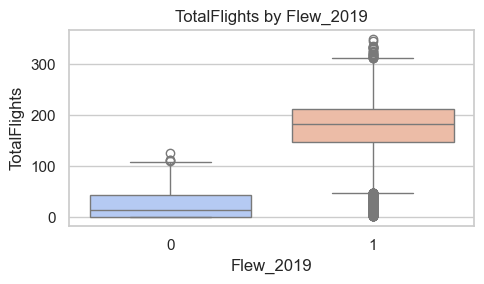

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2991761129.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=flights_agg[c], y=flights_agg[target_num], palette='coolwarm')


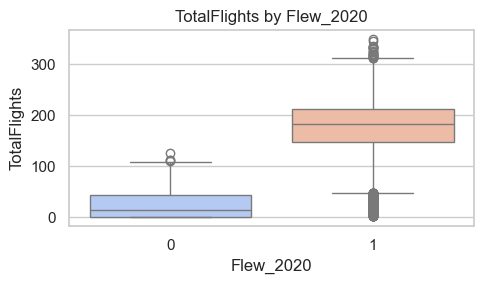

C:\Users\User\AppData\Local\Temp\ipykernel_17372\2991761129.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=flights_agg[c], y=flights_agg[target_num], palette='coolwarm')


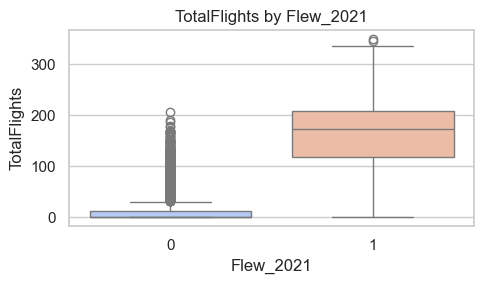

In [276]:
target_num = 'TotalFlights'  # change if needed
for c in binary_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=flights_agg[c], y=flights_agg[target_num], palette='coolwarm')
    plt.title(f"{target_num} by {c}")
    plt.xlabel(c)
    plt.ylabel(target_num)
    plt.tight_layout()
    plt.show()


<a class="anchor" id="3rd-bullet">

### 3.5. Pre-Processing
    
</a>

<a class="anchor" id="3rd-bullet">

### 3.5.1. Filling Missing Values
    
</a>

In [277]:
#there is no missing values




<a class="anchor" id="3rd-bullet">

### 3.5.2. Feature Engineering
    
</a>

In [278]:
# i dont think we need to do this again tho

### 3.5.3 Correlation Matrix (Numerical Variables)

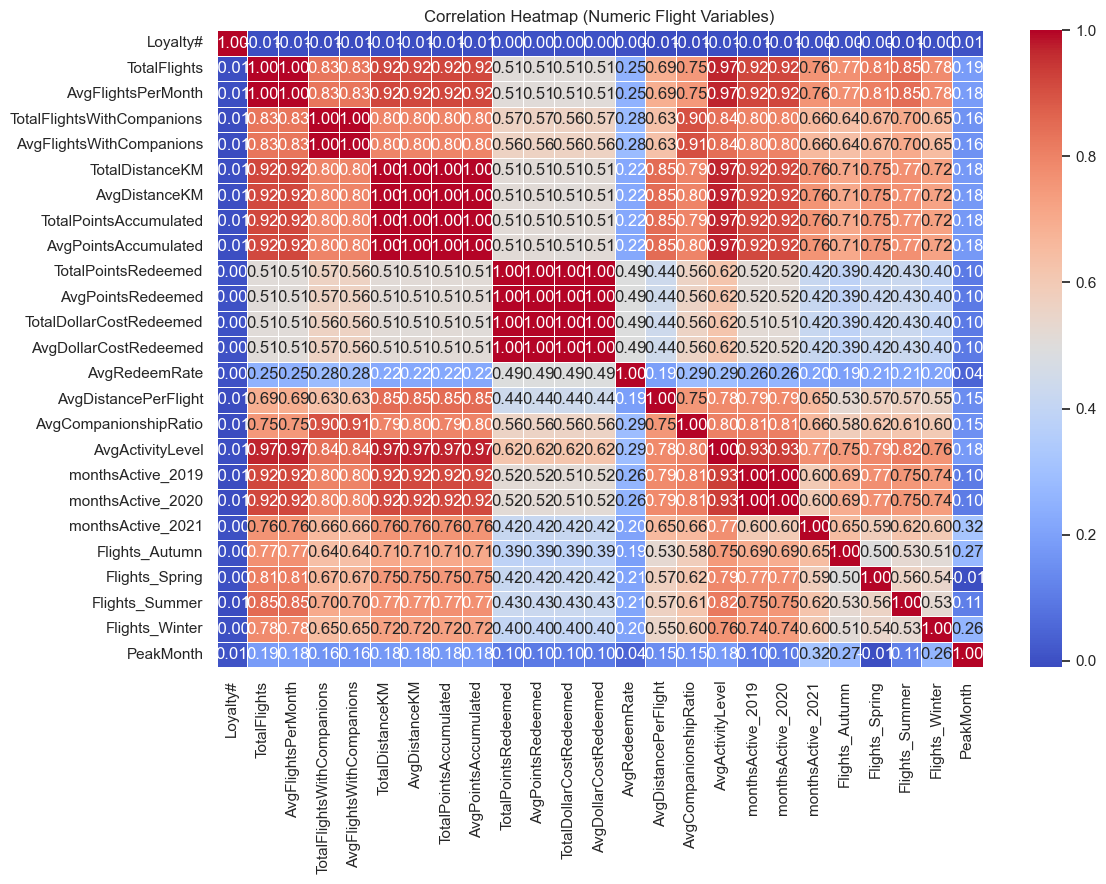

In [279]:
plt.figure(figsize=(12,9))
sns.heatmap(flights_agg[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Flight Variables)")
plt.tight_layout()
plt.show()


We can see that the correlation matrix is very big .Thus the interpretation is difficult . We need first to focus on strong correlations

In [280]:
corr = flights_agg.corr(numeric_only=True)

# Transform matrix into a list of pairs
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Remove duplicates and self-correlations
corr_pairs = corr_pairs[corr_pairs['Variable 1'] < corr_pairs['Variable 2']]

# Keep only strong correlations
strong_corr = corr_pairs[abs(corr_pairs['Correlation']) >= 0.5].sort_values('Correlation', ascending=False)
display(strong_corr.head(20))


,Variable 1,Variable 2,Correlation
807,Flew_2019,Flew_2020,1.000000
528,monthsActive_2019,monthsActive_2020,1.000000
188,AvgDistanceKM,AvgPointsAccumulated,1.000000
157,TotalDistanceKM,TotalPointsAccumulated,1.000000
339,TotalDollarCostRedeemed,TotalPointsRedeemed,0.999978
370,AvgDollarCostRedeemed,AvgPointsRedeemed,0.999978
371,AvgDollarCostRedeemed,TotalDollarCostRedeemed,0.999459
309,AvgPointsRedeemed,TotalPointsRedeemed,0.999457
369,AvgDollarCostRedeemed,TotalPointsRedeemed,0.999445
311,AvgPointsRedeemed,TotalDollarCostRedeemed,0.999427


The analysis shows a strong positive correlation (r = 1) between AvgPointsAccumulated and TotalPointsAccumulated. Another strong correlation (r = 1) was found between AvgDollarCostRedeemed and TotalDollarCostRedeemed.


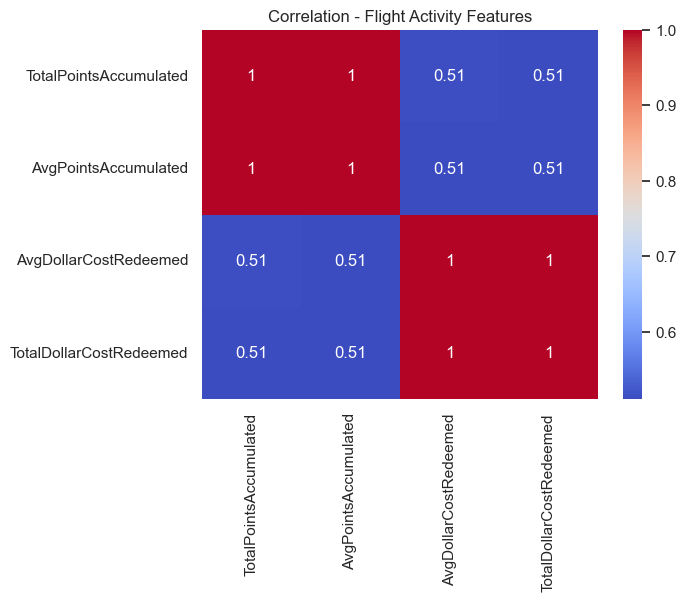

In [281]:
cols_group1 = ['TotalPointsAccumulated', 'AvgPointsAccumulated', 'AvgDollarCostRedeemed', 'TotalDollarCostRedeemed']
sns.heatmap(flights_agg[cols_group1].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation - Flight Activity Features")
plt.show()


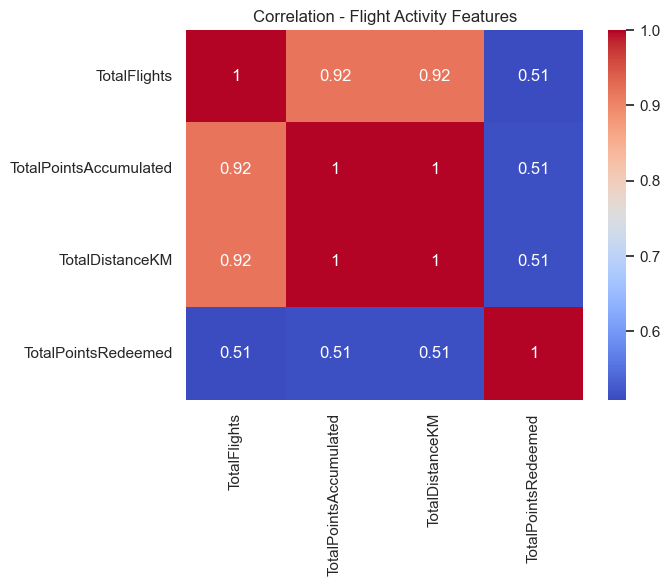

In [282]:
cols_group1 = ['TotalFlights', 'TotalPointsAccumulated', 'TotalDistanceKM', 'TotalPointsRedeemed']
sns.heatmap(flights_agg[cols_group1].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation - Flight Activity Features")
plt.show()


The analysis shows a strong positive correlation (r = 0.92) between TotalFlights and TotalDistanceKM, confirming that frequent travelers tend to cover longer distances. Another strong correlation (r = 0.92) was found between TotalPointsAccumulated and Totalflights.

<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 4. Customers and Flights Datasets Merged
    

    
</div>

<a class="anchor" id="3rd-bullet">

### 4.1. Merging the two datasets
    
</a>

### Check in both datasets

In [283]:
print("Customer dataset shape:", customers.shape)
print("Flight dataset shape:", flights_agg.shape)

Customer dataset shape: (16757, 24)
Flight dataset shape: (16737, 31)


In [284]:
print("Customer key unique:", customers['Loyalty#'].is_unique)
print("Flight key unique:", flights_agg['Loyalty#'].is_unique)

Customer key unique: True
Flight key unique: True


In [287]:
merged_df = pd.merge(customers, flights_agg, on='Loyalty#', how='left')
merged_df


,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Churn,AccountDuration,YearsInProgram,HasHighIncome,MaritalGroup,EnrollmentYear,EducationLevelCode,ProvinceActivity,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,AvgActivityLevel,monthsActive_2019,monthsActive_2020,monthsActive_2021,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter,PeakSeason,PeakMonth,MonthMatchesSeason,Flew_2019,Flew_2020,Flew_2021,YearsActive
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,0,2440,6.684932,1,Married,2019,3,5410,191.0,5.617647,56.0,1.647059,497374.4,14628.658824,49731.84,1462.701176,13517.9,397.585294,134.6,3.958824,0.243641,5164.343983,0.330290,0.222826,9.0,9.0,11.0,40.0,47.0,85.0,19.0,Summer,5.0,0.0,1.0,1.0,1.0,3.0
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,0,2418,6.624658,0,Not Married,2019,2,995,279.0,8.205882,32.0,0.941176,389938.9,11468.791176,38984.19,1146.593824,22457.8,660.523529,221.4,6.511765,1.283911,1077.767039,0.083986,0.250537,8.0,8.0,10.0,59.0,84.0,84.0,52.0,Spring,5.0,1.0,1.0,1.0,1.0,3.0
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,1,1274,3.490411,0,Not Married,2017,2,4379,120.0,3.529412,40.0,1.176471,229822.3,6759.479412,22977.23,675.800882,5479.6,161.164706,53.2,1.564706,0.529404,2084.944251,0.206605,0.116773,8.0,8.0,1.0,30.0,38.0,21.0,31.0,Spring,5.0,1.0,1.0,1.0,1.0,3.0
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,0,3534,9.682192,0,Not Married,2016,2,5410,196.0,5.444444,58.0,1.611111,386029.3,10723.036111,38595.63,1072.100833,16331.5,453.652778,162.2,4.505556,0.878287,2493.037908,0.227100,0.191599,10.0,10.0,7.0,43.0,68.0,37.0,48.0,Spring,6.0,0.0,1.0,1.0,1.0,3.0
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,0,2918,7.994521,1,Married,2017,3,3280,171.0,5.029412,63.0,1.852941,366613.0,10782.735294,36654.00,1078.058824,0.0,0.000000,0.0,0.000000,0.000000,3553.211114,0.321526,0.165311,7.0,7.0,9.0,32.0,28.0,74.0,37.0,Summer,8.0,1.0,1.0,1.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16752,100012,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,34148.0,Single,Star,2019-02-27,2019-02-27,5780.18,Standard,1,0,0.000000,0,Not Married,2019,3,3280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16753,100013,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,34148.0,Married,Star,2017-09-20,2017-09-20,5780.18,Standard,1,0,0.000000,0,Married,2017,3,995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16754,100014,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,34148.0,Married,Star,2020-11-28,2020-11-28,5780.18,Standard,1,0,0.000000,0,Married,2020,3,641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16755,100015,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,34148.0,Married,Star,2020-04-09,2020-04-09,5780.18,Standard,1,0,0.000000,0,Married,

In [288]:
print("Merged dataset shape:", merged_df.shape)

Merged dataset shape: (16757, 54)


In [289]:
print(merged_df.isna().sum().sort_values(ascending=False).head(10))

CancellationDate         14471
monthsActive_2021           20
monthsActive_2020           20
monthsActive_2019           20
PeakSeason                  20
Flights_Winter              20
AvgCompanionshipRatio       20
AvgActivityLevel            20
AvgDistancePerFlight        20
AvgRedeemRate               20
dtype: int64


In [290]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16757 entries, 0 to 16756
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Loyalty#                    16757 non-null  int64         
 1   Province or State           16757 non-null  object        
 2   City                        16757 non-null  object        
 3   Latitude                    16757 non-null  float64       
 4   Longitude                   16757 non-null  float64       
 5   Postal code                 16757 non-null  object        
 6   Gender                      16757 non-null  object        
 7   Education                   16757 non-null  object        
 8   Location Code               16757 non-null  object        
 9   Income                      16757 non-null  float64       
 10  Marital Status              16757 non-null  object        
 11  LoyaltyStatus               16757 non-null  object    

In [291]:
merged_df.head()

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Churn,AccountDuration,YearsInProgram,HasHighIncome,MaritalGroup,EnrollmentYear,EducationLevelCode,ProvinceActivity,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,AvgActivityLevel,monthsActive_2019,monthsActive_2020,monthsActive_2021,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter,PeakSeason,PeakMonth,MonthMatchesSeason,Flew_2019,Flew_2020,Flew_2021,YearsActive
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,0,2440,6.684932,1,Married,2019,3,5410,191.0,5.617647,56.0,1.647059,497374.4,14628.658824,49731.84,1462.701176,13517.9,397.585294,134.6,3.958824,0.243641,5164.343983,0.330290,0.222826,9.0,9.0,11.0,40.0,47.0,85.0,19.0,Summer,5.0,0.0,1.0,1.0,1.0,3.0
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,0,2418,6.624658,0,Not Married,2019,2,995,279.0,8.205882,32.0,0.941176,389938.9,11468.791176,38984.19,1146.593824,22457.8,660.523529,221.4,6.511765,1.283911,1077.767039,0.083986,0.250537,8.0,8.0,10.0,59.0,84.0,84.0,52.0,Spring,5.0,1.0,1.0,1.0,1.0,3.0
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,1,1274,3.490411,0,Not Married,2017,2,4379,120.0,3.529412,40.0,1.176471,229822.3,6759.479412,22977.23,675.800882,5479.6,161.164706,53.2,1.564706,0.529404,2084.944251,0.206605,0.116773,8.0,8.0,1.0,30.0,38.0,21.0,31.0,Spring,5.0,1.0,1.0,1.0,1.0,3.0
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,0,3534,9.682192,0,Not Married,2016,2,5410,196.0,5.444444,58.0,1.611111,386029.3,10723.036111,38595.63,1072.100833,16331.5,453.652778,162.2,4.505556,0.878287,2493.037908,0.227100,0.191599,10.0,10.0,7.0,43.0,68.0,37.0,48.0,Spring,6.0,0.0,1.0,1.0,1.0,3.0
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,0,2918,7.994521,1,Married,2017,3,3280,171.0,5.029412,63.0,1.852941,366613.0,10782.735294,36654.00,1078.058824,0.0,0.000000,0.0,0.000000,0.000000,3553.211114,0.321526,0.165311,7.0,7.0,9.0,32.0,28.0,74.0,37.0,Summer,8.0,1.0,1.0,1.0,1.0,3.0


### Feature Engineering

### Feature: Churn Indicator

The variable `CancellationDate` was transformed into a binary indicator `Churn`, where:
- `1` indicates that the customer canceled their loyalty membership (churned).
- `0` indicates that the customer is still active.

This new feature provides valuable insight into customer retention behavior and can later be used for segmentation or predictive modeling of churn risk.


In [297]:
merged_df['Churn'] = merged_df['CancellationDate'].notnull().astype(int)


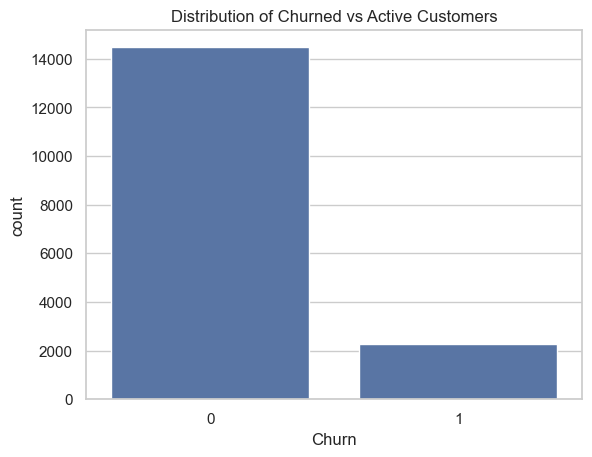

In [298]:
sns.countplot(x='Churn', data=merged_df)
plt.title('Distribution of Churned vs Active Customers')
plt.show()

### Feature: CLV_per_Flight

This variable measures how much value each flight brings to the airline for a customer.
It helps identify high-value frequent flyers vs. low-value occasional ones.


In [294]:
merged_df['CLV_per_Flight'] = merged_df['Customer Lifetime Value'] / (merged_df['TotalFlights'] + 1)


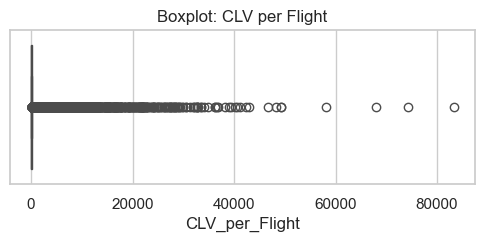

In [296]:
plt.figure(figsize=(6,2))
sns.boxplot(x=merged_df['CLV_per_Flight'])
plt.title('Boxplot: CLV per Flight')
plt.show()



### Feature: Income_to_Spending_Ratio

This feature compares a customer’s income to their spending (DollarCostRedeemed), revealing financial behavior patterns:

   -Higher ratios → spend little relative to income (possibly price-sensitive).

   -Lower ratios → spend a lot relative to income (possibly loyal / high engagement).

In [299]:
merged_df['Income_to_Spending_Ratio'] = merged_df['Income'] / (merged_df['TotalDollarCostRedeemed'] + 1)


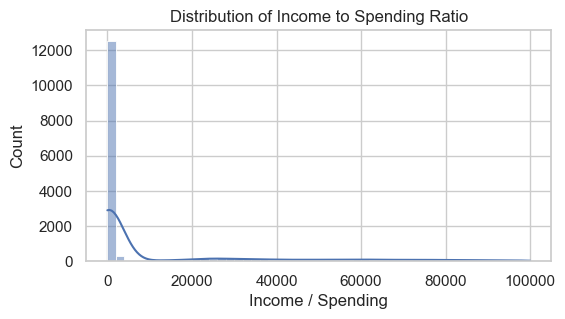

In [300]:
plt.figure(figsize=(6,3))
sns.histplot(merged_df['Income_to_Spending_Ratio'], bins=50, kde=True)
plt.title('Distribution of Income to Spending Ratio')
plt.xlabel('Income / Spending')
plt.ylabel('Count')
plt.show()


Three engineered features were developed to better describe customer value and behavior.
CLV_per_Flight measures how much value each flight brings to the airline, highlighting high-value frequent flyers.
Income_to_Spending_Ratio captures the balance between customer income and redeemed spending, helping differentiate cost-sensitive vs. high-engagement customers.
Finally, Churn, derived from the cancellation date, identifies customers who have left the program, supporting retention analysis.

### Visualisation 

General Overview

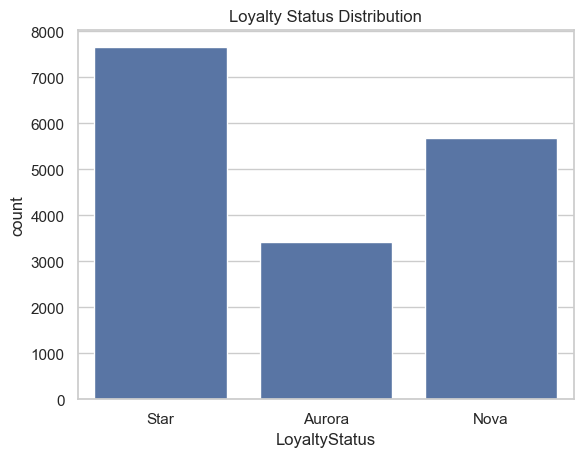

In [302]:
sns.countplot(x='LoyaltyStatus', data=merged_df)
plt.title('Loyalty Status Distribution')
plt.show()

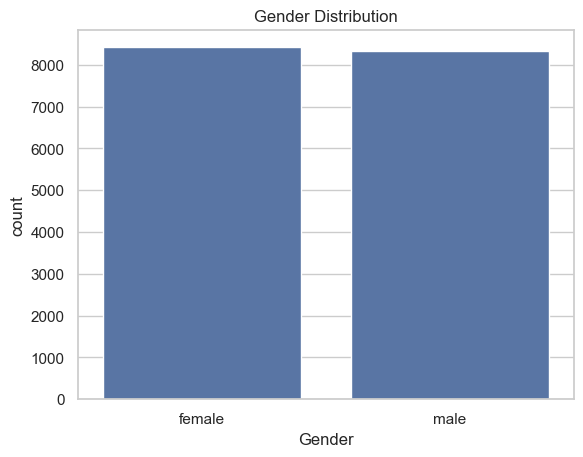

In [305]:
sns.countplot(x='Gender', data=merged_df)
plt.title('Gender Distribution')
plt.show()

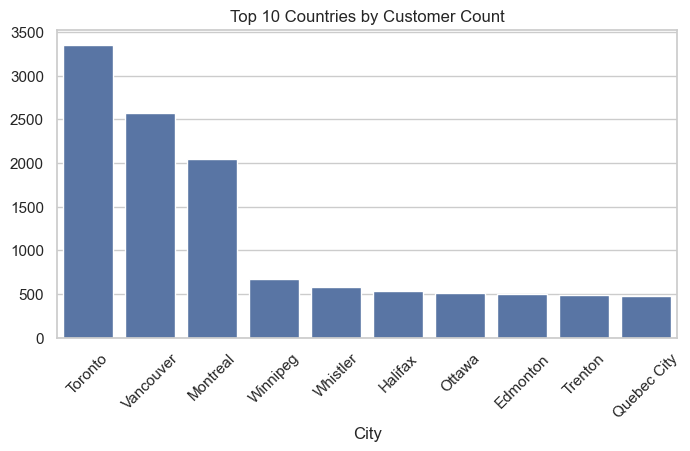

In [304]:
#Top cities
top_countries = merged_df['City'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title('Top 10 Countries by Customer Count')
plt.xticks(rotation=45)
plt.show()

--> Most loyalty members come from Toronto. The gender distribution is balanced, suggesting no bias in participation across demographics.

Correlation Matrix 

1- Financial Related Variables

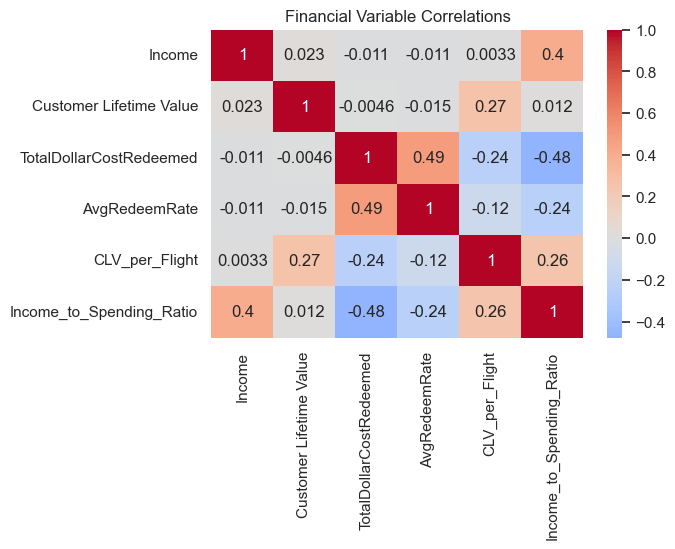

In [306]:
financial_vars = ['Income', 'Customer Lifetime Value', 'TotalDollarCostRedeemed',
                  'AvgRedeemRate', 'CLV_per_Flight', 'Income_to_Spending_Ratio']

plt.figure(figsize=(6,4))
sns.heatmap(merged_df[financial_vars].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Financial Variable Correlations')
plt.show()


2-Activity Related Variables

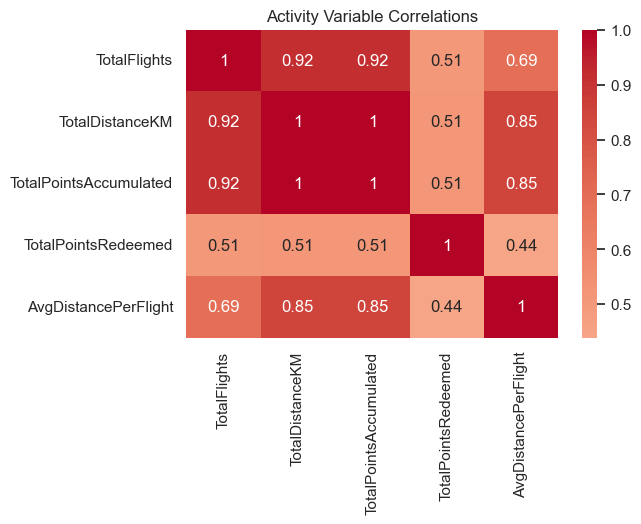

In [307]:
activity_vars = ['TotalFlights', 'TotalDistanceKM', 'TotalPointsAccumulated', 
                 'TotalPointsRedeemed', 'AvgDistancePerFlight']

plt.figure(figsize=(6,4))
sns.heatmap(merged_df[activity_vars].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Activity Variable Correlations')
plt.show()


Feature Relationships

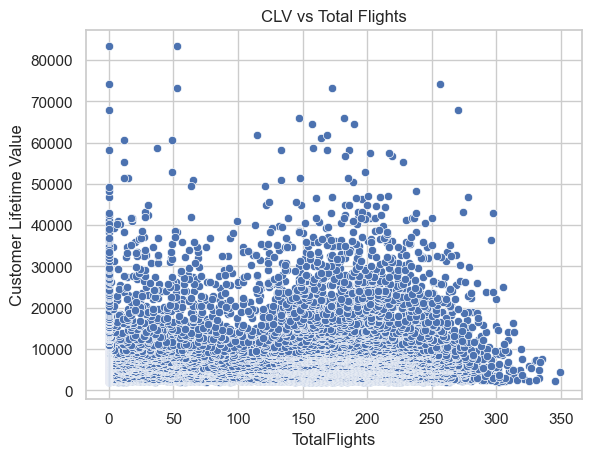

In [308]:
#CLV vs Total Flights
sns.scatterplot(x='TotalFlights', y='Customer Lifetime Value', data=merged_df)
plt.title('CLV vs Total Flights')
plt.show()

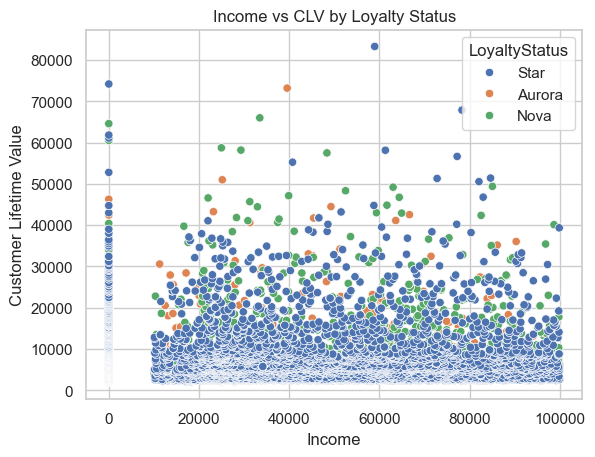

In [309]:
#Income vs CLV
sns.scatterplot(x='Income', y='Customer Lifetime Value', data=merged_df, hue='LoyaltyStatus')
plt.title('Income vs CLV by Loyalty Status')
plt.show()

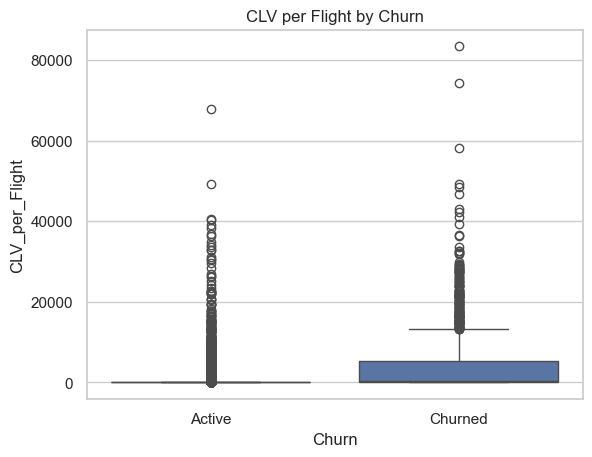

In [310]:
#CLV per Flight by Churn
sns.boxplot(x='Churn', y='CLV_per_Flight', data=merged_df)
plt.title('CLV per Flight by Churn')
plt.xticks([0,1], ['Active', 'Churned'])
plt.show()


Customers with high CLV per flight show lower churn probability, highlighting the profitability of loyal frequent flyers

In [312]:
# at the end of the project we should be probably just write a conclusion to all of this and say like what clusters
# do we think will exist later, etc